# Dissertation results: retained cleaned workflow

This notebook retains Martingale, joint LSTM, per-ticker LSTM, joint HuPin LSTM, and joint Quantile Regression. ARIMAX and abandoned baselines are outside this cleaned comparison. Run `EDA.ipynb` first.

**Reproduction note.** The joint Quantile path is retained by explicit project decision. Its results differ from the per-ticker Quantile values printed in Dissertation Table 2; the submitted monolithic notebook remains the audit source for that historical table.


**Disclaimer**: A considerable portion of the coding was supported by coding assistants. However, all modeling decisions — including architecture, metric design, and evaluation criteria — were researcher-led. The role of such tools was to accelerate implementation, not to substitute conceptual responsibility.

In [1]:
import json
import os
import warnings
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from darts import TimeSeries

from src.features import add_ticker_one_hot as build_ohe
from src.metrics import (
    bmr as submitted_bmr,
    bmr_tolerant as submitted_bmr_tolerant,
    bmr_z as submitted_bmr_z,
    pooled_bmr_z as submitted_pooled_bmr_z,
    r_squared as submitted_r_squared,
    rmse as submitted_rmse,
    robust_bmr_z_threshold as submitted_robust_bmr_z_threshold,
)
from src.splits import (
    embargo_split_idx,
    fit_pooled_prefix_standard_scaler,
    fit_prefix_standard_scaler,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
sns.set_context("notebook")

OUTPUT_ROOT = Path("outputs")
DATA_OUTPUT_DIR = OUTPUT_ROOT / "data"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

theoretical_path = DATA_OUTPUT_DIR / "theoretical.csv"
if not theoretical_path.exists():
    raise FileNotFoundError(
        "Missing outputs/data/theoretical.csv. Run EDA.ipynb first to generate the submitted "
        "Martingale evaluation input."
    )
df_theoretical = pd.read_csv(theoretical_path, parse_dates=["Date"])


## 1. Martingale benchmark


In [2]:
# =========================
# Martingale (Zero-Predictor) — metrics + predictions
# =========================
import os, json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import root_mean_squared_error, r2_score

# ---- Output folder ----
OUT_DIR = os.path.join("outputs", "martingale")
DIAG_DIR = os.path.join(OUT_DIR, "diagnostics")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(DIAG_DIR, exist_ok=True)

# ---- Tail metric knobs (consistent with other models) ----
K_ERR = 1.0                 # tolerance factor × per-ticker RMSE
MAD_MULTIPLIER = 2.0
Z_PSTAR = 0.0228            # ≈ Phi(-2)
MIN_TRAIN_TAIL_EVENTS = 5   # fallback to quantile if too few tail events
TAU_MIN = -1e-12            # enforce strictly negative z-cutoff

def _z_threshold_from_series(y: np.ndarray) -> float:
    tau = submitted_robust_bmr_z_threshold(
        y,
        mad_multiplier=MAD_MULTIPLIER,
        fallback_quantile=Z_PSTAR,
        min_tail_events=MIN_TRAIN_TAIL_EVENTS,
    )
    return float(min(tau, TAU_MIN)) if np.isfinite(tau) else np.nan

_z_bmr = submitted_bmr_z

def evaluate_naive_model_zero(df, model_name="Martingale_zero", metrics_file=os.path.join("outputs", "model_metrics.csv")):
    """
    Naïve baseline: predict next-day return = 0 for every t.
    Returns df_eval used by residual diagnostics (unchanged schema).
    Also writes normalized predictions for DM comparisons.
    """
    # Prepare lagged returns
    df = df.copy()
    df.sort_values(by=['Source', 'Date'], inplace=True)
    df['LogReturn_t']   = df['log_return']
    df['LogReturn_t+1'] = df.groupby('Source')['log_return'].shift(-1)

    # Drop NaNs from lagging
    df_eval = df.dropna(subset=['LogReturn_t', 'LogReturn_t+1']).copy()
    df_eval['Predicted'] = 0.0                              # <- zero predictor
    df_eval['Actual']    = df_eval['LogReturn_t+1']

    # ---- Build per-ticker z-thresholds from available (non-leaky proxy) LogReturn_t series ----
    z_tau_map = {}
    for ticker, sub in df_eval.groupby('Source'):
        z_tau_map[ticker] = _z_threshold_from_series(sub['LogReturn_t'].to_numpy())

    # ---- Overall metrics (printed) ----
    a_all  = df_eval['Actual'].to_numpy()
    p_all  = df_eval['Predicted'].to_numpy()
    rmse_all = submitted_rmse(a_all, p_all)
    r2_all   = submitted_r_squared(a_all, p_all)

    # BMR (standard): miss if y<0 AND (pred > actual)
    bear_all = (a_all < 0)
    denom_all = int(bear_all.sum())
    bmr_all   = submitted_bmr(a_all, p_all)

    # BMR_tol: miss if y<0 AND (pred - actual) >= eps_err (eps_err = K_ERR * RMSE scope)
    eps_err_all = K_ERR * rmse_all
    bmr_tol_all = submitted_bmr_tolerant(a_all, p_all, eps_err_all)

    # pooled z-BMR from per-ticker counts
    z_miss_total = 0
    z_bear_total = 0

    # ---- Per-ticker rows ----
    rows = [{
        'Model': model_name, 'Ticker': 'All',
        'RMSE': round(rmse_all, 8),
        'R²': round(r2_all, 5),
        'BearMissRate': round(bmr_all, 5),
        'BearMissRate_tol': round(bmr_tol_all, 5),
        'BearMissRate_z': np.nan  # filled after loop
    }]

    for ticker, sub in df_eval.groupby('Source'):
        a = sub['Actual'].to_numpy()
        p = sub['Predicted'].to_numpy()
        rmse = submitted_rmse(a, p)
        r2   = submitted_r_squared(a, p)

        bear = (a < 0)
        denom = int(bear.sum())

        # corrected BMR: miss if pred > actual on the bear set
        bmr   = submitted_bmr(a, p)

        # BMR_tol with per-ticker eps_err
        eps_err = K_ERR * rmse
        bmr_t = submitted_bmr_tolerant(a, p, eps_err)

        tau = z_tau_map.get(ticker, np.nan)
        bmr_z, z_miss, z_bears = _z_bmr(a, p, tau) if np.isfinite(tau) else (float('nan'), 0, 0)
        z_miss_total += z_miss
        z_bear_total += z_bears

        rows.append({
            'Model': model_name, 'Ticker': ticker,
            'RMSE': round(rmse, 8), 'R²': round(r2, 5),
            'BearMissRate': round(bmr, 5),
            'BearMissRate_tol': round(bmr_t, 5),
            'BearMissRate_z': round(bmr_z, 5) if pd.notna(bmr_z) else np.nan,
            'z-miss': int(z_miss), 'z-bears': int(z_bears),
            'z-threshold': float(tau) if np.isfinite(tau) else np.nan,
            'N': int(len(sub))
        })

    # fill pooled z-BMR
    bmr_z_all, _, _ = submitted_pooled_bmr_z([(z_miss_total, z_bear_total)])
    rows[0]['BearMissRate_z'] = round(bmr_z_all, 5) if pd.notna(bmr_z_all) else np.nan

    # ---- Save/append metrics (per-model file + global log) ----
    out = pd.DataFrame(rows)
    mtg_metrics_file = os.path.join(OUT_DIR, "martingale_metrics.csv")
    out.to_csv(mtg_metrics_file, index=False)

    # Append the compact schema to the cross-model log
    cols_for_log = ['Model','Ticker','RMSE','R²','BearMissRate','BearMissRate_tol','BearMissRate_z']
    out_log = out[cols_for_log]
    if os.path.exists(metrics_file):
        prev = pd.read_csv(metrics_file)
        out_log = pd.concat([prev, out_log], ignore_index=True)
    out_log.to_csv(metrics_file, index=False)

    # ---- Save normalized predictions for DM comparisons ----
    preds_out = (df_eval[['Date','Source','Actual','Predicted']]
                 .rename(columns={'Source':'Ticker'}))
    preds_out['Model'] = model_name
    preds_path = os.path.join(OUT_DIR, "Martingale_predictions.parquet")
    preds_out.to_parquet(preds_path, index=False)

    # ---- Save df_eval to parquet for diagnostics convenience ----
    df_eval_path = os.path.join(OUT_DIR, "df_eval.parquet")
    df_eval.to_parquet(df_eval_path, index=False)

    # Minimal overall print
    print(f"\nOverall ({model_name})  RMSE={rmse_all:.8f}  R²={r2_all:.5f}  "
          f"BearMissRate={bmr_all:.5f}  BearMissRate_tol={bmr_tol_all:.5f}  "
          f"BearMissRate_z={(bmr_z_all if pd.notna(bmr_z_all) else float('nan')):.5f}")
    print(f"✅ Metrics -> {mtg_metrics_file} | Global log -> {metrics_file} | Predictions -> {preds_path} | df_eval -> {df_eval_path}")

    return df_eval



Overall (Martingale)  RMSE=0.02555872  R²=-0.00003  BearMissRate=1.00000  BearMissRate_tol=0.19048  BearMissRate_z=1.00000
✅ Metrics -> outputs\martingale\martingale_metrics.csv | Global log -> outputs\model_metrics.csv | Predictions -> outputs\martingale\Martingale_predictions.parquet | df_eval -> outputs\martingale\df_eval.parquet


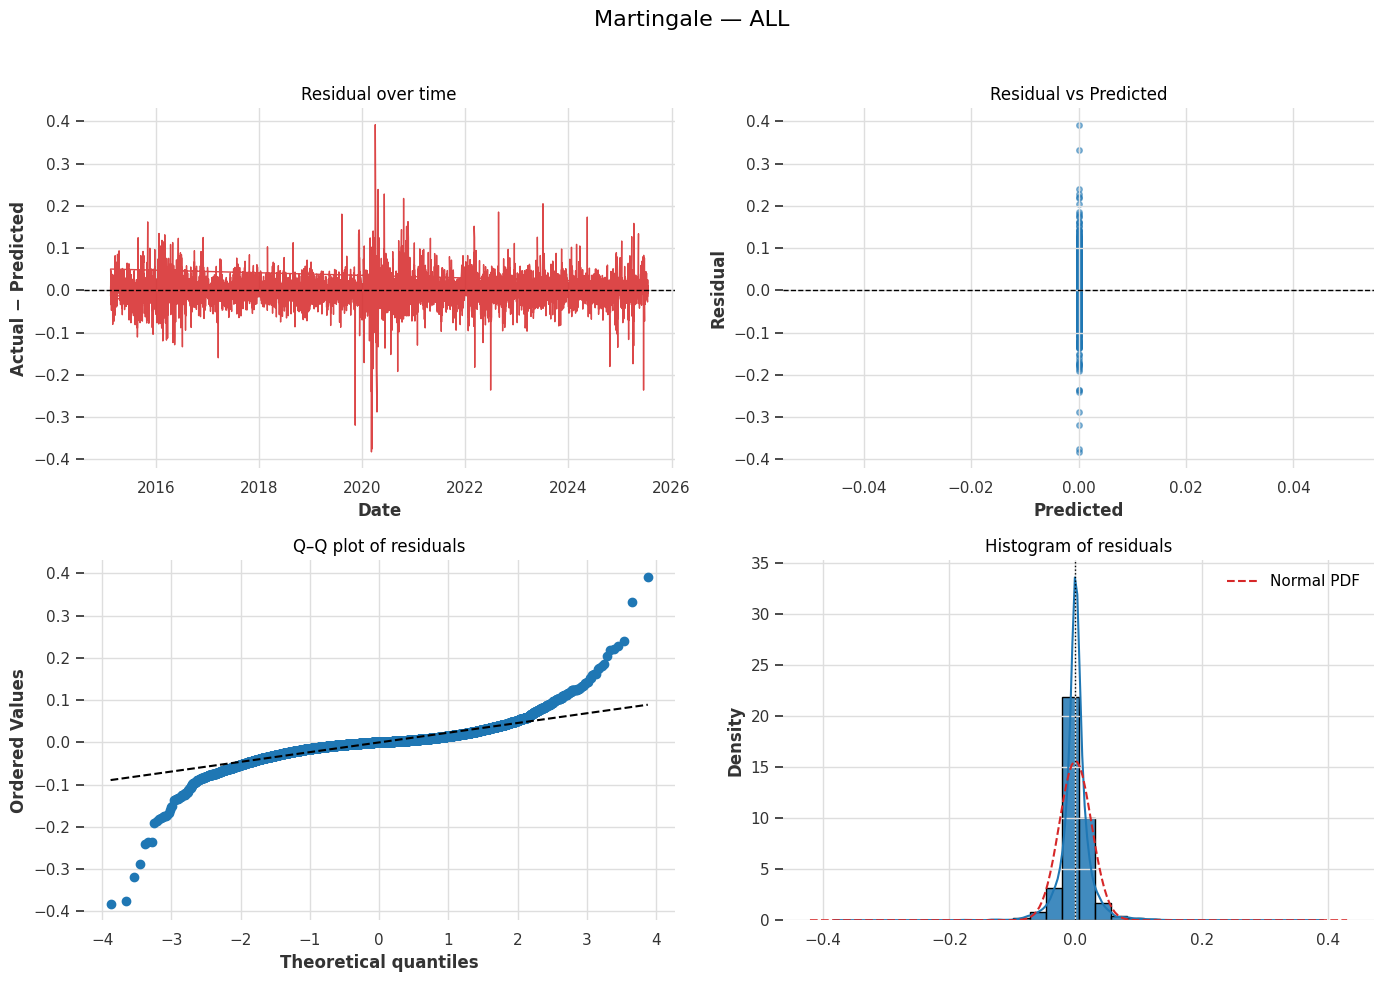

📊 Residual stats — Martingale — ALL: Mean -0.000144 | Std 0.025558 | Skew -0.173 | Kurt(excess) 26.792


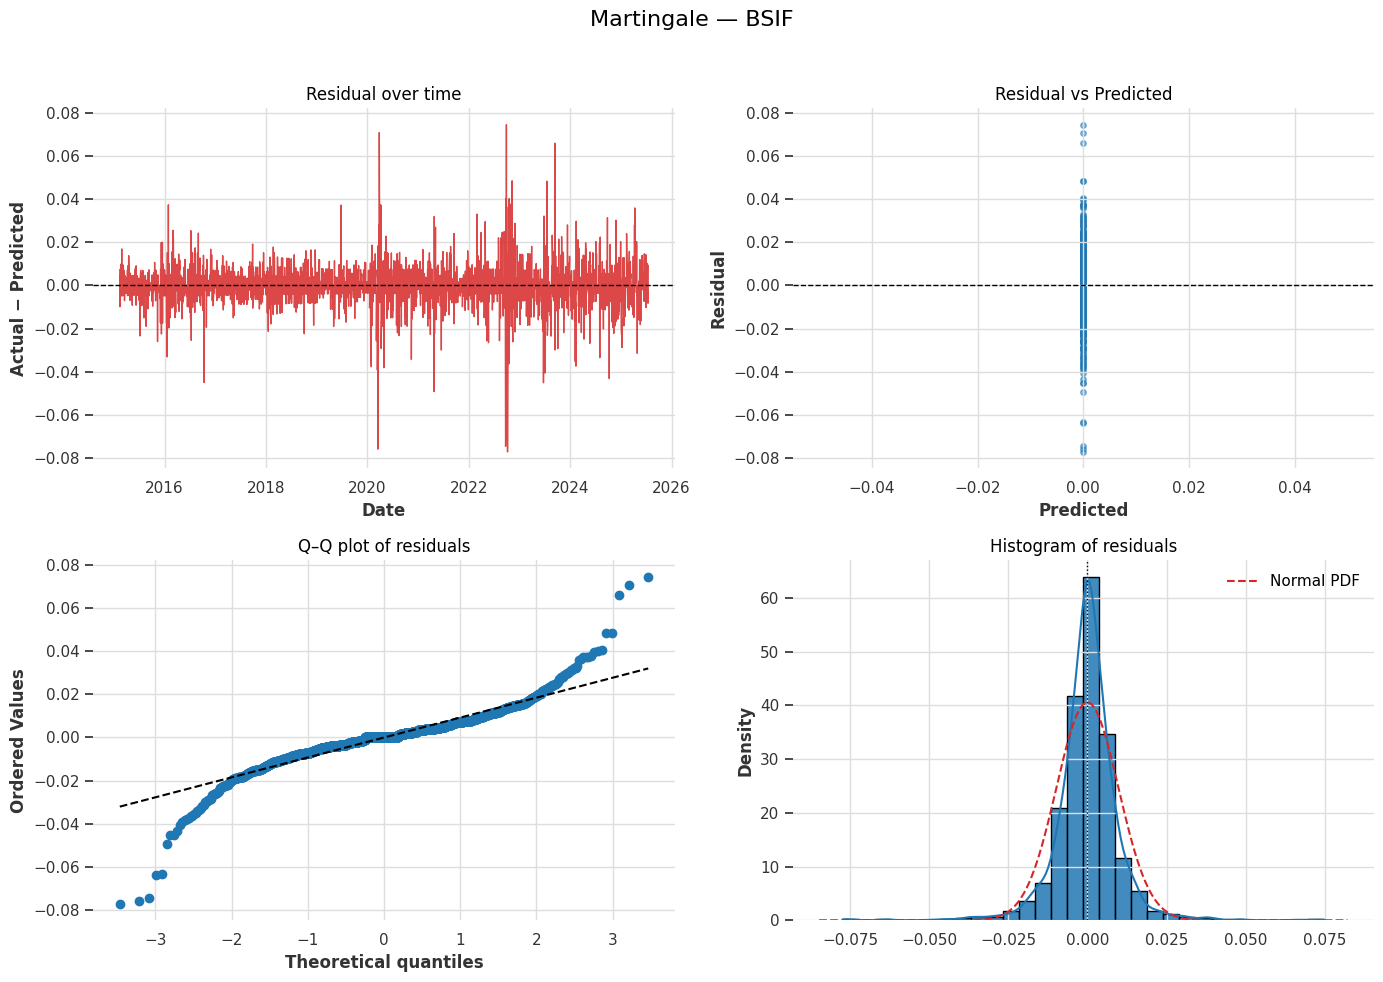

📊 Residual stats — Martingale — BSIF: Mean -0.000013 | Std 0.009834 | Skew -0.392 | Kurt(excess) 10.564


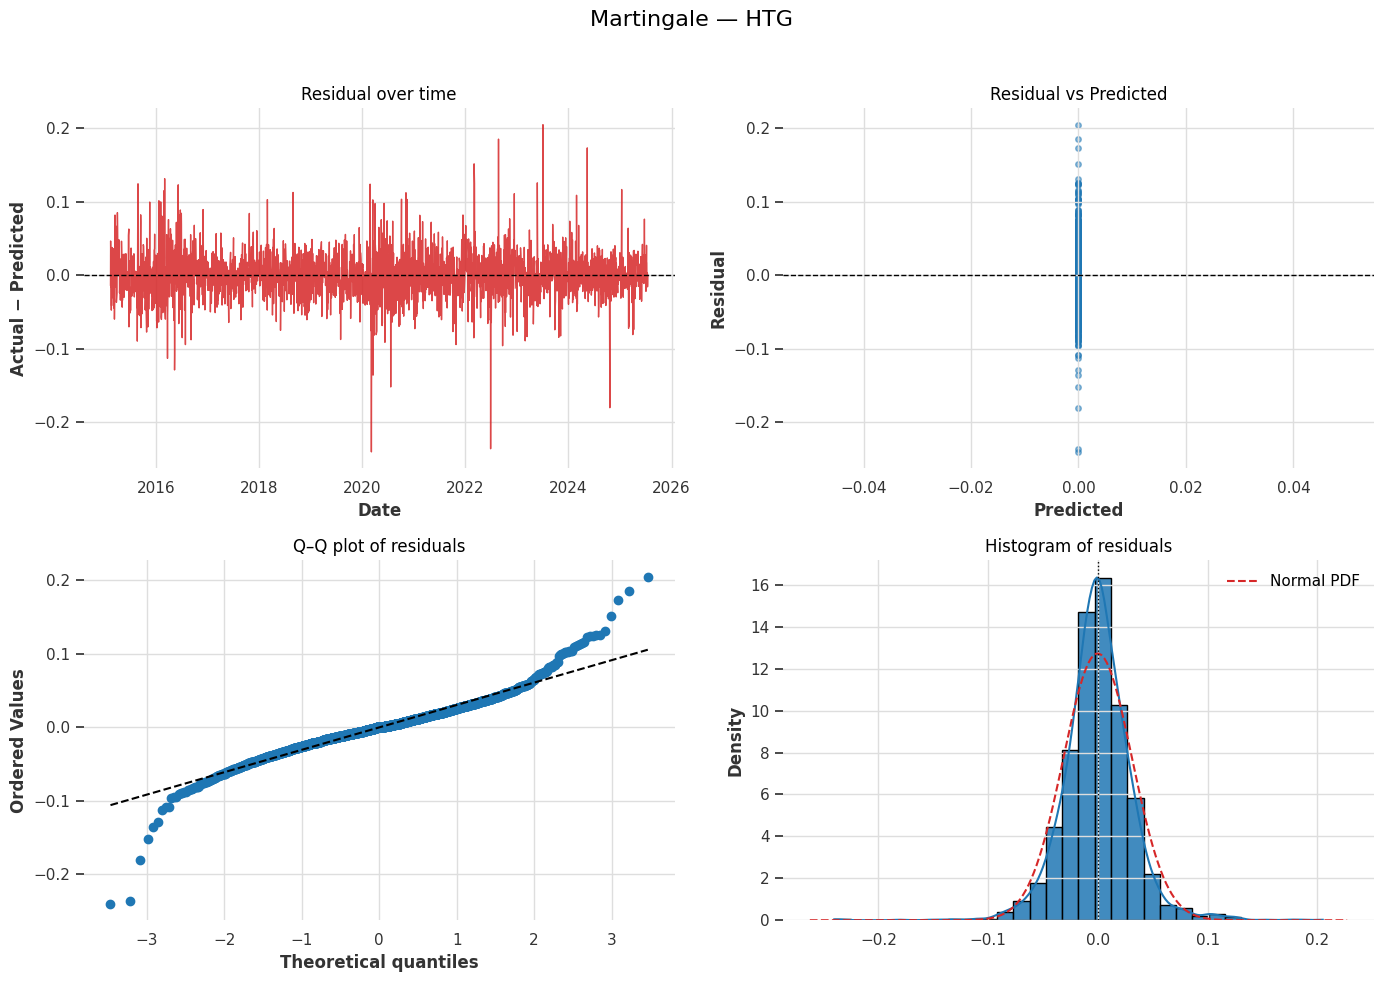

📊 Residual stats — Martingale — HTG: Mean -0.000185 | Std 0.031344 | Skew 0.029 | Kurt(excess) 5.822


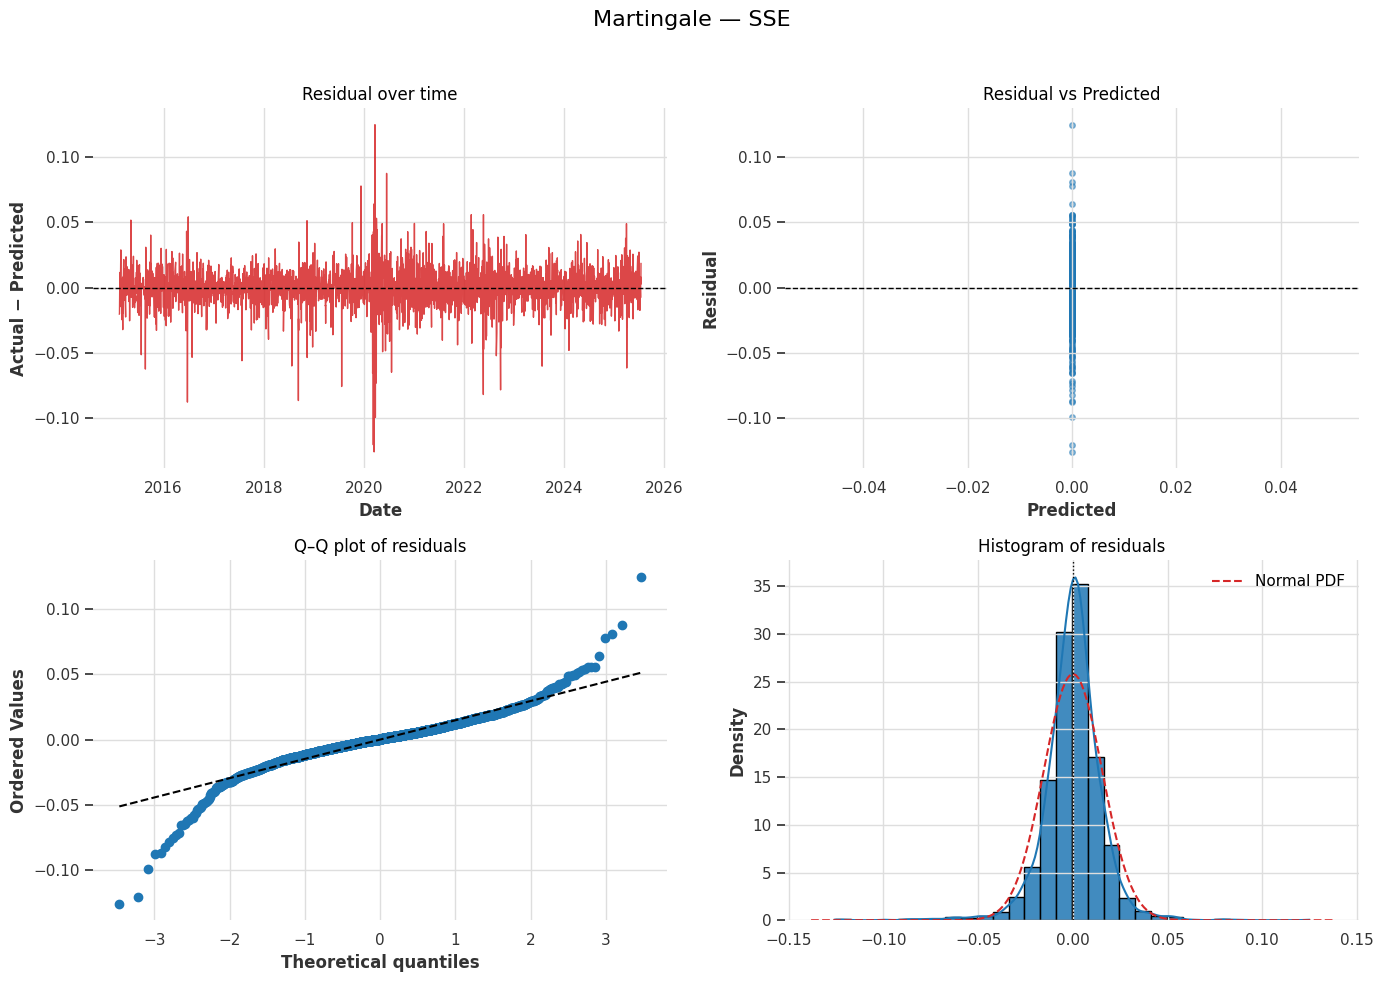

📊 Residual stats — Martingale — SSE: Mean 0.000065 | Std 0.015452 | Skew -0.603 | Kurt(excess) 8.809


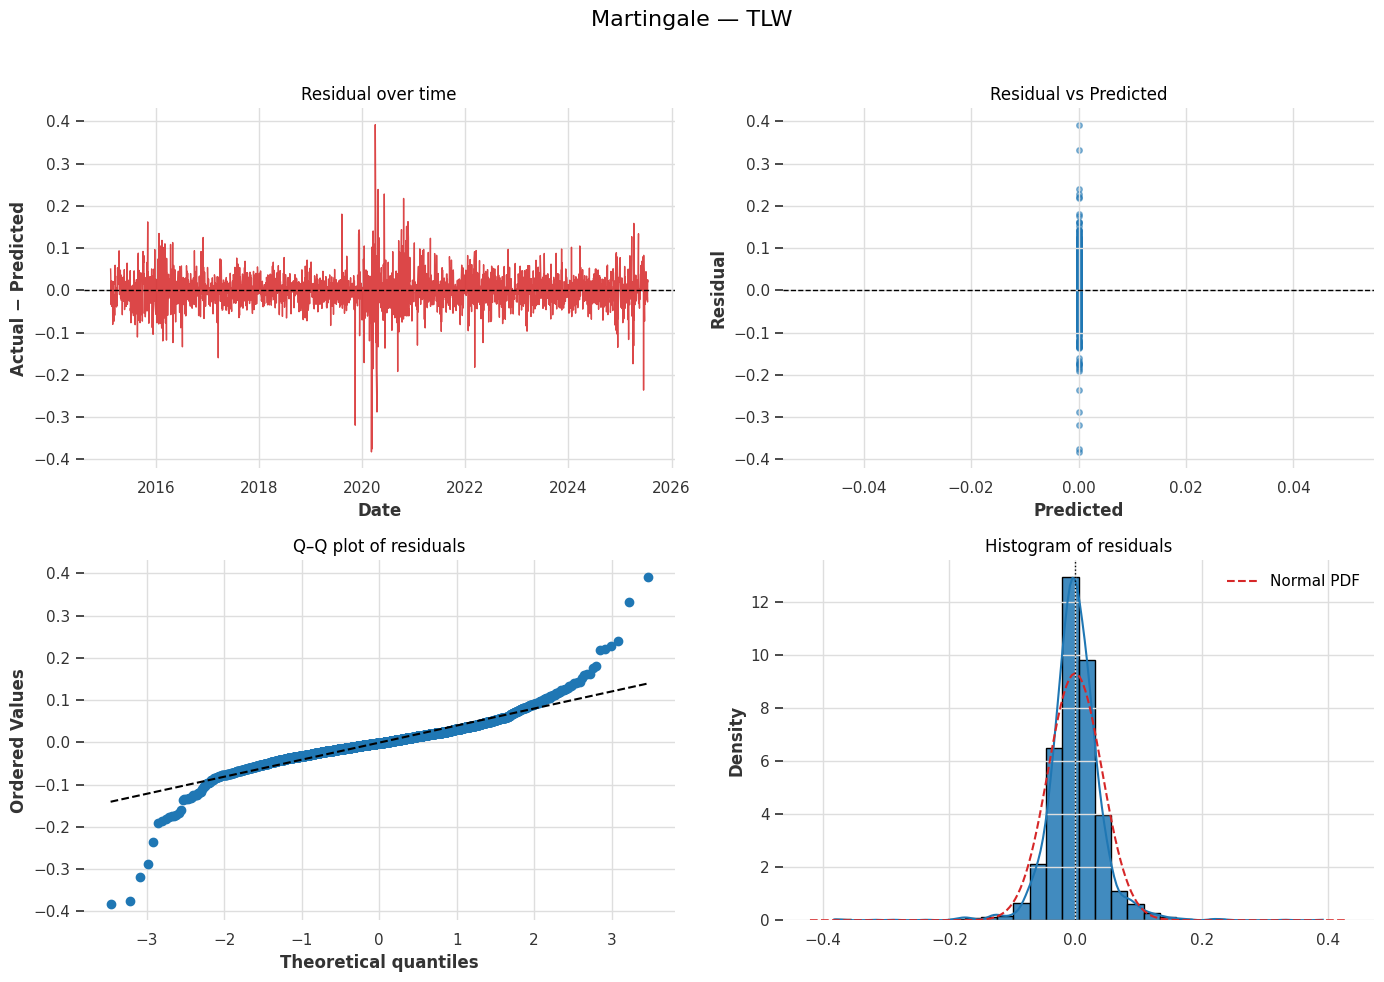

📊 Residual stats — Martingale — TLW: Mean -0.000673 | Std 0.042822 | Skew -0.113 | Kurt(excess) 13.011


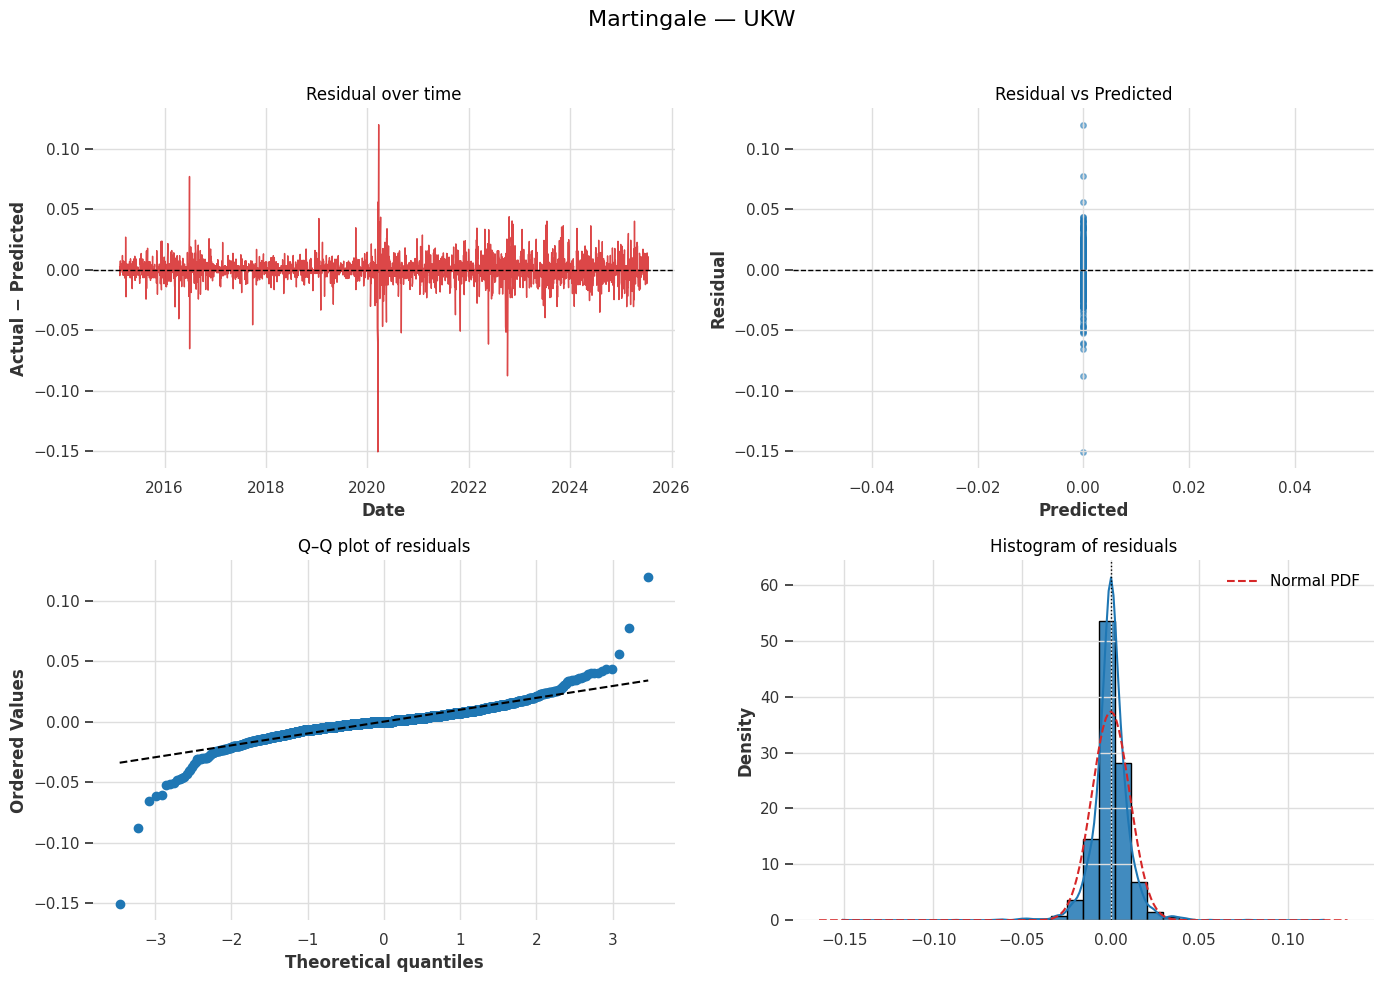

📊 Residual stats — Martingale — UKW: Mean 0.000084 | Std 0.010681 | Skew -0.891 | Kurt(excess) 26.945


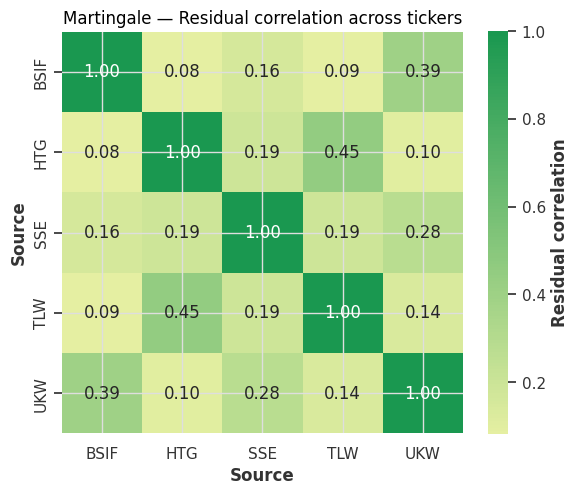

In [3]:
# =========================
# Residual diagnostics — Martingale (naive baseline)
# =========================

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

evaluate_naive_model = evaluate_naive_model_zero
# Ensure df_eval exists (your evaluate_naive_model returns it)
try:
    _ = df_eval
except NameError:
    df_eval = evaluate_naive_model(df_theoretical, model_name="Martingale", metrics_file=os.path.join("outputs", "model_metrics.csv"))

FIG_DIR = os.path.join("outputs", "martingale", "diagnostics")
os.makedirs(FIG_DIR, exist_ok=True)

# ---------- Load/Prep ----------
df = df_eval.copy()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"]).sort_values(["Source","Date"])
df["Error"] = df["Actual"] - df["Predicted"]

# Color map identical to ARIMAX/LSTM block
BYG = sns.blend_palette(["#2166ac", "#f7f7a9", "#1a9850"], as_cmap=True)

def set_nice_date_axis(ax):
    loc = mdates.AutoDateLocator(minticks=5, maxticks=8)
    fmt = mdates.ConciseDateFormatter(loc)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(fmt)

def plot_diagnostics_with_stats(actual, predicted, dates=None, title=""):
    errors = np.asarray(actual) - np.asarray(predicted)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=16)

    # 1) Residual over time (RED) + readable dates
    if dates is not None:
        axes[0, 0].plot(pd.to_datetime(dates), errors, color="#d62728", linewidth=1.0, alpha=0.85)
        axes[0, 0].set_xlabel("Date"); set_nice_date_axis(axes[0, 0])
    else:
        axes[0, 0].plot(errors, color="#d62728", linewidth=1.0, alpha=0.85)
        axes[0, 0].set_xlabel("Index")
    axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0, 0].set_title("Residual over time")
    axes[0, 0].set_ylabel("Actual − Predicted")

    # 2) Residual vs Predicted (BLUE)
    axes[0, 1].scatter(predicted, errors, alpha=0.5, s=16, color="#1f77b4")
    axes[0, 1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0, 1].set_title("Residual vs Predicted")
    axes[0, 1].set_xlabel("Predicted")
    axes[0, 1].set_ylabel("Residual")

    # 3) Q–Q (BLUE points, black dashed ref line)
    stats.probplot(errors, dist="norm", plot=axes[1, 0])
    for ln in axes[1, 0].get_lines()[:-1]:
        ln.set_color("#1f77b4")
    axes[1, 0].get_lines()[-1].set_color("black")
    axes[1, 0].get_lines()[-1].set_linestyle("--")
    axes[1, 0].set_title("Q–Q plot of residuals")

    # 4) Histogram (BLUE) + Normal PDF (RED dashed)
    sns.histplot(errors, kde=True, stat="density", bins=30, ax=axes[1, 1], color="#1f77b4", alpha=0.85)
    xmin, xmax = axes[1, 1].get_xlim()
    x = np.linspace(xmin, xmax, 200)
    pdf = stats.norm.pdf(x, np.nanmean(errors), np.nanstd(errors))
    axes[1, 1].plot(x, pdf, color="#d62728", linestyle="--", label="Normal PDF")
    axes[1, 1].axvline(0, color="black", linestyle=":", linewidth=1)
    axes[1, 1].set_title("Histogram of residuals")
    axes[1, 1].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig, errors

# ---------- 0) Overall ----------
title = "Martingale — ALL"
fig, errs = plot_diagnostics_with_stats(df["Actual"].values, df["Predicted"].values, df["Date"].values, title)
fig.savefig(os.path.join(FIG_DIR, "martingale_overall.png"), dpi=160)
plt.show()
print(f"📊 Residual stats — {title}: Mean {np.nanmean(errs):.6f} | Std {np.nanstd(errs):.6f} | "
      f"Skew {stats.skew(errs, nan_policy='omit'):.3f} | Kurt(excess) {stats.kurtosis(errs, fisher=True, nan_policy='omit'):.3f}")

# ---------- 1) Per-ticker ----------
for tic, g in df.groupby("Source", sort=False):
    title = f"Martingale — {tic}"
    fig, e = plot_diagnostics_with_stats(g["Actual"].values, g["Predicted"].values, g["Date"].values, title)
    fig.savefig(os.path.join(FIG_DIR, f"martingale_{tic}.png"), dpi=160)
    plt.show()
    print(f"📊 Residual stats — {title}: Mean {np.nanmean(e):.6f} | Std {np.nanstd(e):.6f} | "
          f"Skew {stats.skew(e, nan_policy='omit'):.3f} | Kurt(excess) {stats.kurtosis(e, fisher=True, nan_policy='omit'):.3f}")

# ---------- 2) Residual correlation heatmap (BYG palette) ----------
pivot = df.pivot_table(index="Date", columns="Source", values="Error").sort_index()
corr = pivot.corr(min_periods=10)
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=BYG, center=0, square=True,
            cbar_kws={"label": "Residual correlation"})
plt.title("Martingale — Residual correlation across tickers")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "martingale_resid_corr.png"), dpi=160)
plt.show()


## 2. Joint LSTM with Huber loss

### 2.1 Optional tuning provenance


In [4]:
# =========================
# LSTM TUNING (leak-free scaling) + Huber beta grid
# =========================
import time
from typing import Dict, Tuple
from sklearn.preprocessing import StandardScaler

import torch.nn as nn
from darts import TimeSeries
from darts.models import BlockRNNModel
from pytorch_lightning.callbacks import EarlyStopping

'''# ----- Paths / constants -----
DATA_DIR = os.path.join("outputs", "data")
SAVE_DIR = os.path.join("outputs", "lstm")
CONFIG_DIR = "LSTM"
os.makedirs(SAVE_DIR, exist_ok=True)
TRAIN_CSV     = os.path.join(DATA_DIR, "df_LSTM_train.csv")
TUNING_CSV    = os.path.join(SAVE_DIR, "LSTM_RMSE_tuning.csv")
BEST_CFG_JSON = os.path.join(CONFIG_DIR, "LSTM_best_config.json")

TUNE_IDS   = [0, 2]     # BSIF, SSE
N_TICKERS  = 5
ID_COL     = "ticker_id"
TARGET_COL = "log_return"
FLAGS = ["brexit_transition","covid_awareness","post_pandemic","war_ukraine","renewables"]
NUMERIC = [
    "EMA_30","RSI","MACD","YZ_vol","BrGBP_logchg",
    "MarketCap_GBP","OVX","GUK10Y","FTSE_lr"
]

GRID = {
    "lookback":      [30, 60, 90],
    "hidden_dim":    [32, 64],
    "n_rnn_layers":  [1, 2],
    "dropout":       [0.0, 0.2],
    "huber_beta":    [0.05, 0.075, 0.1],     # <— your request
}

VAL_FRACTION   = 0.10
MAX_EPOCHS     = 100
EARLY_PATIENCE = 12
LR             = 1e-3
BATCH          = 32
SEED           = 42

# ----- Load & prep -----
df = (pd.read_csv(TRAIN_CSV, parse_dates=["Date"])
        .set_index("Date").sort_index())

# OHE tickers
ohe_cols = [f"tic_{i}" for i in range(N_TICKERS)]
ohe = pd.get_dummies(df[ID_COL], prefix="tic")
for c in ohe_cols:
    if c not in ohe: ohe[c] = 0
ohe = ohe[ohe_cols].astype("int8")
df = pd.concat([df, ohe], axis=1)

NUMERIC = [c for c in NUMERIC if c in df.columns]
COV_COLS = NUMERIC + [c for c in FLAGS if c in df.columns] + ohe_cols
assert df[[TARGET_COL] + COV_COLS].isna().sum().sum() == 0, "NaNs remain."

# Cache raw arrays
Raw: Dict[int, Tuple[np.ndarray, np.ndarray, int]] = {}
for tid, df_t in df.groupby(ID_COL):
    df_t = df_t.sort_index()
    y_vals = df_t[TARGET_COL].to_numpy(np.float32)
    X_vals = df_t[COV_COLS].to_numpy(np.float32)
    Raw[int(tid)] = (y_vals, X_vals, len(df_t))
NUM_IDX = [COV_COLS.index(c) for c in NUMERIC]

def embargo_split_idx(n: int, lookback: int, val_fraction: float) -> int:
    cut = int(np.floor((1 - val_fraction) * n))
    s = min(n - 1, cut + max(lookback, 5))
    return max(s, lookback)

def split_idx_for(tid: int, lb: int) -> int:
    _, _, n = Raw[tid]
    return embargo_split_idx(n, lb, VAL_FRACTION)

def build_full_series_scaled(tids, lb):
    # fit scaler on TRAIN windows only (stack over tuning tickers)
    scaler = StandardScaler()
    blocks = []
    s_idx = {}
    for tid in tids:
        y, X, _ = Raw[tid]
        s = split_idx_for(tid, lb); s_idx[tid] = s
        if NUM_IDX and s > 0:
            blocks.append(X[:s, NUM_IDX])
    scaler.fit(np.vstack(blocks))
    # transform full series once
    Y_ts, X_ts = {}, {}
    for tid in tids:
        y, X, _ = Raw[tid]
        Xs = X.copy()
        if NUM_IDX:
            Xs[:, NUM_IDX] = scaler.transform(Xs[:, NUM_IDX])
        Y_ts[tid] = TimeSeries.from_values(y.astype(np.float32))
        X_ts[tid] = TimeSeries.from_values(Xs.astype(np.float32))
    return Y_ts, X_ts, s_idx

def rmse_on_val(model, y_ts, X_ts, start_idx):
    fc = model.historical_forecasts(
        series=y_ts, past_covariates=X_ts,
        start=y_ts.time_index[start_idx],
        forecast_horizon=1, stride=1, retrain=False,
        last_points_only=True, verbose=False,
    )
    fc = fc.slice_intersect(y_ts)
    p = fc.values().squeeze()
    t = y_ts.slice_intersect(fc).values().squeeze()
    m = np.isfinite(p) & np.isfinite(t)
    if m.sum() == 0: return np.nan, 0
    return float(np.sqrt(np.mean((t[m]-p[m])**2))), int(m.sum())

# CSV header
cols = ["lookback","hidden_dim","n_layers","dropout","huber_beta",
        "rmse_BSIF","rmse_SSE","rmse_mean","steps_BSIF","steps_SSE","steps_total","secs"]
if not os.path.exists(TUNING_CSV):
    pd.DataFrame(columns=cols).to_csv(TUNING_CSV, index=False)

best = {"rmse": np.inf, "cfg": None}
total = (len(GRID["lookback"])*len(GRID["hidden_dim"])*len(GRID["n_rnn_layers"])*len(GRID["dropout"])*len(GRID["huber_beta"]))
i = 0
print(f"Tuning {total} configs (BlockRNN + past_covariates + StandardScaler + Huber beta)…")

for lb in GRID["lookback"]:
    # scale per-lookback (fit on TRAIN windows)
    Y_full, X_full, s_idx = build_full_series_scaled(TUNE_IDS, lb)

    for hd in GRID["hidden_dim"]:
        for nl in GRID["n_rnn_layers"]:
            for dr in GRID["dropout"]:
                for beta in GRID["huber_beta"]:
                    i += 1
                    t0 = time.time()
                    print(f"\n[{i}/{total}] lb={lb}, hd={hd}, layers={nl}, dropout={dr}, beta={beta}")

                    # build per-ticker train/val
                    S_TR, C_TR, S_VAL, C_VAL = [], [], [], []
                    for tid in TUNE_IDS:
                        s = s_idx[tid]
                        y_tr, y_val = Y_full[tid].split_before(s)
                        X_tr, X_val = X_full[tid].split_before(s)
                        S_TR.append(y_tr);  C_TR.append(X_tr)
                        S_VAL.append(y_val); C_VAL.append(X_val)

                    es = EarlyStopping(monitor="val_loss", patience=EARLY_PATIENCE, mode="min")

                    model = BlockRNNModel(
                        model="LSTM",
                        input_chunk_length=lb,
                        output_chunk_length=1,
                        hidden_dim=hd,
                        n_rnn_layers=nl,
                        dropout=dr,
                        batch_size=BATCH,
                        n_epochs=MAX_EPOCHS,
                        optimizer_kwargs={"lr": LR},
                        random_state=SEED,
                        likelihood=None,
                        loss_fn=nn.SmoothL1Loss(beta=float(beta), reduction="mean"),  # Huber
                        pl_trainer_kwargs={
                            "enable_progress_bar": True,
                            "logger": False,
                            "log_every_n_steps": 1,
                            "accelerator": "cpu",
                            "callbacks": [es],
                            "enable_checkpointing": False,
                        },
                    )

                    try:
                        model.fit(series=S_TR, past_covariates=C_TR,
                                  val_series=S_VAL, val_past_covariates=C_VAL,
                                  verbose=True)

                        rmse_vals, steps_vals = [], []
                        for tid in TUNE_IDS:
                            r, u = rmse_on_val(model, Y_full[tid], X_full[tid], s_idx[tid])
                            rmse_vals.append(r); steps_vals.append(u)

                        r_bsif, r_sse = rmse_vals
                        u_bsif, u_sse = steps_vals
                        r_mean = float(np.nanmean(rmse_vals))
                        secs = round(time.time() - t0, 1)

                        print(f"→ RMSE BSIF={r_bsif:.6f}, SSE={r_sse:.6f}, mean={r_mean:.6f} | steps={u_bsif+u_sse} in {secs}s")

                        row = pd.DataFrame([{
                            "lookback": lb, "hidden_dim": hd, "n_layers": nl, "dropout": dr, "huber_beta": beta,
                            "rmse_BSIF": r_bsif, "rmse_SSE": r_sse, "rmse_mean": r_mean,
                            "steps_BSIF": u_bsif, "steps_SSE": u_sse, "steps_total": u_bsif + u_sse,
                            "secs": secs
                        }])
                        with open(TUNING_CSV, "a", newline="") as f:
                            row.to_csv(f, header=False, index=False)

                        if np.isfinite(r_mean) and r_mean < best["rmse"]:
                            best = {"rmse": r_mean, "cfg": {
                                "lookback": lb, "hidden_dim": hd, "n_layers": nl, "dropout": dr, "huber_beta": float(beta)
                            }}
                            with open(BEST_CFG_JSON, "w") as fp:
                                json.dump({
                                    "best_config": best["cfg"],
                                    "best_val_RMSE": best["rmse"],
                                    "tune_tickers": ["BSIF","SSE"]
                                }, fp, indent=2)

                    except Exception as e:
                        secs = round(time.time() - t0, 1)
                        print(f"FAIL lb={lb}, hd={hd}, layers={nl}, dr={dr}, beta={beta}: {e}")
                        row = pd.DataFrame([{
                            "lookback": lb, "hidden_dim": hd, "n_layers": nl, "dropout": dr, "huber_beta": beta,
                            "rmse_BSIF": np.nan, "rmse_SSE": np.nan, "rmse_mean": np.nan,
                            "steps_BSIF": 0, "steps_SSE": 0, "steps_total": 0,
                            "secs": secs
                        }])
                        with open(TUNING_CSV, "a", newline="") as f:
                            row.to_csv(f, header=False, index=False)

print("\nBest:", best)
'''

<VENV>\Lib\site-packages\fs\__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


'# ----- Paths / constants -----\nDATA_DIR = os.path.join("outputs", "data")\nSAVE_DIR = os.path.join("outputs", "lstm")\nCONFIG_DIR = "LSTM"\nos.makedirs(SAVE_DIR, exist_ok=True)\nTRAIN_CSV     = os.path.join(DATA_DIR, "df_LSTM_train.csv")\nTUNING_CSV    = os.path.join(SAVE_DIR, "LSTM_RMSE_tuning.csv")\nBEST_CFG_JSON = os.path.join(CONFIG_DIR, "LSTM_best_config.json")\n\nTUNE_IDS   = [0, 2]     # BSIF, SSE\nN_TICKERS  = 5\nID_COL     = "ticker_id"\nTARGET_COL = "log_return"\nFLAGS = ["brexit_transition","covid_awareness","post_pandemic","war_ukraine","renewables"]\nNUMERIC = [\n    "EMA_30","RSI","MACD","YZ_vol","BrGBP_logchg",\n    "MarketCap_GBP","OVX","GUK10Y","FTSE_lr"\n]\n\nGRID = {\n    "lookback":      [30, 60, 90],\n    "hidden_dim":    [32, 64],\n    "n_rnn_layers":  [1, 2],\n    "dropout":       [0.0, 0.2],\n    "huber_beta":    [0.05, 0.075, 0.1],     # <— your request\n}\n\nVAL_FRACTION   = 0.10\nMAX_EPOCHS     = 100\nEARLY_PATIENCE = 12\nLR             = 1e-3\nBATCH      

### 2.2 Final training and evaluation


In [5]:
# =========================
# FINAL LSTM (BlockRNN + past_covariates, leak-free scaling, Huber)
# + unified metrics incl. BearMissRate (standard, directional p>y),
# + tolerant BMR (directional (p - y) >= eps_err),
# + z-BMR (missed ≤ robust -2σ events via train-only median–MAD, with quantile fallback)
# =========================
from typing import Tuple, Dict
from src.models import build_submitted_lstm

# -------- paths / constants --------
DATA_DIR = os.path.join("outputs", "data")
CONFIG_DIR = "LSTM"
SAVE_DIR = os.path.join("outputs", "lstm")
os.makedirs(SAVE_DIR, exist_ok=True)
TRAIN_CSV = os.path.join(DATA_DIR, "df_LSTM_train.csv")
TEST_CSV  = os.path.join(DATA_DIR, "df_LSTM_test.csv")
BEST_CFG_JSON = os.path.join(CONFIG_DIR, "LSTM_best_config.json")

FINAL_MODEL_PATH  = os.path.join(SAVE_DIR, "best_lstm_blockrnn_scaled.darts")
FINAL_STATE_DICT  = os.path.join(SAVE_DIR, "best_lstm_blockrnn_scaled_state_dict.pt")

VAL_PRED_CSV   = os.path.join(SAVE_DIR, "final_val_predictions.csv")
VAL_PRED_PARQ  = os.path.join(SAVE_DIR, "final_val_predictions.parquet")
VAL_METRICS_CSV= os.path.join(SAVE_DIR, "final_val_metrics.csv")

TEST_PRED_CSV  = os.path.join(SAVE_DIR, "final_test_predictions.csv")
TEST_PRED_PARQ = os.path.join(SAVE_DIR, "final_test_predictions.parquet")
TEST_METRICS_CSV= os.path.join(SAVE_DIR, "final_test_metrics.csv")

ROOT_METRICS_LOG = Path("outputs") / "model_metrics.csv"

ID_COL, TARGET_COL, N_TICKERS = "ticker_id", "log_return", 5
FLAGS  = ["brexit_transition","covid_awareness","post_pandemic","war_ukraine","renewables"]
NUMERIC = [
    "EMA_30","RSI","MACD","YZ_vol","BrGBP_logchg",
    "MarketCap_GBP","OVX","GUK10Y","FTSE_lr"
]

VAL_FRACTION   = 0.10
MAX_EPOCHS     = 100
EARLY_PATIENCE = 15
LR, BATCH, SEED = 1e-3, 32, 42
EPS_SIGN = 0.0  # deadband for SignAccuracy (0 = off)

# Bear Miss Rate tolerance knobs (derived from VAL, applied to both VAL/TEST)
K_ERR = 1.0   # eps_err = K_ERR * RMSE_val_per_ticker
K_NEG = 0.0   # eps_neg = K_NEG * RMSE_val_per_ticker  (0 = count all negatives as bear)

# z-BMR robust cutoff controls
MAD_MULTIPLIER = 2.0
Z_PSTAR = 0.0228  # ≈ Phi(-2)
MIN_TRAIN_TAIL_EVENTS = 5  # fallback to quantile if train tail too sparse

# -------- helpers --------
rmse = submitted_rmse

def sign_accuracy(a: np.ndarray, p: np.ndarray, eps: float = 0.0) -> float:
    if eps > 0.0:
        sa = np.sign(np.where(np.abs(a) <= eps, 0.0, a))
        sp = np.sign(np.where(np.abs(p) <= eps, 0.0, p))
    else:
        sa, sp = np.sign(a), np.sign(p)
    return float((sa == sp).mean())

bear_miss_rate_standard = submitted_bmr


# --- z-BMR helper (missed robust ≤ -2σ events). Return NaN if no events. ---
z_bear_miss_rate = submitted_bmr_z

# -------- load best cfg --------
with open(BEST_CFG_JSON, "r") as fp:
    best = json.load(fp)["best_config"]
lb, hd, nl, dr = best["lookback"], best["hidden_dim"], best["n_layers"], best["dropout"]
beta = float(best.get("huber_beta", 0.01))  # fallback if older tuning file

model_name = f"BlockRNN-LSTM(past,scaled,Huber{beta:g})-lb{lb}-h{hd}-l{nl}-dr{dr}"
print("Best config:", best)

# -------- TRAIN build (raw) --------
df_tr = pd.read_csv(TRAIN_CSV, parse_dates=["Date"]).set_index("Date").sort_index()
df_tr, ohe_cols = build_ohe(df_tr)
NUMERIC = [c for c in NUMERIC if c in df_tr.columns]
COV_COLS = NUMERIC + [c for c in FLAGS if c in df_tr.columns] + ohe_cols
assert df_tr[[TARGET_COL] + COV_COLS].isna().sum().sum() == 0, "NaNs in TRAIN."

# raw arrays per ticker + split idx
Raw: Dict[int, Tuple[np.ndarray, np.ndarray, int, np.ndarray]] = {}
split_idx: Dict[int, int] = {}
for tid, df_t in df_tr.groupby(ID_COL):
    df_t = df_t.sort_index()
    y = df_t[TARGET_COL].to_numpy(np.float32)
    X = df_t[COV_COLS].to_numpy(np.float32)
    n = len(df_t)
    s = embargo_split_idx(n, lb, VAL_FRACTION)
    Raw[int(tid)] = (y, X, n, df_t.index.to_numpy())
    split_idx[int(tid)] = s

# ---- train-only robust per-ticker cutoff t = median - 2 * 1.4826 * MAD
#      with fallback to train quantile Q(p*) if train tail too sparse
z_thresh_map: Dict[int, float] = {}
for tid in sorted(Raw.keys()):
    y, _, _, _ = Raw[tid]
    s = split_idx[tid]
    y_tr = y[:s]
    if len(y_tr) == 0:
        continue
    z_thresh_map[int(tid)] = submitted_robust_bmr_z_threshold(
        y_tr,
        mad_multiplier=MAD_MULTIPLIER,
        fallback_quantile=Z_PSTAR,
        min_tail_events=MIN_TRAIN_TAIL_EVENTS,
    )

# -------- fit StandardScaler on TRAIN windows only (all tickers) --------
num_idx = [COV_COLS.index(c) for c in NUMERIC]
scaler = fit_pooled_prefix_standard_scaler(Raw, split_idx, num_idx)

# transform FULL series (train+val) once
Y_full_ts: Dict[int, TimeSeries] = {}
X_full_ts: Dict[int, TimeSeries] = {}
dates_by_tid: Dict[int, np.ndarray] = {}
for tid in sorted(Raw.keys()):
    y, X, _, dts = Raw[tid]
    Xs = X.copy()
    if len(num_idx) > 0:
        Xs[:, num_idx] = scaler.transform(Xs[:, num_idx])
    Y_full_ts[tid] = TimeSeries.from_values(y.astype(np.float32))
    X_full_ts[tid] = TimeSeries.from_values(Xs.astype(np.float32))
    dates_by_tid[tid] = dts

# -------- model --------
model = build_submitted_lstm(
    lookback=lb, hidden_dim=hd, n_rnn_layers=nl, dropout=dr,
    batch_size=BATCH, n_epochs=MAX_EPOCHS, learning_rate=LR,
    random_state=SEED, loss_fn=nn.SmoothL1Loss(beta=beta, reduction="mean"),
    early_patience=EARLY_PATIENCE, early_min_delta=1e-6,
)

# -------- fit (scaled past_covariates) --------
S_TR, C_TR, S_VAL, C_VAL = [], [], [], []
for tid in sorted(Y_full_ts.keys()):
    s = split_idx[tid]
    y_ts = Y_full_ts[tid]; X_ts = X_full_ts[tid]
    y_tr, y_val = y_ts.split_before(s); X_tr, X_val = X_ts.split_before(s)
    S_TR.append(y_tr); C_TR.append(X_tr)
    S_VAL.append(y_val); C_VAL.append(X_val)

print("Training final model (BlockRNN + leak-free StandardScaler + Huber)…")
model.fit(series=S_TR, past_covariates=C_TR,
          val_series=S_VAL, val_past_covariates=C_VAL,
          verbose=True)

# save model + state dict
model.save(FINAL_MODEL_PATH)
try:
    torch.save(model.model.state_dict(), FINAL_STATE_DICT)
except Exception as e:
    with open(os.path.join(SAVE_DIR, "best_lstm_blockrnn_scaled_state_dict.err.txt"), "w") as f:
        f.write(str(e))

# -------- VAL predictions (dates) --------
rows_val = []
for tid in sorted(Y_full_ts.keys()):
    y_ts, X_ts = Y_full_ts[tid], X_full_ts[tid]
    s = split_idx[tid]
    fc = model.historical_forecasts(
        series=y_ts, past_covariates=X_ts,
        start=y_ts.time_index[s], forecast_horizon=1, stride=1,
        retrain=False, last_points_only=True, verbose=False,
    )
    fc = fc.slice_intersect(y_ts)
    pred = fc.values().squeeze()
    true = y_ts.slice_intersect(fc).values().squeeze()
    idxs = fc.time_index.values
    dts = dates_by_tid[tid][idxs]
    for d, p, t in zip(dts, pred, true):
        rows_val.append({"ticker_id": int(tid), "Date": pd.Timestamp(d), "y_true": float(t), "y_pred": float(p), "resid": float(t - p)})

val_df = pd.DataFrame(rows_val).sort_values(["ticker_id","Date"])
val_df.to_csv(VAL_PRED_CSV, index=False)
val_df.to_parquet(VAL_PRED_PARQ, index=False)

# ---- Build VAL-derived tolerance maps (per ticker) ----
def _rmse_series(g: pd.DataFrame) -> float:
    return rmse(g["y_true"].to_numpy(), g["y_pred"].to_numpy())

rmse_val_by_tid = (val_df.groupby("ticker_id").apply(_rmse_series).to_dict())
eps_err_map = {tid: float(K_ERR * r) for tid, r in rmse_val_by_tid.items()}
eps_neg_map = {tid: float(K_NEG * r) for tid, r in rmse_val_by_tid.items()}
# overall thresholds from VAL
rmse_val_all = rmse(val_df["y_true"].to_numpy(), val_df["y_pred"].to_numpy())
eps_err_map["ALL"] = float(K_ERR * rmse_val_all)
eps_neg_map["ALL"] = float(K_NEG * rmse_val_all)

# -------- summarize (extended with z-BMR, counts, threshold; NaN when no events) --------
def summarize_with_bmr(df_preds: pd.DataFrame, label: str, out_csv: str,
                       eps_err_map: dict, eps_neg_map: dict, eps_sign: float = 0.0,
                       z_thresh_map: dict = None):
    rows = []
    miss_total = 0
    bear_total = 0

    for tid, g in df_preds.groupby("ticker_id"):
        a = g.y_true.values; p = g.y_pred.values
        r   = rmse(a, p)
        r2  = submitted_r_squared(a, p)

        e_err = float(eps_err_map.get(tid, r))

        # Standard BMR (directional): bear y<0; miss if p > y  # CHANGED
        bmr = bear_miss_rate_standard(a, p)

        # Tolerant BMR (directional): bear y<0; miss if (p - y) >= eps_err  # CHANGED
        bear_mask = (a < 0)
        denom = int(bear_mask.sum())
        if denom == 0:
            bmr_t = 0.0
        else:
            bmr_t = submitted_bmr_tolerant(a, p, e_err)

        row = {
            "ticker_id": int(tid),
            "RMSE": r,
            "R²": r2,
            "BearMissRate": bmr,
            "BearMissRate_tol": bmr_t,
            "N": len(g)
        }

        # z-BMR per ticker (using train-only threshold)
        if z_thresh_map is not None and tid in z_thresh_map:
            t = float(z_thresh_map[tid])
            z_frac, z_miss, z_bears = z_bear_miss_rate(a, p, t)
            row["BearMissRate_z"] = z_frac
            row["z-miss"] = int(z_miss)
            row["z-bears"] = int(z_bears)
            row["z-threshold"] = t

            if z_bears > 0:
                miss_total += z_miss
                bear_total += z_bears

        rows.append(row)

    # overall row
    a_all, p_all = df_preds.y_true.values, df_preds.y_pred.values
    r   = rmse(a_all, p_all)
    r2  = submitted_r_squared(a_all, p_all)

    e_err_all = float(eps_err_map.get("ALL", r))
    bear_mask_all = (a_all < 0)
    denom_all = int(bear_mask_all.sum())
    if denom_all == 0:
        bmr_all = 0.0
        bmr_t_all = 0.0
    else:
        bmr_all = submitted_bmr(a_all, p_all)
        bmr_t_all = submitted_bmr_tolerant(a_all, p_all, e_err_all)

    overall = {
        "ticker_id": "ALL",
        "RMSE": r, "R²": r2,
        "BearMissRate": bmr_all,
        "BearMissRate_tol": bmr_t_all,
        "N": len(df_preds)
    }

    if z_thresh_map is not None:
        overall["BearMissRate_z"], _, _ = submitted_pooled_bmr_z([(miss_total, bear_total)])
        overall["z-miss"] = int(miss_total)
        overall["z-bears"] = int(bear_total)
        overall["z-threshold"] = float('nan')

    mdf = pd.DataFrame(rows + [overall])
    mdf.to_csv(out_csv, index=False)
    print(f"\n{label} metrics (tolerant BMR uses VAL-derived RMSE thresholds; directional).")
    print(mdf.to_string(index=False))
    return mdf

# ---- summarize VAL with BMRs + z-bmr (train-only thresholds) ----
_ = summarize_with_bmr(val_df, "Validation", VAL_METRICS_CSV,
                       eps_err_map=eps_err_map, eps_neg_map=eps_neg_map, eps_sign=EPS_SIGN,
                       z_thresh_map=z_thresh_map)

# -------- TEST build (apply SAME scaler; no refit) --------
df_te = pd.read_csv(TEST_CSV, parse_dates=["Date"]).set_index("Date").sort_index()
df_te, ohe_cols_te = build_ohe(df_te)
NUMERIC_TE = [c for c in NUMERIC if c in df_te.columns]
COV_COLS_TE = NUMERIC_TE + [c for c in FLAGS if c in df_te.columns] + ohe_cols_te
assert df_te[[TARGET_COL] + COV_COLS_TE].isna().sum().sum() == 0, "NaNs in TEST."

rows_test = []
for tid, df_t in df_te.groupby(ID_COL):
    df_t = df_t.sort_index()
    dates = df_t.index.to_numpy()
    y_vals = df_t[TARGET_COL].to_numpy(np.float32)
    X_vals = df_t[COV_COLS_TE].to_numpy(np.float32)
    num_idx_te = [COV_COLS_TE.index(c) for c in NUMERIC_TE]
    if len(num_idx_te) > 0:
        X_vals_scaled = X_vals.copy()
        X_vals_scaled[:, num_idx_te] = scaler.transform(X_vals[:, num_idx_te])
    else:
        X_vals_scaled = X_vals

    y_ts = TimeSeries.from_values(y_vals)
    X_ts = TimeSeries.from_values(X_vals_scaled.astype(np.float32))

    if len(y_ts) <= lb:
        continue

    fc = model.historical_forecasts(
        series=y_ts, past_covariates=X_ts,
        start=y_ts.time_index[lb], forecast_horizon=1, stride=1,
        retrain=False, last_points_only=True, verbose=False,
    )
    fc = fc.slice_intersect(y_ts)
    pred = fc.values().squeeze()
    true = y_ts.slice_intersect(fc).values().squeeze()
    idxs = fc.time_index.values
    dts = dates[idxs]
    for d, p, t in zip(dts, pred, true):
        rows_test.append({"ticker_id": int(tid), "Date": pd.Timestamp(d), "y_true": float(t), "y_pred": float(p), "resid": float(t - p)})

test_df = pd.DataFrame(rows_test).sort_values(["ticker_id","Date"])
test_df.to_csv(TEST_PRED_CSV, index=False)
test_df.to_parquet(TEST_PRED_PARQ, index=False)

# ---- summarize TEST with BMRs + z-bmr (using same train-fixed thresholds) ----
test_metrics = summarize_with_bmr(test_df, "Test", TEST_METRICS_CSV,
                                  eps_err_map=eps_err_map, eps_neg_map=eps_neg_map, eps_sign=EPS_SIGN,
                                  z_thresh_map=z_thresh_map)

# -------- append TEST metrics to global log (updated schema) --------
rows = []
for _, r in test_metrics.iterrows():
    rows.append({
        "Model": model_name,
        "Ticker": r["ticker_id"],
        "RMSE": round(float(r["RMSE"]), 8),
        "R²": round(float(r["R²"]), 5),
        "BearMissRate": round(float(r["BearMissRate"]), 5),
        "BearMissRate_tol": round(float(r["BearMissRate_tol"]), 5),
        "BearMissRate_z": round(float(r.get("BearMissRate_z", np.nan)), 5) if not pd.isna(r.get("BearMissRate_z", np.nan)) else np.nan,
    })
rows_df = pd.DataFrame(rows)
if ROOT_METRICS_LOG.exists():
    rows_df.to_csv(ROOT_METRICS_LOG, mode="a", header=False, index=False)
else:
    rows_df.to_csv(ROOT_METRICS_LOG, index=False)

print("\nDone. Saved:")
print(f"- Model: {FINAL_MODEL_PATH}")
print(f"- Val preds: {VAL_PRED_CSV} / {VAL_PRED_PARQ} (metrics: {VAL_METRICS_CSV})")
print(f"- Test preds: {TEST_PRED_CSV} / {TEST_PRED_PARQ} (metrics: {TEST_METRICS_CSV})")
print(f"- Appended TEST metrics to: {ROOT_METRICS_LOG.resolve()}")


Best config: {'lookback': 90, 'hidden_dim': 32, 'n_layers': 2, 'dropout': 0.2, 'huber_beta': 0.075}
Training final model (BlockRNN + leak-free StandardScaler + Huber)…


GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
<VENV>\Lib\site-packages\pytorch_lightning\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | SmoothL1Loss     | 0      | train
1 | train_criterion | SmoothL1Loss     | 0      | train
2 | val_criterion   | SmoothL1Loss     | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 15.1 K | train
6 | fc              | Sequential       | 33     | train
-------------------------------------------------------------
15.1 K    Trainable params
0         Non-trainable params
15.1 K    Total params
0.061     Total estimated model params size (MB)
8         Modules in train mode
0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
<VENV>\Lib\site-packages\pytorch_lightning\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Validation metrics (tolerant BMR uses VAL-derived RMSE thresholds; directional).
ticker_id     RMSE        R²  BearMissRate  BearMissRate_tol   N  BearMissRate_z  z-miss  z-bears  z-threshold
        0 0.010397 -0.026683      0.808219          0.178082 142             1.0      14       14    -0.011516
        1 0.028093 -0.014927      0.861538          0.184615 142             1.0       3        3    -0.051205
        2 0.013193 -0.128694      0.738462          0.169231 142             1.0       7        7    -0.021385
        3 0.031385 -0.029900      0.851351          0.256757 142             NaN       0        0    -0.063150
        4 0.011489 -0.085354      0.800000          0.080000 142             1.0      11       11    -0.012590
      ALL 0.020920 -0.032839      0.812500          0.176136 710             1.0      35       35          NaN


<VENV>\Lib\site-packages\pytorch_lightning\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
<VENV>\Lib\site-packages\pytorch_lightning\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
<VENV>\Lib\site-packages\pytorch_lightning\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
<VENV>\Lib\site-packages\pytorch_lightning\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.



Test metrics (tolerant BMR uses VAL-derived RMSE thresholds; directional).
ticker_id     RMSE        R²  BearMissRate  BearMissRate_tol    N  BearMissRate_z  z-miss  z-bears  z-threshold
        0 0.011199 -0.070845      0.783019          0.245283  225             1.0      31       31    -0.011516
        1 0.025667  0.019120      0.907563          0.142857  225             1.0       6        6    -0.051205
        2 0.014559 -0.127919      0.684211          0.175439  225             1.0      14       14    -0.021385
        3 0.044356  0.022519      0.917355          0.264463  225             1.0      15       15    -0.063150
        4 0.011463 -0.095343      0.812500          0.169643  225             1.0      24       24    -0.012590
      ALL 0.024880  0.005723      0.823427          0.162587 1125             1.0      90       90          NaN

Done. Saved:
- Model: outputs\lstm\best_lstm_blockrnn_scaled.darts
- Val preds: outputs\lstm\final_val_predictions.csv / outputs\lstm\final

### 2.3 Residual diagnostics


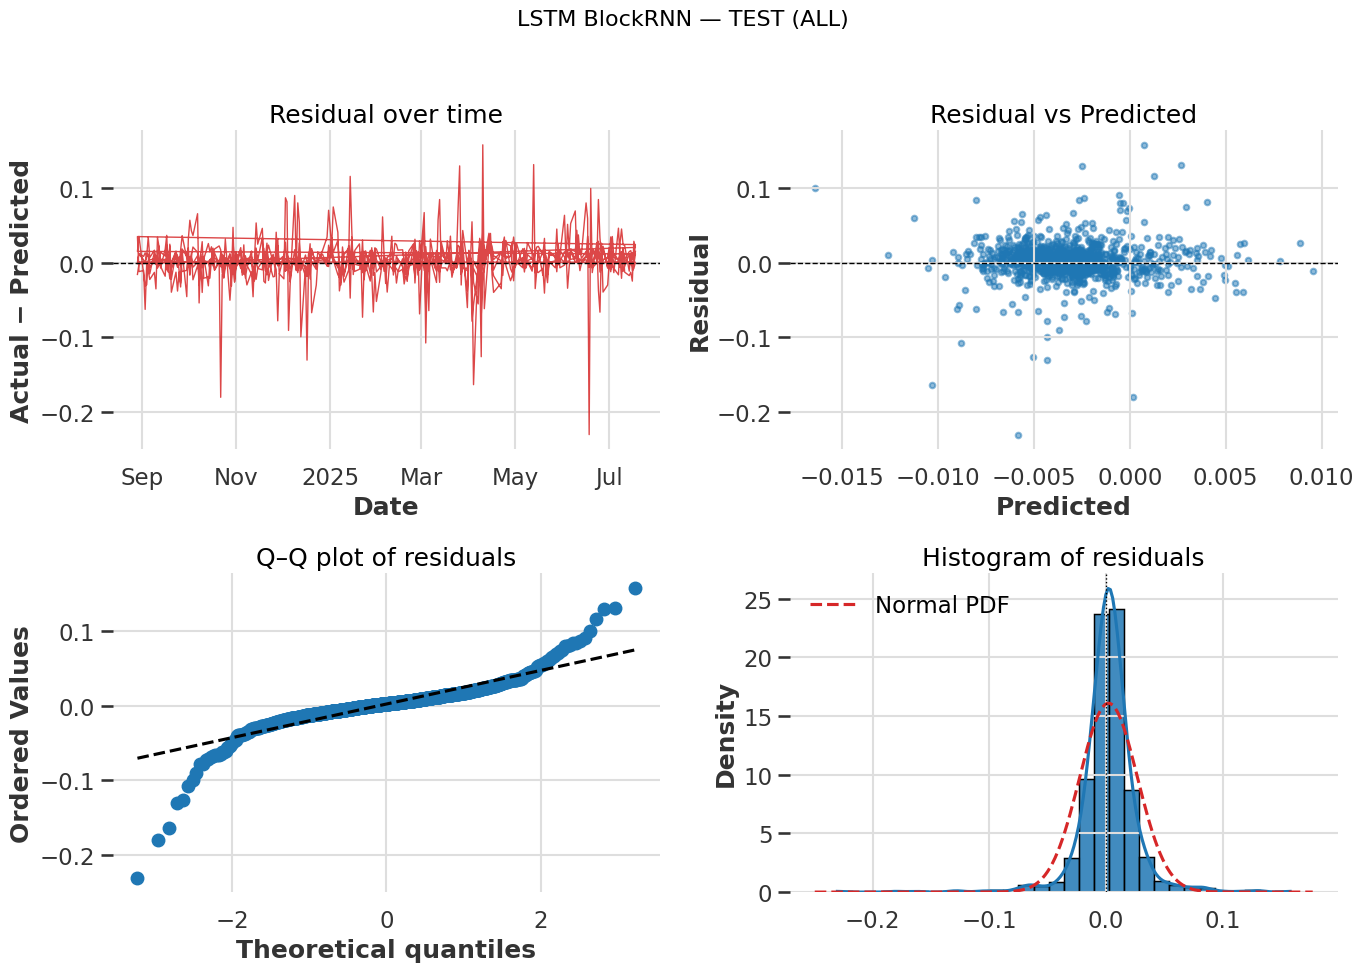

📊 Residual stats — LSTM BlockRNN — TEST (ALL): Mean 0.002104 | Std 0.024791 | Skew -1.071 | Kurt(excess) 16.232


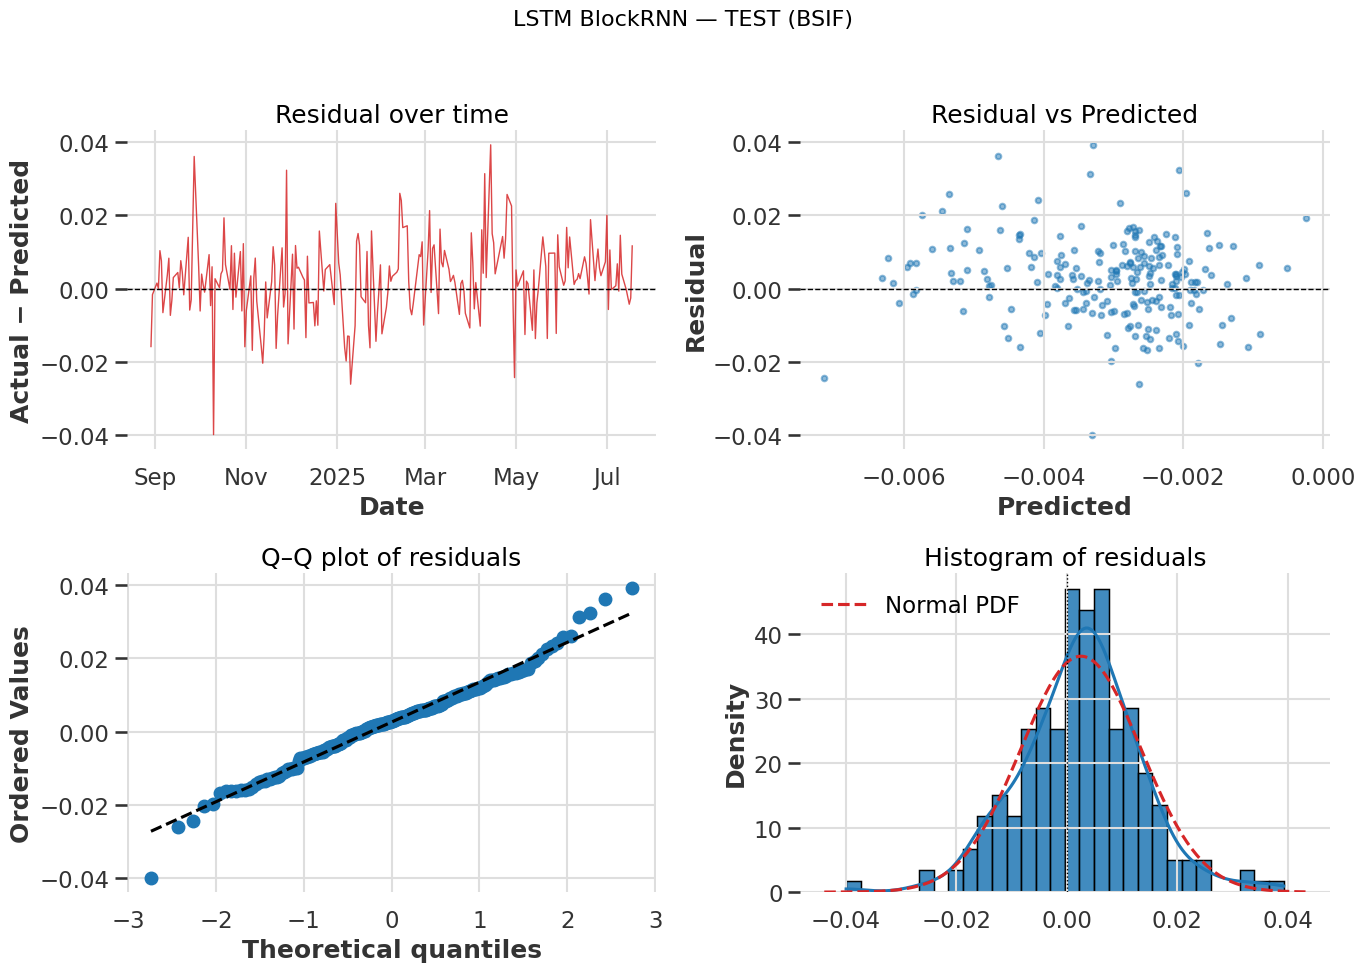

📊 Residual stats — LSTM BlockRNN — TEST (BSIF): Mean 0.002589 | Std 0.010896 | Skew -0.023 | Kurt(excess) 1.323


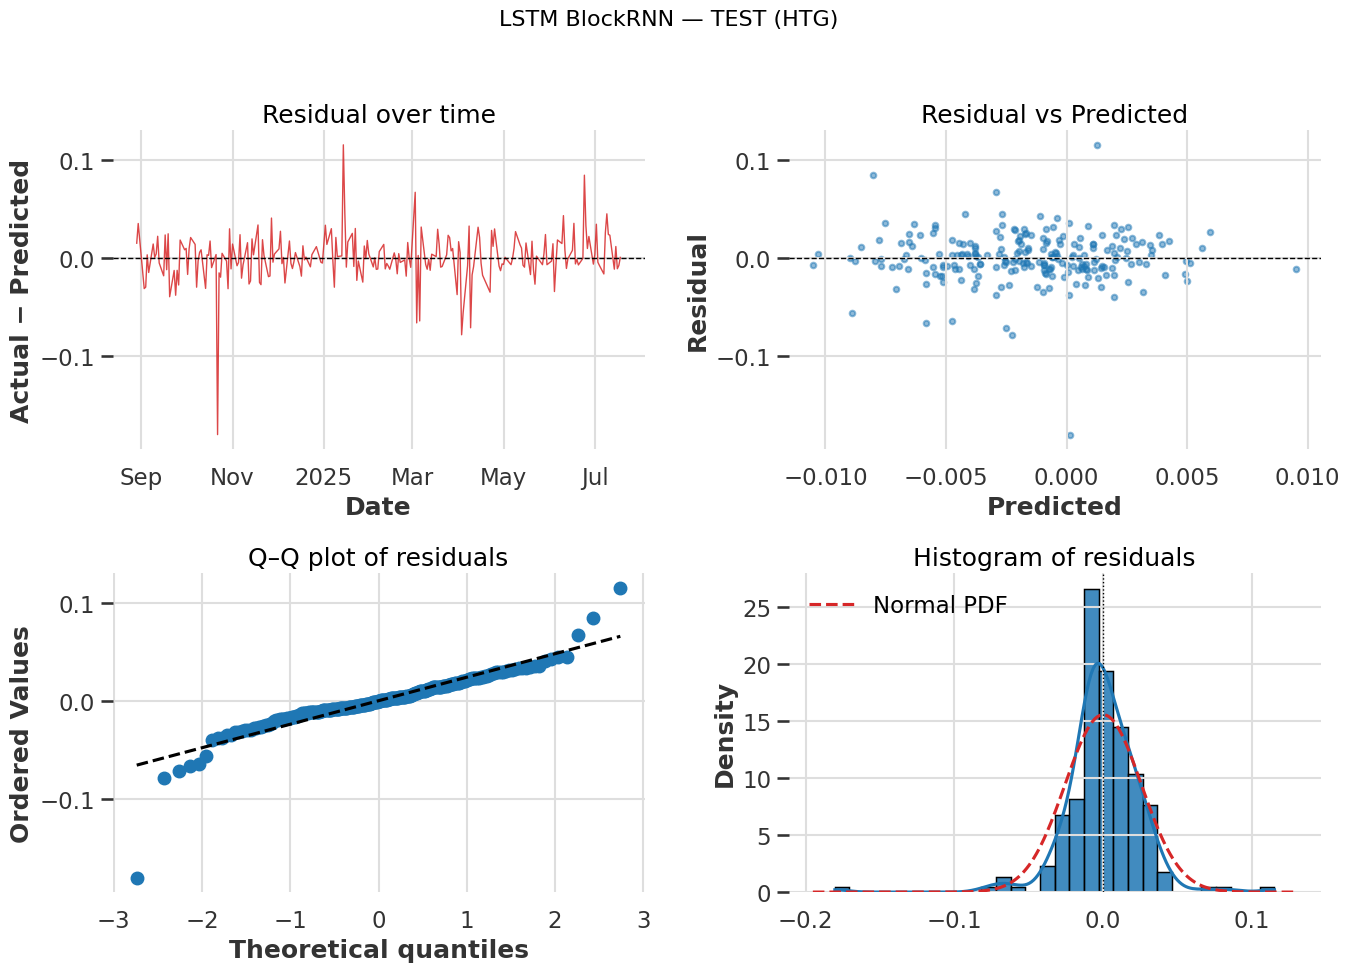

📊 Residual stats — LSTM BlockRNN — TEST (HTG): Mean 0.000189 | Std 0.025666 | Skew -1.220 | Kurt(excess) 12.132


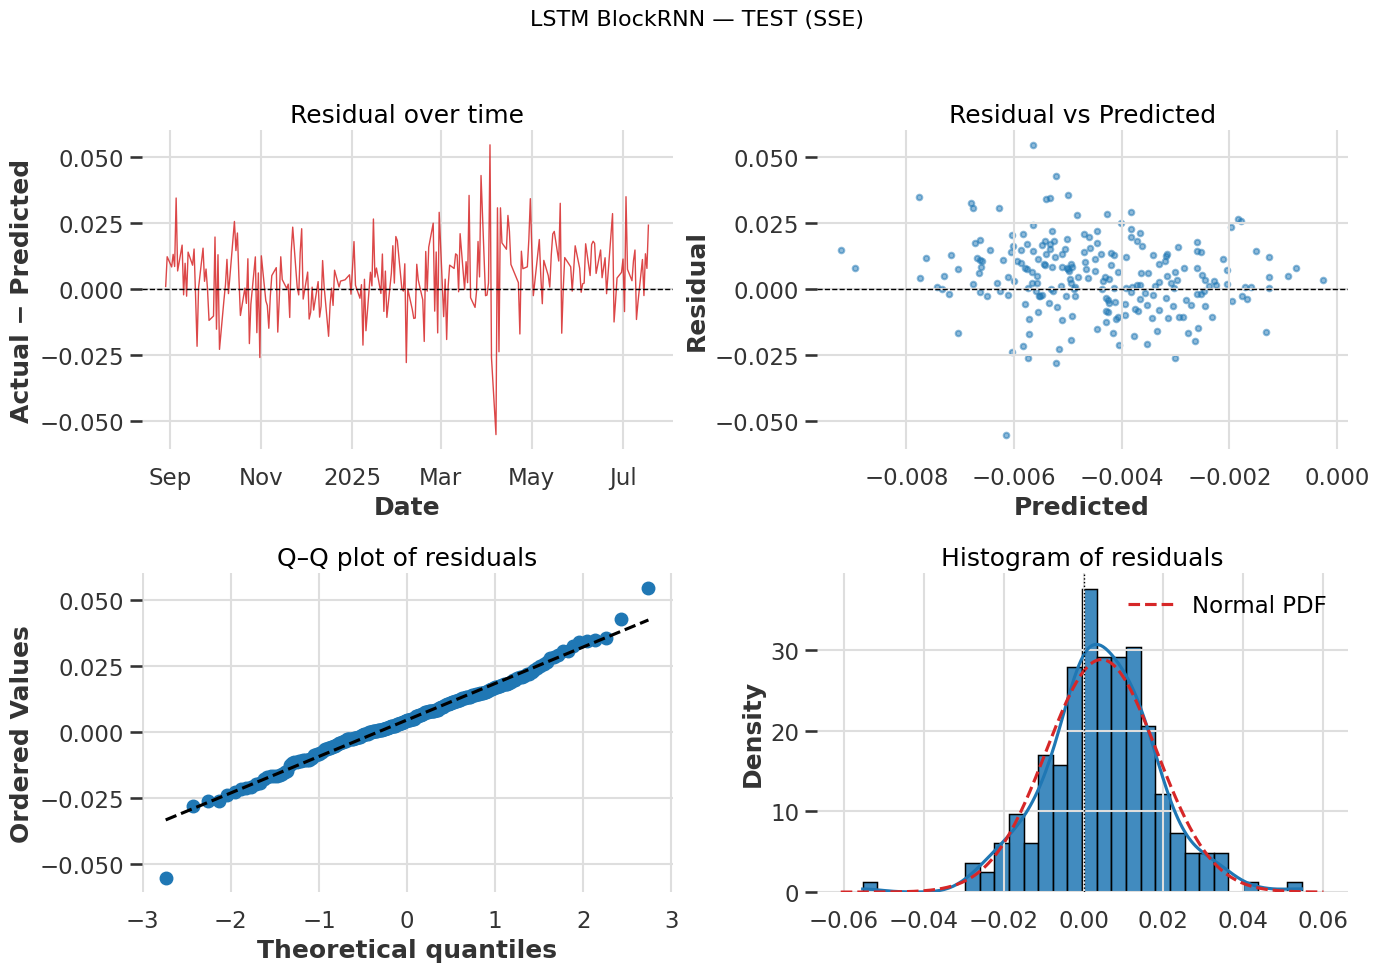

📊 Residual stats — LSTM BlockRNN — TEST (SSE): Mean 0.004476 | Std 0.013854 | Skew -0.104 | Kurt(excess) 1.629


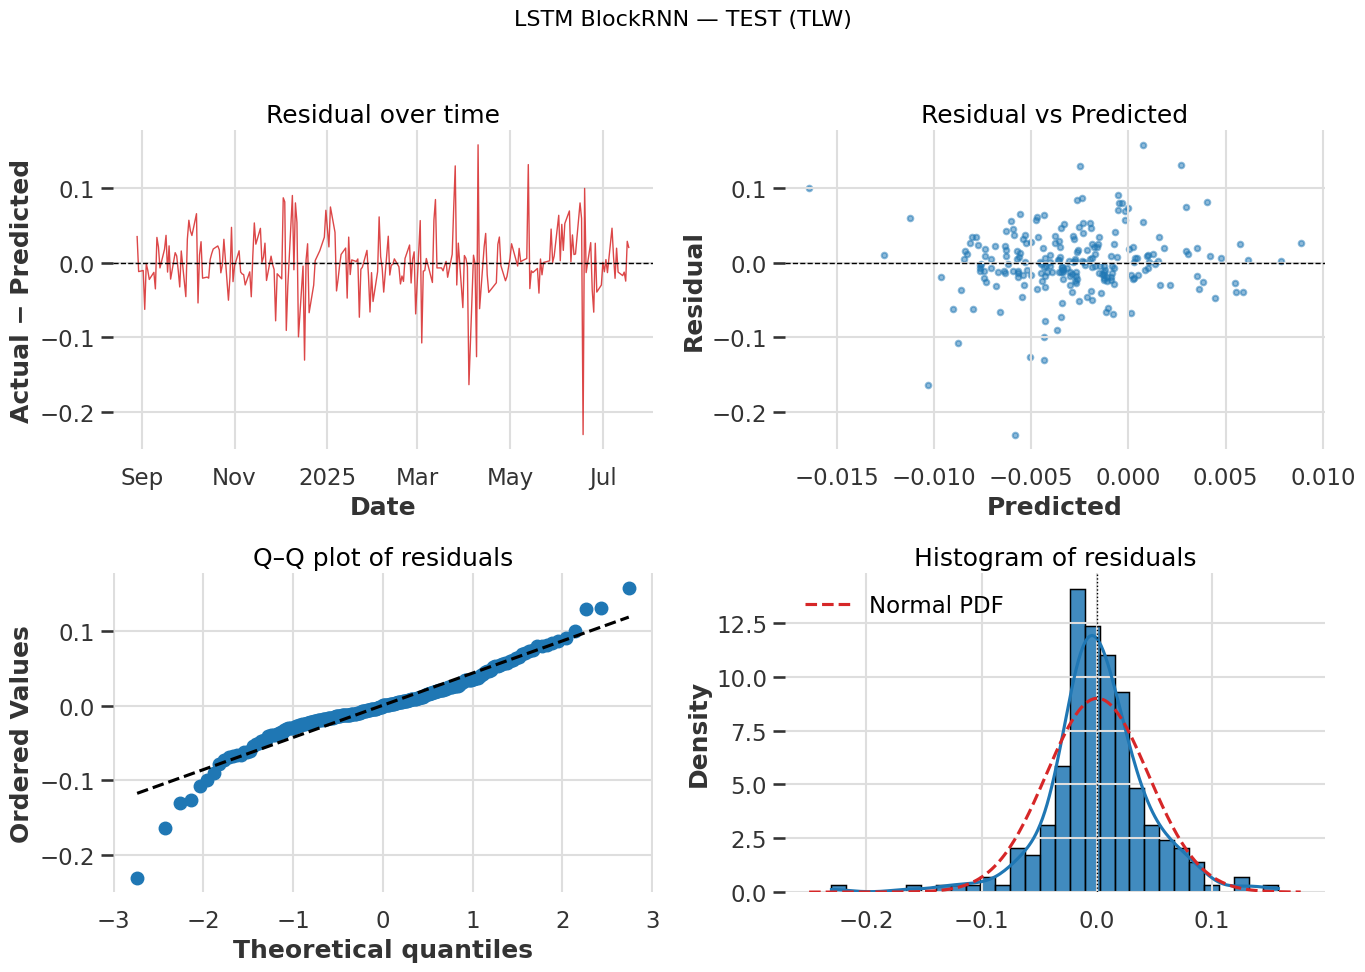

📊 Residual stats — LSTM BlockRNN — TEST (TLW): Mean 0.000497 | Std 0.044353 | Skew -0.564 | Kurt(excess) 4.479


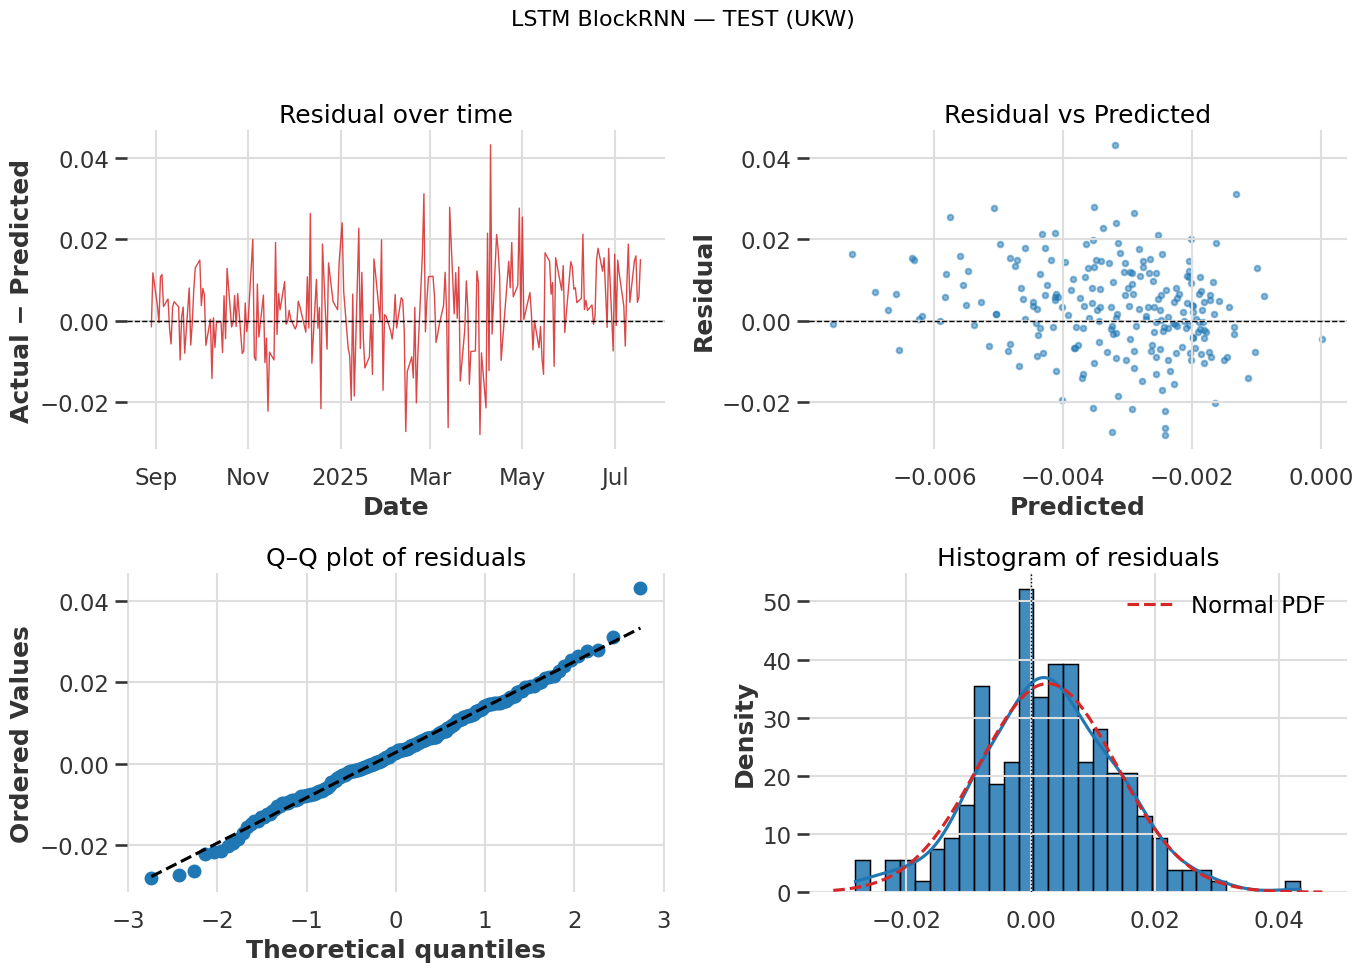

📊 Residual stats — LSTM BlockRNN — TEST (UKW): Mean 0.002767 | Std 0.011124 | Skew 0.049 | Kurt(excess) 0.581


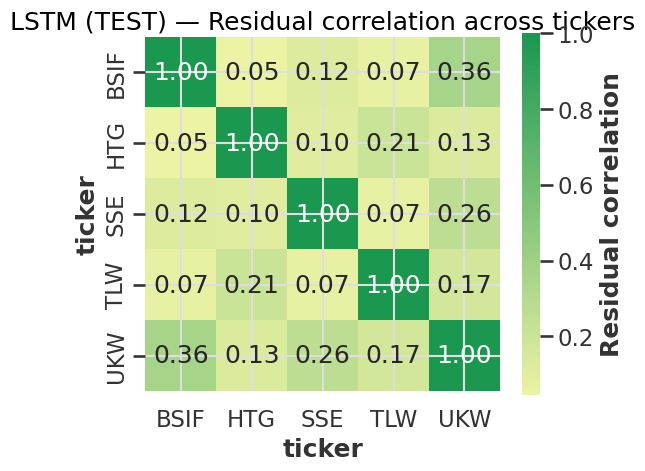

In [6]:
# =========================
# Residual diagnostics — LSTM (BlockRNN + past_covariates)
# Fixes: readable date axis + robust weekly heatmap (no “all zeros” look)
# =========================

import matplotlib.dates as mdates

sns.set_context("talk")

SET = "test"   # "test" or "val"
PTH = os.path.join("outputs", "lstm", f"final_{SET}_predictions.parquet")
FIG_DIR = os.path.join("outputs", "lstm", f"diagnostics_{SET}")
os.makedirs(FIG_DIR, exist_ok=True)

# Heatmap controls
RESAMPLE_RULE   = "W-FRI"   # robust weekly anchor
MIN_PER_WEEK    = 3         # require >=3 obs in the week; else NaN
ZSCORE_ROBUST   = True      # median/MAD robust z-score
CLIP_Z          = 4.0       # clip z-scores to [-4,4] for color stability

TICKER_MAP = {0: "BSIF", 1: "HTG", 2: "SSE", 3: "TLW", 4: "UKW"}
BYG = sns.blend_palette(["#2166ac", "#f7f7a9", "#1a9850"], as_cmap=True)

# ---------- Load ----------
df = pd.read_parquet(PTH).copy()
df["Date"] = pd.to_datetime(df["Date"])
df["ticker"] = df["ticker_id"].map(TICKER_MAP).astype("category")
df.sort_values(["ticker_id","Date"], inplace=True)

# ---------- Helpers ----------
def set_nice_date_axis(ax):
    loc = mdates.AutoDateLocator(minticks=5, maxticks=8)
    fmt = mdates.ConciseDateFormatter(loc)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(fmt)

def robust_zscore_col(s: pd.Series, clip=CLIP_Z):
    med = s.median(skipna=True)
    mad = (s - med).abs().median(skipna=True)
    if not np.isfinite(mad) or mad == 0:
        z = s - med  # fallback: mean-centering without scale
    else:
        z = (s - med) / (1.4826 * mad)
    return z.clip(-clip, clip)

def plot_diagnostics_with_stats(actual, predicted, dates=None, title=""):
    errors = np.asarray(actual) - np.asarray(predicted)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=16)

    # 1) Residual over time (RED) + readable dates
    if dates is not None:
        axes[0, 0].plot(pd.to_datetime(dates), errors, color="#d62728", linewidth=1.0, alpha=0.85)
        axes[0, 0].set_xlabel("Date"); set_nice_date_axis(axes[0, 0])
    else:
        axes[0, 0].plot(errors, color="#d62728", linewidth=1.0, alpha=0.85)
        axes[0, 0].set_xlabel("Index")
    axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0, 0].set_title("Residual over time")
    axes[0, 0].set_ylabel("Actual − Predicted")

    # 2) Residual vs Predicted (BLUE)
    axes[0, 1].scatter(predicted, errors, alpha=0.5, s=16, color="#1f77b4")
    axes[0, 1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0, 1].set_title("Residual vs Predicted")
    axes[0, 1].set_xlabel("Predicted")
    axes[0, 1].set_ylabel("Residual")

    # 3) Q–Q (BLUE points, black ref line)
    stats.probplot(errors, dist="norm", plot=axes[1, 0])
    for ln in axes[1, 0].get_lines()[:-1]:
        ln.set_color("#1f77b4")
    axes[1, 0].get_lines()[-1].set_color("black")
    axes[1, 0].get_lines()[-1].set_linestyle("--")
    axes[1, 0].set_title("Q–Q plot of residuals")

    # 4) Histogram (BLUE) + Normal PDF (RED dashed)
    sns.histplot(errors, kde=True, stat="density", bins=30, ax=axes[1, 1], color="#1f77b4", alpha=0.85)
    xmin, xmax = axes[1, 1].get_xlim()
    x = np.linspace(xmin, xmax, 200)
    pdf = stats.norm.pdf(x, np.nanmean(errors), np.nanstd(errors))
    axes[1, 1].plot(x, pdf, color="#d62728", linestyle="--", label="Normal PDF")
    axes[1, 1].axvline(0, color="black", linestyle=":", linewidth=1)
    axes[1, 1].set_title("Histogram of residuals")
    axes[1, 1].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig, errors

# ---------- 0) Overall ----------
title = f"LSTM BlockRNN — {SET.upper()} (ALL)"
fig, errs = plot_diagnostics_with_stats(df["y_true"].values, df["y_pred"].values, df["Date"].values, title)
fig.savefig(os.path.join(FIG_DIR, f"lstm_{SET}_overall.png"), dpi=160)
plt.show()
print(f"📊 Residual stats — {title}: Mean {np.nanmean(errs):.6f} | Std {np.nanstd(errs):.6f} | "
      f"Skew {stats.skew(errs, nan_policy='omit'):.3f} | Kurt(excess) {stats.kurtosis(errs, fisher=True, nan_policy='omit'):.3f}")

# ---------- 1) Per-ticker ----------
for tic, g in df.groupby("ticker", sort=False):
    title = f"LSTM BlockRNN — {SET.upper()} ({tic})"
    fig, e = plot_diagnostics_with_stats(g["y_true"].values, g["y_pred"].values, g["Date"].values, title)
    fig.savefig(os.path.join(FIG_DIR, f"lstm_{SET}_{tic}.png"), dpi=160)
    plt.show()
    print(f"📊 Residual stats — {title}: Mean {np.nanmean(e):.6f} | Std {np.nanstd(e):.6f} | "
          f"Skew {stats.skew(e, nan_policy='omit'):.3f} | Kurt(excess) {stats.kurtosis(e, fisher=True, nan_policy='omit'):.3f}")

# ---------- 2) Residual correlation heatmap (BYG) ----------
pivot = df.pivot_table(index="Date", columns="ticker", values="resid").sort_index()
corr = pivot.corr(min_periods=10)
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=BYG, center=0, square=True,
            cbar_kws={"label": "Residual correlation"})
plt.title(f"LSTM ({SET.upper()}) — Residual correlation across tickers")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"lstm_{SET}_resid_corr.png"), dpi=160)
plt.show()



## 3. Per-ticker LSTMs with Huber loss

### 3.1 Optional tuning provenance


In [7]:
'''# =========================================
# 1) TUNING — Per-ticker BlockRNN (LSTM) with past_covariates
# - leak-free: StandardScaler fit on TRAIN window only (pre-embargo)
# - integer TimeSeries indices (dates preserved separately for plots)
# - grid includes Huber β
# - writes per-ticker tuning CSVs + best cfg JSONs under PU_LSTM/
# =========================================


# -------- paths / constants --------
SRC_DIR = os.path.join("outputs", "data")
OUT_DIR = os.path.join("outputs", "pu_lstm")
CONFIG_DIR = "PU_LSTM"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(f"{OUT_DIR}/tuning", exist_ok=True)
TRAIN_CSV = os.path.join(SRC_DIR, "df_LSTM_train.csv")

# tickers
TICKER_MAP = {0:"BSIF", 1:"HTG", 2:"SSE", 3:"TLW", 4:"UKW"}
TICKERS = [0,1,2,3,4]

ID_COL, TARGET_COL = "ticker_id", "log_return"
FLAGS  = ["brexit_transition","covid_awareness","post_pandemic","war_ukraine","renewables"]
NUMERIC = [
    "EMA_30","RSI","MACD","YZ_vol","BrGBP_logchg",
    "MarketCap_GBP","OVX","GUK10Y","FTSE_lr"
]

# training / validation
VAL_FRACTION   = 0.10
MAX_EPOCHS     = 100
EARLY_PATIENCE = 12
LR, BATCH, SEED = 1e-3, 32, 42

# small, robust grid
GRID = {
    "lookback":     [60, 90],
    "hidden_dim":   [16, 32],
    "n_rnn_layers": [1, 2],
    "dropout":      [0.0, 0.2],
    "huber_beta":   [0.05, 0.075],
}

# -------- helpers --------
def embargo_split_idx(n: int, lookback: int, val_fraction: float) -> int:
    cut = int(np.floor((1 - val_fraction) * n))
    s = min(n - 1, cut + max(lookback, 5))
    return max(s, lookback)

def rmse(a, p):
    a = np.asarray(a); p = np.asarray(p)
    return float(np.sqrt(np.mean((a - p) ** 2))) if len(a) else np.nan

# -------- load training panel --------
df_tr = (pd.read_csv(TRAIN_CSV, parse_dates=["Date"])
           .set_index("Date").sort_index())
# ensure available covariates list
COV_COLS = [c for c in NUMERIC if c in df_tr.columns] + [c for c in FLAGS if c in df_tr.columns]
assert df_tr[[TARGET_COL] + COV_COLS + [ID_COL]].isna().sum().sum() == 0, "NaNs present in TRAIN."

# -------- tuning loop (per ticker) --------
for tid in TICKERS:
    name = TICKER_MAP.get(tid, str(tid))
    d = df_tr[df_tr[ID_COL] == tid].copy().sort_index()
    if d.empty:
        print(f"[{name}] no data; skip.")
        continue

    y_all = d[TARGET_COL].to_numpy(np.float32)
    X_all = d[COV_COLS].to_numpy(np.float32)
    dates = d.index.to_numpy()
    n_all = len(d)

    tune_log_csv = f"{OUT_DIR}/tuning/tune_{name}.csv"
    if not os.path.exists(tune_log_csv):
        pd.DataFrame(columns=[
            "ticker","lookback","hidden_dim","n_layers","dropout","huber_beta",
            "val_steps","val_RMSE","secs"
        ]).to_csv(tune_log_csv, index=False)

    best = {"rmse": np.inf, "cfg": None}
    total_cfgs = np.prod([len(GRID[k]) for k in GRID])
    i_cfg = 0

    print(f"\n=== Tuning {name} on {n_all} rows; grid size={total_cfgs} ===")
    for lb in GRID["lookback"]:
        s = embargo_split_idx(n_all, lb, VAL_FRACTION)

        # leak-free scaler fit **only** on train window up to s
        num_idx = [COV_COLS.index(c) for c in COV_COLS if c in NUMERIC]
        scaler = StandardScaler(with_mean=True, with_std=True)
        if num_idx:
            scaler.fit(X_all[:s, num_idx])

        # transform full series once
        X_scaled = X_all.copy()
        if num_idx:
            X_scaled[:, num_idx] = scaler.transform(X_scaled[:, num_idx])

        # build TimeSeries (integer indices)
        y_ts = TimeSeries.from_values(y_all)
        X_ts = TimeSeries.from_values(X_scaled)

        y_tr, y_val = y_ts.split_before(s)
        X_tr, X_val = X_ts.split_before(s)

        for hd in GRID["hidden_dim"]:
            for nl in GRID["n_rnn_layers"]:
                for dr in GRID["dropout"]:
                    for beta in GRID["huber_beta"]:
                        i_cfg += 1
                        t0 = time.time()
                        print(f"[{name}] ({i_cfg}/{total_cfgs}) lb={lb}, h={hd}, L={nl}, dr={dr}, β={beta}")

                        es = EarlyStopping(monitor="val_loss", patience=EARLY_PATIENCE, mode="min")

                        model = BlockRNNModel(
                            model="LSTM",
                            input_chunk_length=lb,
                            output_chunk_length=1,
                            hidden_dim=hd,
                            n_rnn_layers=nl,
                            dropout=dr,
                            batch_size=BATCH,
                            n_epochs=MAX_EPOCHS,
                            optimizer_kwargs={"lr": LR},
                            random_state=SEED,
                            likelihood=None,
                            loss_fn=nn.SmoothL1Loss(beta=float(beta), reduction="mean"),
                            pl_trainer_kwargs={
                                "enable_progress_bar": True,
                                "logger": False,
                                "log_every_n_steps": 1,
                                "accelerator": "cpu",
                                "callbacks": [es],
                                "enable_checkpointing": False,
                            },
                        )

                        try:
                            model.fit(series=y_tr, past_covariates=X_tr,
                                      val_series=y_val, val_past_covariates=X_val,
                                      verbose=True)

                            fc = model.historical_forecasts(
                                series=y_ts, past_covariates=X_ts,
                                start=y_ts.time_index[s],
                                forecast_horizon=1, stride=1,
                                retrain=False, last_points_only=True, verbose=False
                            )
                            fc = fc.slice_intersect(y_ts)
                            pred = fc.values().squeeze()
                            true = y_ts.slice_intersect(fc).values().squeeze()
                            steps = int(len(pred))
                            score = rmse(true, pred)
                            secs  = round(time.time() - t0, 1)

                            row = pd.DataFrame([{
                                "ticker": name, "lookback": lb, "hidden_dim": hd,
                                "n_layers": nl, "dropout": dr, "huber_beta": beta,
                                "val_steps": steps, "val_RMSE": score, "secs": secs
                            }])
                            row.to_csv(tune_log_csv, mode="a", header=False, index=False)

                            if np.isfinite(score) and score < best["rmse"]:
                                best = {"rmse": score,
                                        "cfg": {"lookback": lb, "hidden_dim": hd, "n_layers": nl, "dropout": dr, "huber_beta": float(beta)}}
                                with open(f"{CONFIG_DIR}/best_cfg_{name}.json", "w") as fp:
                                    json.dump({"ticker": name, "best_config": best["cfg"], "best_val_RMSE": best["rmse"]}, fp, indent=2)

                        except Exception as e:
                            secs = round(time.time() - t0, 1)
                            row = pd.DataFrame([{
                                "ticker": name, "lookback": lb, "hidden_dim": hd,
                                "n_layers": nl, "dropout": dr, "huber_beta": beta,
                                "val_steps": 0, "val_RMSE": np.nan, "secs": secs
                            }])
                            row.to_csv(tune_log_csv, mode="a", header=False, index=False)
                            print(f"  FAIL ({name}) lb={lb}, h={hd}, L={nl}, dr={dr}, β={beta}: {e}")

    print(f"Best for {name}: {best}")'''


'# =========================================\n# 1) TUNING — Per-ticker BlockRNN (LSTM) with past_covariates\n# - leak-free: StandardScaler fit on TRAIN window only (pre-embargo)\n# - integer TimeSeries indices (dates preserved separately for plots)\n# - grid includes Huber β\n# - writes per-ticker tuning CSVs + best cfg JSONs under PU_LSTM/\n# =========================================\n\n\n# -------- paths / constants --------\nSRC_DIR = os.path.join("outputs", "data")\nOUT_DIR = os.path.join("outputs", "pu_lstm")\nCONFIG_DIR = "PU_LSTM"\nos.makedirs(OUT_DIR, exist_ok=True)\nos.makedirs(f"{OUT_DIR}/tuning", exist_ok=True)\nTRAIN_CSV = os.path.join(SRC_DIR, "df_LSTM_train.csv")\n\n# tickers\nTICKER_MAP = {0:"BSIF", 1:"HTG", 2:"SSE", 3:"TLW", 4:"UKW"}\nTICKERS = [0,1,2,3,4]\n\nID_COL, TARGET_COL = "ticker_id", "log_return"\nFLAGS  = ["brexit_transition","covid_awareness","post_pandemic","war_ukraine","renewables"]\nNUMERIC = [\n    "EMA_30","RSI","MACD","YZ_vol","BrGBP_logchg",\n    "Mar

### 3.2 Final training and evaluation


In [8]:
# =========================================
# 2) TRAIN & EVAL — Per-ticker BlockRNN (LSTM) with past_covariates
# - loads best_cfg_<ticker>.json from PU_LTSM/
# - leak-free StandardScaler (fit on TRAIN window only)
# - outputs:
#   * PU_LTSM/final_val_predictions.parquet / ..._test_...
#   * PU_LTSM/final_val_metrics_bmr_compare.csv / ..._test_...
#   * per-ticker .darts models in PU_LTSM/models/
#   * appends TEST summary to model_metrics.csv
# - metrics include: RMSE, R², BearMissRate, BearMissRate_tol, BearMissRate_z (+ z-miss, z-bears, z-threshold)
# =========================================


from sklearn.metrics import mean_squared_error, r2_score
from src.models import build_submitted_lstm


# -------- paths --------
SRC_DIR = os.path.join("outputs", "data")
CONFIG_DIR = "PU_LSTM"
OUT_DIR = os.path.join("outputs", "pu_lstm")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(f"{OUT_DIR}/models", exist_ok=True)

TRAIN_CSV = os.path.join(SRC_DIR, "df_LSTM_train.csv")
TEST_CSV  = os.path.join(SRC_DIR, "df_LSTM_test.csv")
ROOT_METRICS_LOG = Path("outputs") / "model_metrics.csv"

VAL_PARQ = f"{OUT_DIR}/final_val_predictions.parquet"
TEST_PARQ= f"{OUT_DIR}/final_test_predictions.parquet"
VAL_CSV  = f"{OUT_DIR}/final_val_metrics_bmr_compare.csv"
TEST_CSV_OUT = f"{OUT_DIR}/final_test_metrics_bmr_compare.csv"

# -------- config --------
TICKER_MAP = {0:"BSIF", 1:"HTG", 2:"SSE", 3:"TLW", 4:"UKW"}
TICKERS = [0,1,2,3,4]
ID_COL, TARGET_COL = "ticker_id", "log_return"
FLAGS  = ["brexit_transition","covid_awareness","post_pandemic","war_ukraine","renewables"]
NUMERIC = [
    "EMA_30","RSI","MACD","YZ_vol","BrGBP_logchg",
    "MarketCap_GBP","OVX","GUK10Y","FTSE_lr"
]

VAL_FRACTION   = 0.10
MAX_EPOCHS     = 100
EARLY_PATIENCE = 12
LR, BATCH, SEED = 1e-3, 32, 42

# tolerance coefficient for BMR_tol (uses VAL RMSE per ticker)
K_ERR = 1.0

# z-BMR robust cutoff controls
MAD_MULTIPLIER = 2.0
Z_PSTAR = 0.0228  # ≈ Phi(-2)
MIN_TRAIN_TAIL_EVENTS = 5  # fallback to quantile if train tail too sparse

# -------- helpers --------
rmse = submitted_rmse

bmr_std = submitted_bmr

# --- z-BMR helper (missed robust ≤ -2σ events). Return NaN if no events.
z_bear_miss_rate = submitted_bmr_z

# -------- load panels --------
tr = pd.read_csv(TRAIN_CSV, parse_dates=["Date"]).set_index("Date").sort_index()
te = pd.read_csv(TEST_CSV,  parse_dates=["Date"]).set_index("Date").sort_index()

COV_COLS_TR = [c for c in NUMERIC if c in tr.columns] + [c for c in FLAGS if c in tr.columns]
COV_COLS_TE = [c for c in NUMERIC if c in te.columns] + [c for c in FLAGS if c in te.columns]
assert tr[[TARGET_COL] + COV_COLS_TR + [ID_COL]].isna().sum().sum() == 0, "NaNs in TRAIN."
assert te[[TARGET_COL] + COV_COLS_TE + [ID_COL]].isna().sum().sum() == 0, "NaNs in TEST."

# storage
val_rows, test_rows = [], []

# for z-BMR thresholds per ticker (train-only)
z_thresh_map: Dict[int, float] = {}

# -------- per-ticker train/eval --------
for tid in TICKERS:
    name = TICKER_MAP.get(tid, str(tid))
    cfg_path = f"{CONFIG_DIR}/best_cfg_{name}.json"
    if not os.path.exists(cfg_path):
        print(f"[{name}] Missing best cfg file at {cfg_path}; skip.")
        continue

    best = json.load(open(cfg_path, "r"))["best_config"]
    lb = best["lookback"]; hd = best["hidden_dim"]; nl = best["n_layers"]; dr = best["dropout"]
    beta = float(best.get("huber_beta", 0.01))

    # TRAIN slice
    dtr = tr[tr[ID_COL] == tid].copy().sort_index()
    y_tr_all = dtr[TARGET_COL].to_numpy(np.float32)
    X_tr_all = dtr[COV_COLS_TR].to_numpy(np.float32)
    dates_tr = dtr.index.to_numpy()
    n_tr = len(dtr)

    s = embargo_split_idx(n_tr, lb, VAL_FRACTION)

    # --- robust z-threshold from TRAIN window only (median - 2 * 1.4826 * MAD; fallback quantile) ---
    y_tr_only = y_tr_all[:s]
    if len(y_tr_only) > 0:
        z_thresh_map[int(tid)] = submitted_robust_bmr_z_threshold(
            y_tr_only,
            mad_multiplier=MAD_MULTIPLIER,
            fallback_quantile=Z_PSTAR,
            min_tail_events=MIN_TRAIN_TAIL_EVENTS,
        )

    # scaler fit on train window only
    num_idx_tr = [COV_COLS_TR.index(c) for c in COV_COLS_TR if c in NUMERIC]
    scaler = fit_prefix_standard_scaler(X_tr_all, s, num_idx_tr)

    # transform full TRAIN series
    X_tr_scaled = X_tr_all.copy()
    if num_idx_tr:
        X_tr_scaled[:, num_idx_tr] = scaler.transform(X_tr_scaled[:, num_idx_tr])

    y_ts = TimeSeries.from_values(y_tr_all)
    X_ts = TimeSeries.from_values(X_tr_scaled)
    y_tr_win, y_val_win = y_ts.split_before(s)
    X_tr_win, X_val_win = X_ts.split_before(s)

    # model
    model = build_submitted_lstm(
        lookback=lb, hidden_dim=hd, n_rnn_layers=nl, dropout=dr,
        batch_size=BATCH, n_epochs=MAX_EPOCHS, learning_rate=LR,
        random_state=SEED, loss_fn=nn.SmoothL1Loss(beta=beta, reduction="mean"),
        early_patience=EARLY_PATIENCE, early_min_delta=0.0,
    )

    print(f"\n[{name}] Train final model: lb={lb}, h={hd}, L={nl}, dr={dr}, β={beta}")
    model.fit(series=y_tr_win, past_covariates=X_tr_win,
              val_series=y_val_win, val_past_covariates=X_val_win, verbose=True)

    # save model
    model_path = f"{OUT_DIR}/models/{name}_best_lstm.darts"
    model.save(model_path)

    # VAL preds
    fc = model.historical_forecasts(
        series=y_ts, past_covariates=X_ts,
        start=y_ts.time_index[s], forecast_horizon=1, stride=1,
        retrain=False, last_points_only=True, verbose=False
    )
    fc = fc.slice_intersect(y_ts)
    pred = fc.values().squeeze()
    true = y_ts.slice_intersect(fc).values().squeeze()
    idxs = fc.time_index.values
    dts  = dates_tr[idxs]
    for d, p, t in zip(dts, pred, true):
        val_rows.append({
            "ticker_id": int(tid), "Date": pd.Timestamp(d),
            "y_true": float(t), "y_pred": float(p), "resid": float(t - p)
        })

    # TEST slice
    dte = te[te[ID_COL] == tid].copy().sort_index()
    y_te_all = dte[TARGET_COL].to_numpy(np.float32)
    X_te_all = dte[COV_COLS_TE].to_numpy(np.float32)
    dates_te = dte.index.to_numpy()

    # scale TEST with TRAIN scaler
    num_idx_te = [COV_COLS_TE.index(c) for c in COV_COLS_TE if c in NUMERIC]
    X_te_scaled = X_te_all.copy()
    if num_idx_te:
        X_te_scaled[:, num_idx_te] = scaler.transform(X_te_scaled[:, num_idx_te])

    y_ts_te = TimeSeries.from_values(y_te_all)
    X_ts_te = TimeSeries.from_values(X_te_scaled)

    if len(y_ts_te) > lb:
        fc2 = model.historical_forecasts(
            series=y_ts_te, past_covariates=X_ts_te,
            start=y_ts_te.time_index[lb], forecast_horizon=1, stride=1,
            retrain=False, last_points_only=True, verbose=False
        )
        fc2 = fc2.slice_intersect(y_ts_te)
        p2 = fc2.values().squeeze()
        t2 = y_ts_te.slice_intersect(fc2).values().squeeze()
        idx2 = fc2.time_index.values
        dt2  = dates_te[idx2]
        for d, p, t in zip(dt2, p2, t2):
            test_rows.append({
                "ticker_id": int(tid), "Date": pd.Timestamp(d),
                "y_true": float(t), "y_pred": float(p), "resid": float(t - p)
            })

# -------- save pooled preds --------
val_df  = pd.DataFrame(val_rows).sort_values(["ticker_id","Date"])
test_df = pd.DataFrame(test_rows).sort_values(["ticker_id","Date"])
val_df.to_parquet(VAL_PARQ, index=False)
test_df.to_parquet(TEST_PARQ, index=False)

# -------- metrics (BMR standard + tolerant + z-tail) --------
def summarize_bmr(df_preds: pd.DataFrame, label: str, out_csv: str, ref_val_df: pd.DataFrame, z_thresh_map: dict):
    rows = []

    # overall VAL RMSE for tolerant threshold on ALL
    rmse_val_all = rmse(ref_val_df["y_true"].to_numpy(), ref_val_df["y_pred"].to_numpy())
    e_err_all = K_ERR * rmse_val_all

    for tid, g in df_preds.groupby("ticker_id"):
        a = g.y_true.values; p = g.y_pred.values

        # per-ticker VAL RMSE for directional tolerance
        gv = ref_val_df[ref_val_df["ticker_id"] == tid]
        rmsev = rmse(gv.y_true.values, gv.y_pred.values) if len(gv) else rmse(a, p)
        eps_err = K_ERR * rmsev

        # core metrics
        r   = rmse(a, p)
        r2  = submitted_r_squared(a, p)
        bmr = bmr_std(a, p)

        # tolerant BMR (directional margin): bear set y<0; miss if (p - y) >= eps_err
        bear_mask = (a < 0)
        denom = int(bear_mask.sum())
        bmr_t = submitted_bmr_tolerant(a, p, eps_err)

        row = {
            "ticker_id": int(tid),
            "RMSE": r,
            "R²": r2,
            "BearMissRate": bmr,
            "BearMissRate_tol": bmr_t,
            "N": len(g)
        }

        # z-tail metrics per ticker
        if tid in z_thresh_map:
            t = float(z_thresh_map[tid])
            z_frac, z_miss, z_bears = z_bear_miss_rate(a, p, t)
            row["BearMissRate_z"] = z_frac
            row["z-miss"] = int(z_miss)
            row["z-bears"] = int(z_bears)
            row["z-threshold"] = t

        rows.append(row)

    # overall row
    a_all, p_all = df_preds.y_true.values, df_preds.y_pred.values
    r_all   = rmse(a_all, p_all)
    r2_all  = submitted_r_squared(a_all, p_all)
    bear_all = (a_all < 0)
    denom_all = int(bear_all.sum())
    bmr_all = submitted_bmr(a_all, p_all)
    bmr_t_all = submitted_bmr_tolerant(a_all, p_all, e_err_all)

    # pooled z stats over all tickers (sum counts where defined)
    miss_total = 0
    bear_total = 0
    for tid, g in df_preds.groupby("ticker_id"):
        if tid in z_thresh_map:
            t = float(z_thresh_map[tid])
            _, z_miss, z_bears = z_bear_miss_rate(g.y_true.values, g.y_pred.values, t)
            miss_total += z_miss
            bear_total += z_bears

    overall = {
        "ticker_id": "ALL",
        "RMSE": r_all,
        "R²": r2_all,
        "BearMissRate": bmr_all,
        "BearMissRate_tol": bmr_t_all,
        "N": len(df_preds)
    }
    overall["BearMissRate_z"], _, _ = submitted_pooled_bmr_z([(miss_total, bear_total)])
    overall["z-miss"] = int(miss_total)
    overall["z-bears"] = int(bear_total)
    overall["z-threshold"] = float('nan')

    mdf = pd.DataFrame(rows + [overall])
    mdf.to_csv(out_csv, index=False)
    print(f"\n{label} metrics saved -> {out_csv}")
    return mdf

val_metrics  = summarize_bmr(val_df,  "Validation (per-ticker)", VAL_CSV,  val_df, z_thresh_map)
test_metrics = summarize_bmr(test_df, "Test (per-ticker)",        TEST_CSV_OUT, val_df, z_thresh_map)

# -------- append a compact TEST summary to model_metrics.csv --------
rows_log = []
for _, r in test_metrics.iterrows():
    rows_log.append({
        "Model": "PU_LTSM_LSTM_Huber",
        "Ticker": r["ticker_id"],
        "RMSE": round(float(r["RMSE"]), 8),
        "R²": round(float(r["R²"]), 5) if pd.notna(r["R²"]) else np.nan,
        "BearMissRate": round(float(r["BearMissRate"]), 5),
        "BearMissRate_tol": round(float(r["BearMissRate_tol"]), 5),
        "BearMissRate_z": round(float(r.get("BearMissRate_z", np.nan)), 5) if pd.notna(r.get("BearMissRate_z", np.nan)) else np.nan,
    })
rows_log = pd.DataFrame(rows_log)
if ROOT_METRICS_LOG.exists():
    rows_log.to_csv(ROOT_METRICS_LOG, mode="a", header=False, index=False)
else:
    rows_log.to_csv(ROOT_METRICS_LOG, index=False)

print("\nSaved:")
print(f"- VAL preds: {VAL_PARQ}")
print(f"- TEST preds: {TEST_PARQ}")
print(f"- VAL metrics: {VAL_CSV}")
print(f"- TEST metrics: {TEST_CSV_OUT}")
print(f"- Appended compact TEST rows -> {ROOT_METRICS_LOG.resolve()}")


GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
<VENV>\Lib\site-packages\pytorch_lightning\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | SmoothL1Loss     | 0      | train
1 | train_criterion | SmoothL1Loss     | 0      | train
2 | val_criterion   | SmoothL1Loss     | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 4.2 K  | train
6 | fc              | Sequential       | 17     | train
-------------------------------------------------------------
4.2 K     Trainable params
0         Non-trainable params
4.2 K     Total params
0.017     Total estimated model params size (MB)
8         Modules in train mode
0


[BSIF] Train final model: lb=90, h=16, L=2, dr=0.0, β=0.05


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
<VENV>\Lib\site-packages\pytorch_lightning\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.



Validation (per-ticker) metrics saved -> outputs\pu_lstm/final_val_metrics_bmr_compare.csv

Test (per-ticker) metrics saved -> outputs\pu_lstm/final_test_metrics_bmr_compare.csv

Saved:
- VAL preds: outputs\pu_lstm/final_val_predictions.parquet
- TEST preds: outputs\pu_lstm/final_test_predictions.parquet
- VAL metrics: outputs\pu_lstm/final_val_metrics_bmr_compare.csv
- TEST metrics: outputs\pu_lstm/final_test_metrics_bmr_compare.csv
- Appended compact TEST rows -> <PROJECT_ROOT>\outputs\model_metrics.csv


### 3.3 Residual diagnostics


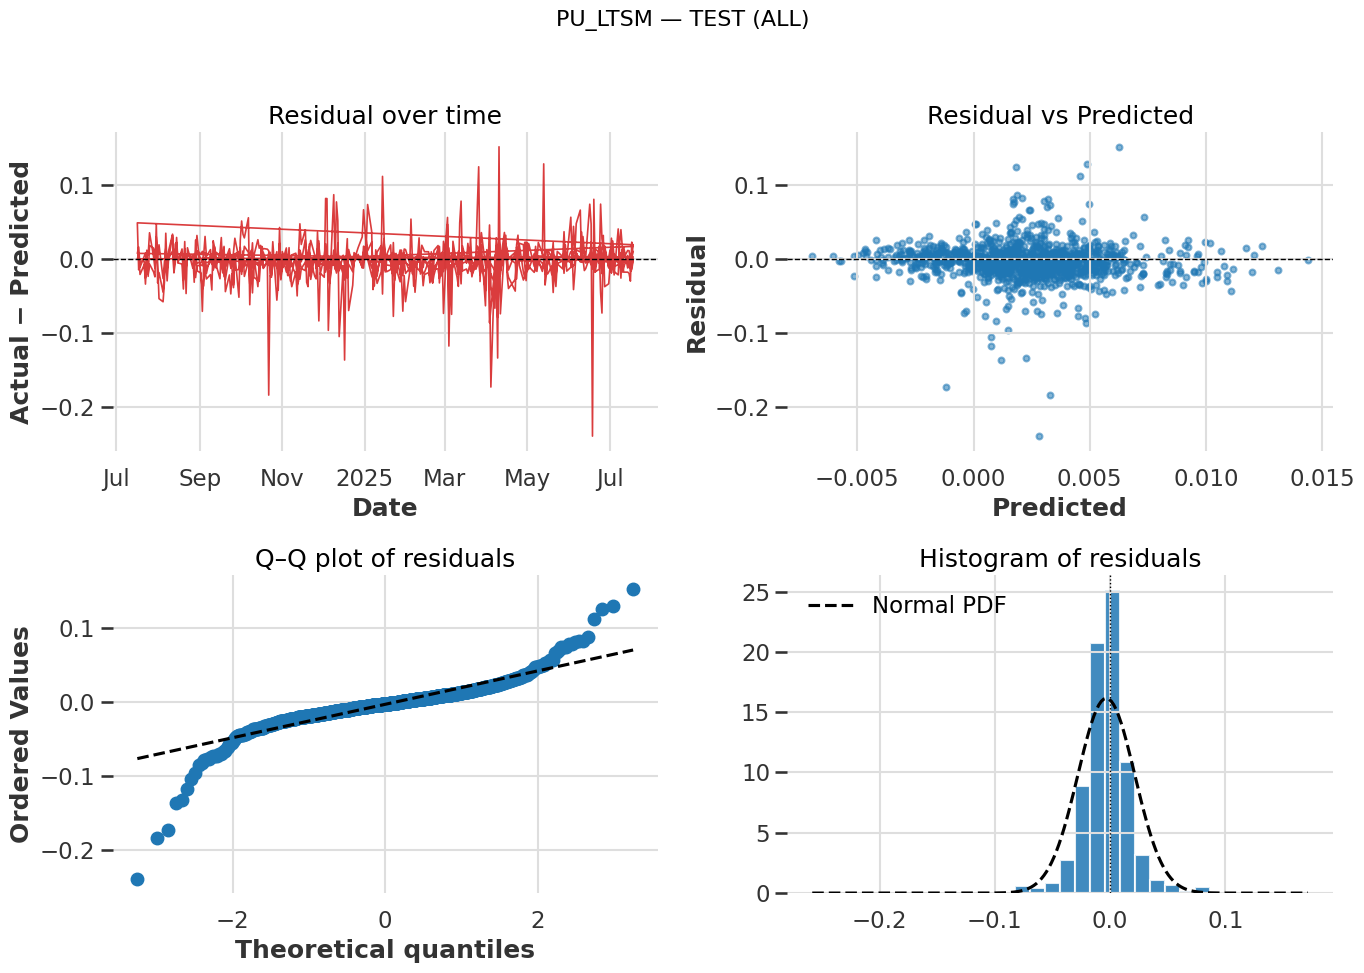


📊 Residual stats for PU_LTSM — TEST (ALL):
  Mean       : -0.003295
  Std dev    : 0.024700
  Skewness   : -1.063
  Kurtosis   : 15.816


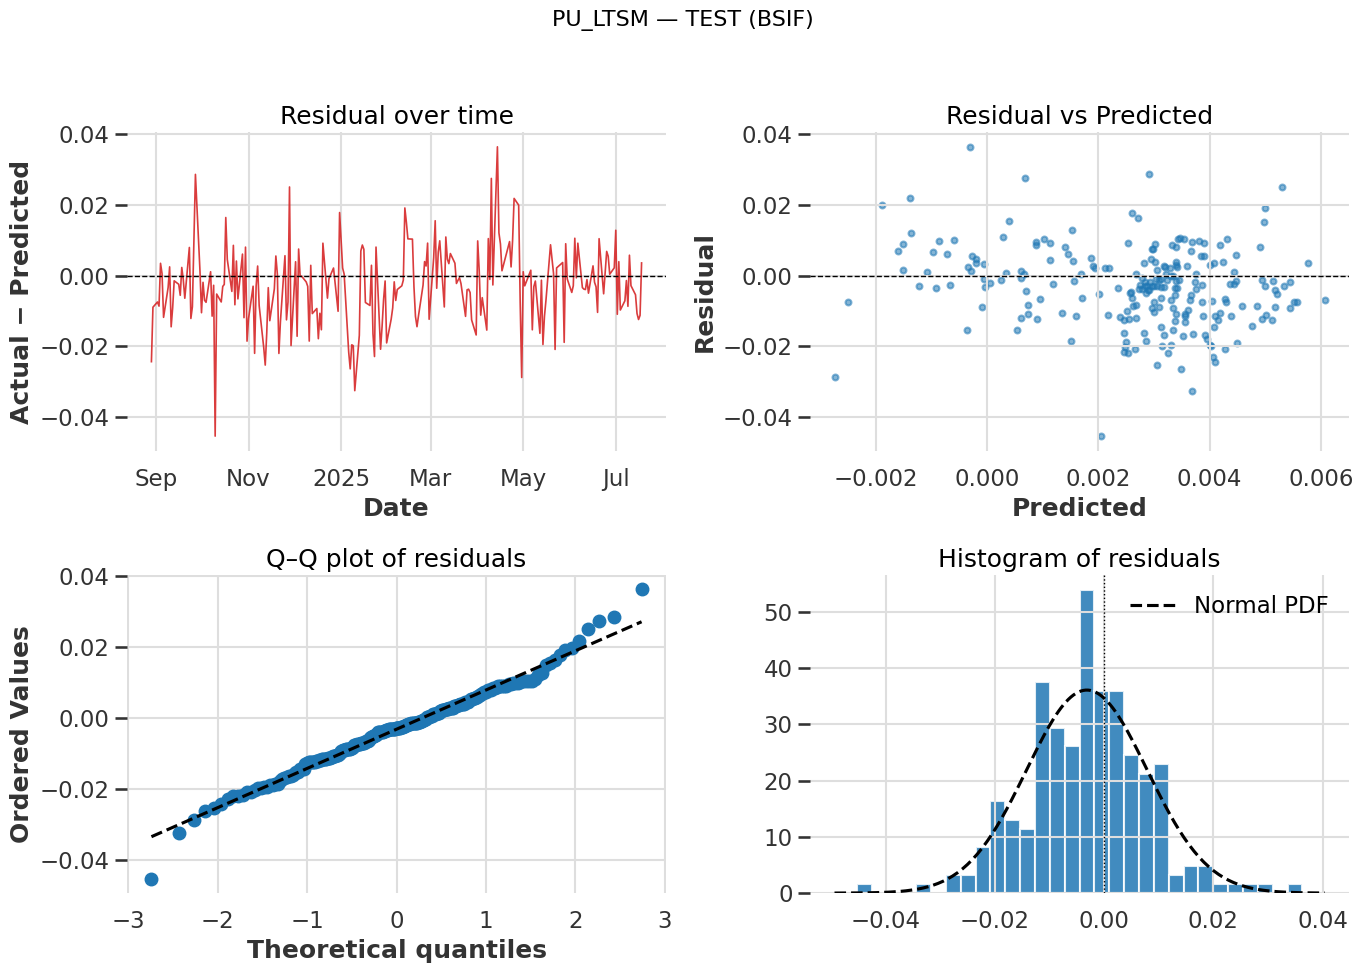


📊 Residual stats for PU_LTSM — TEST (BSIF):
  Mean       : -0.003154
  Std dev    : 0.011046
  Skewness   : 0.031
  Kurtosis   : 1.212


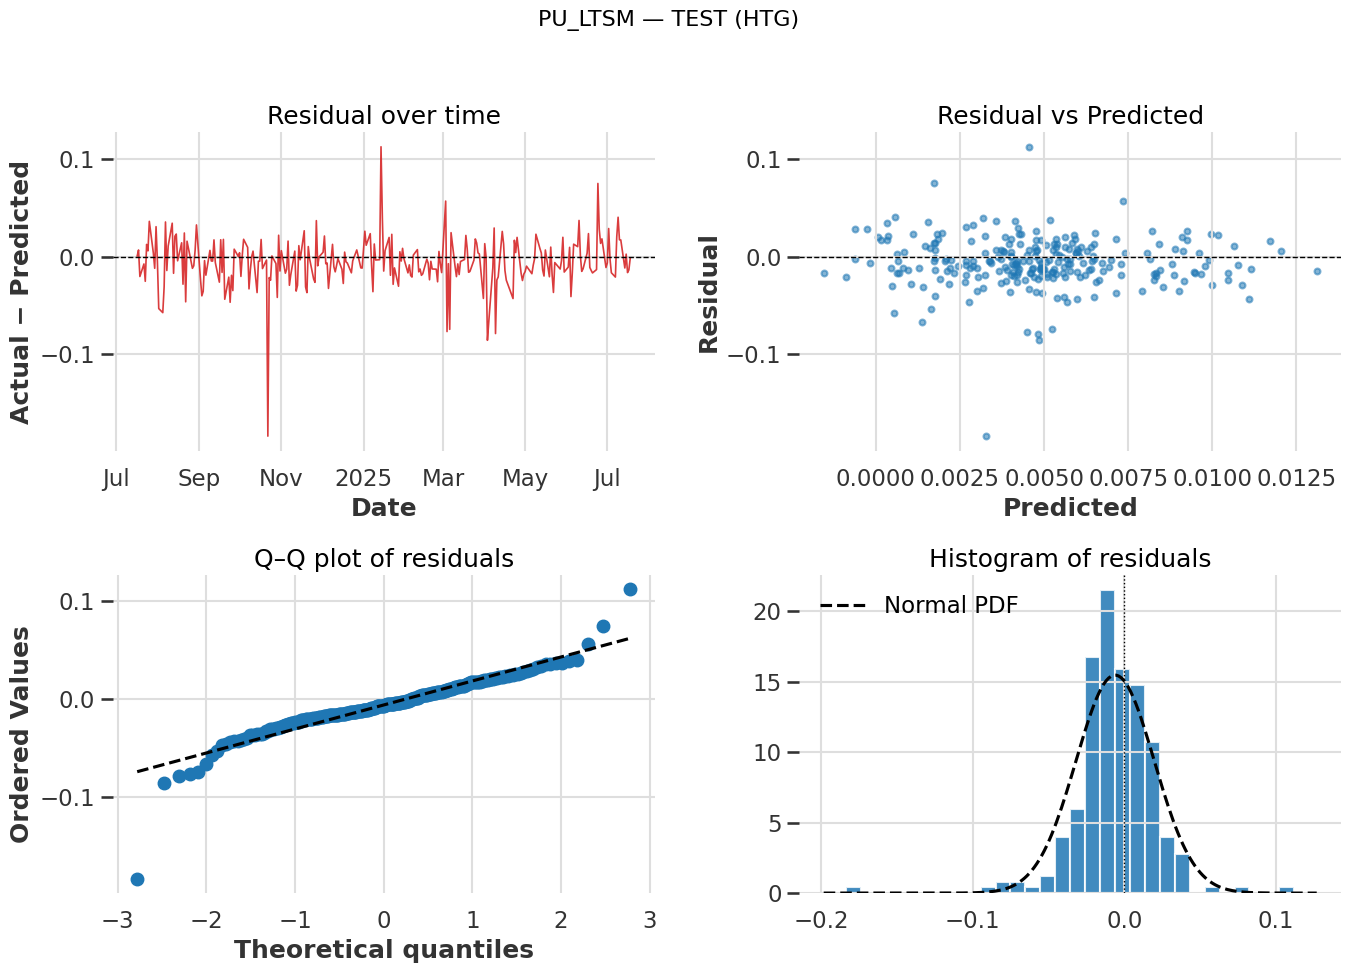


📊 Residual stats for PU_LTSM — TEST (HTG):
  Mean       : -0.006043
  Std dev    : 0.025811
  Skewness   : -1.040
  Kurtosis   : 9.906


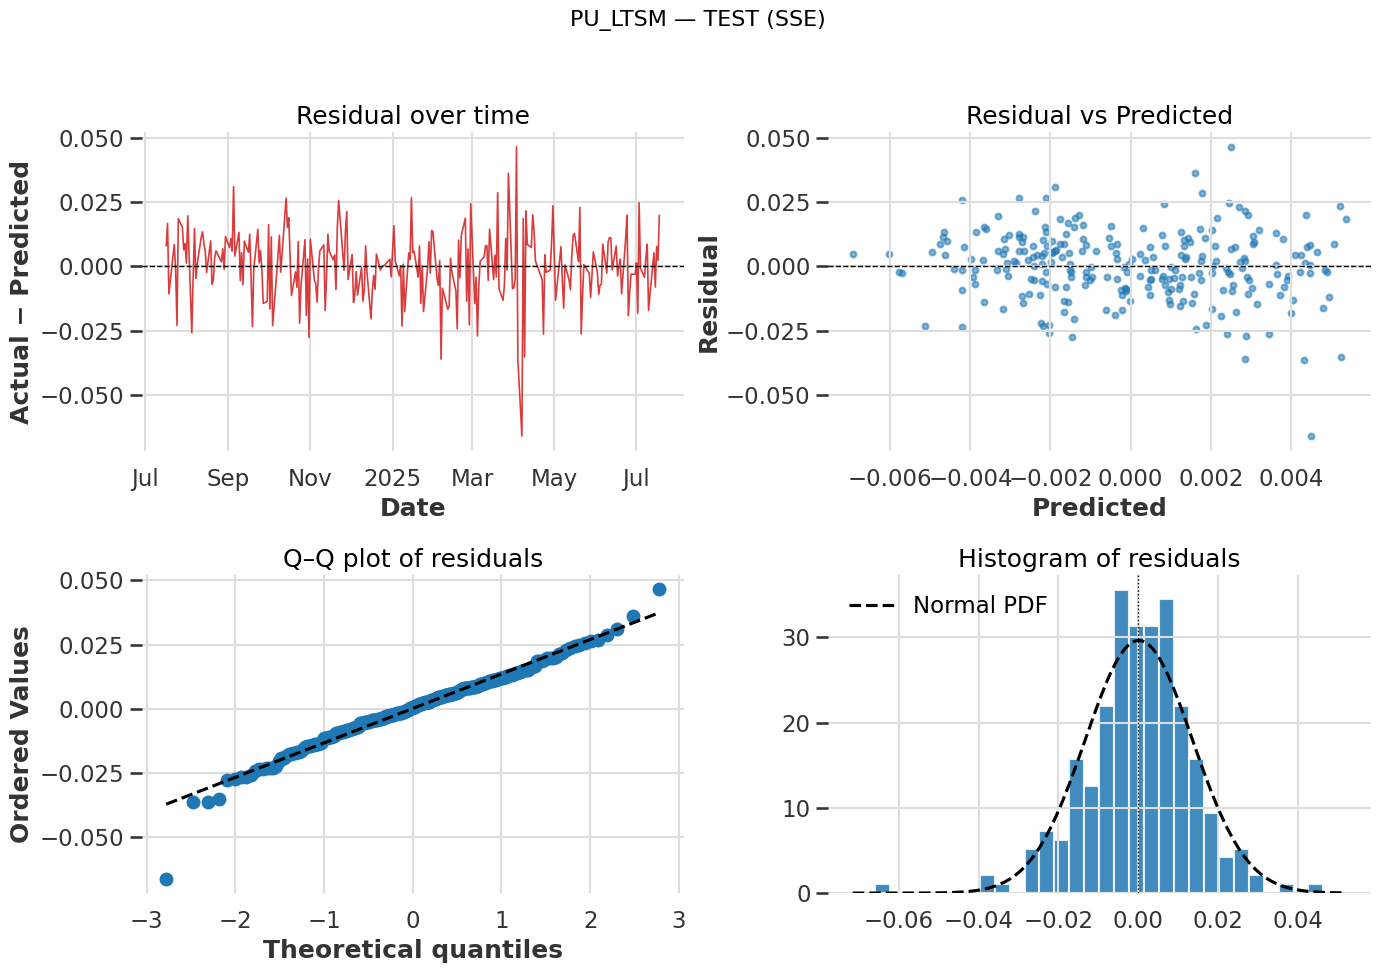


📊 Residual stats for PU_LTSM — TEST (SSE):
  Mean       : 0.000157
  Std dev    : 0.013460
  Skewness   : -0.442
  Kurtosis   : 2.250


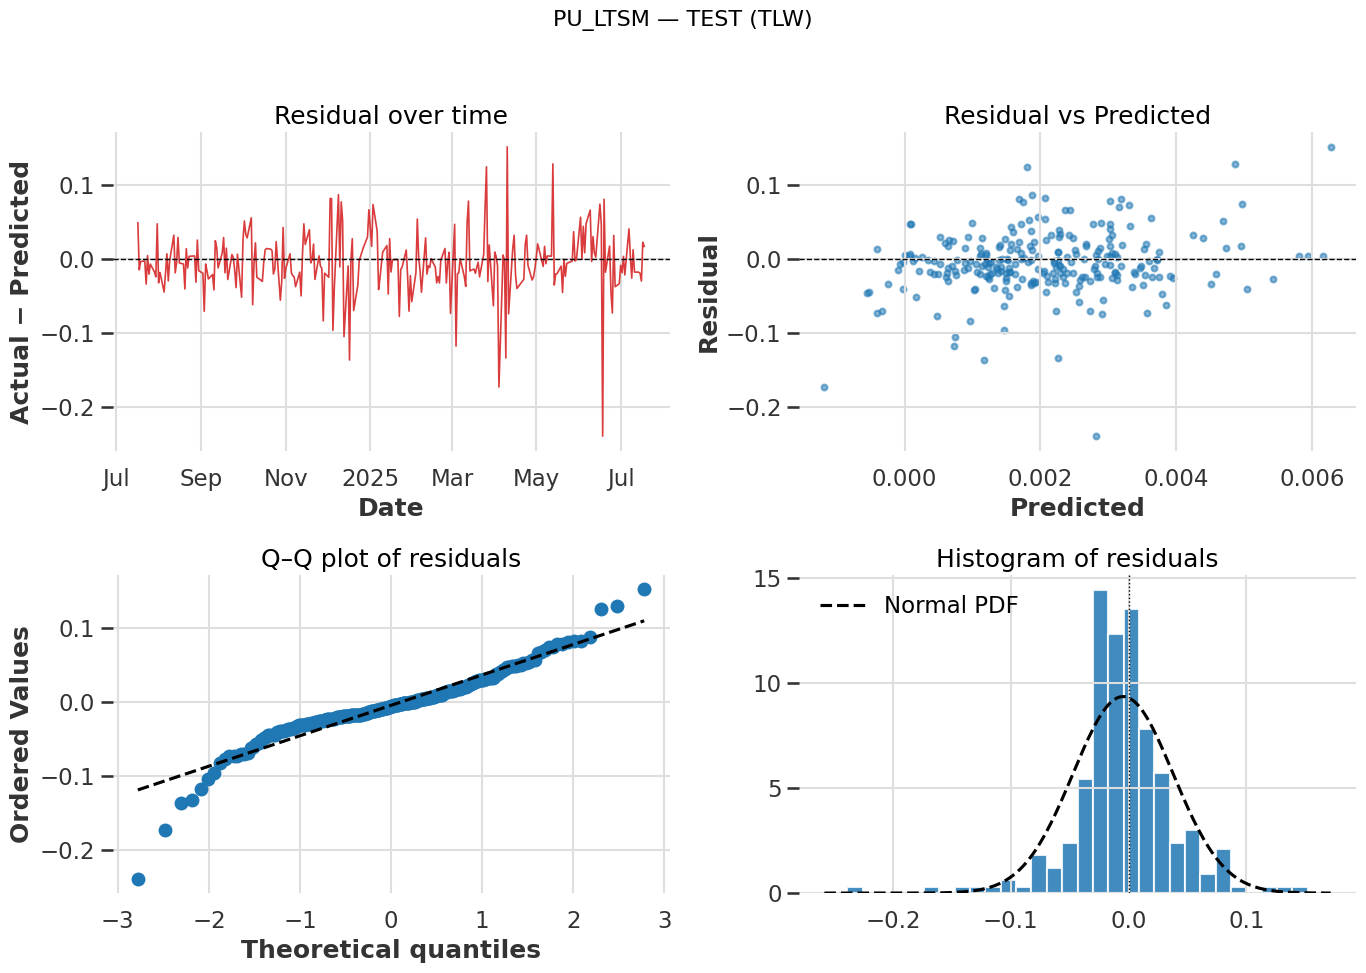


📊 Residual stats for PU_LTSM — TEST (TLW):
  Mean       : -0.004715
  Std dev    : 0.042606
  Skewness   : -0.596
  Kurtosis   : 5.150


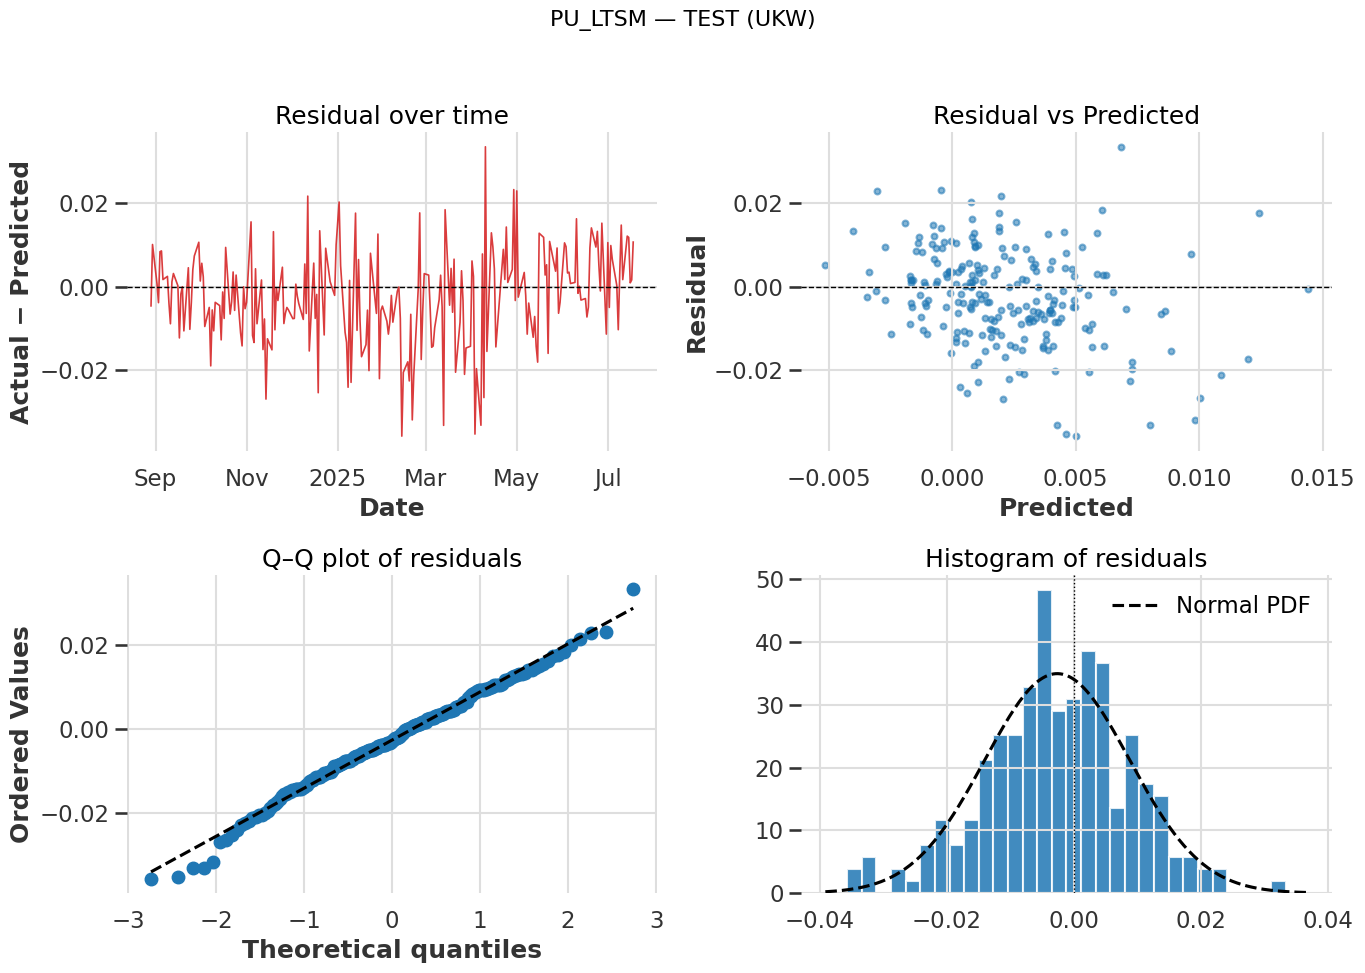


📊 Residual stats for PU_LTSM — TEST (UKW):
  Mean       : -0.002624
  Std dev    : 0.011402
  Skewness   : -0.216
  Kurtosis   : 0.398


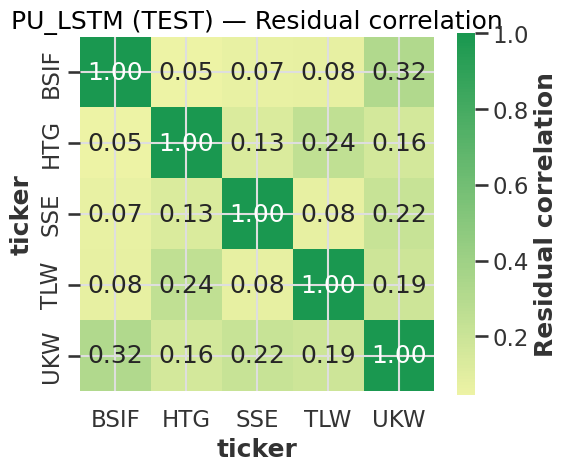

In [9]:
# =========================================
# 3) DIAGNOSTICS — Residual plots (overall + per-ticker) and heatmaps
# =========================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import scipy.stats as stats


BYG = sns.blend_palette(["#2166ac", "#f7f7a9", "#1a9850"], as_cmap=True)

SET = "test"   # "val" or "test"
PRED_PARQ = os.path.join("outputs", "pu_lstm", f"final_{SET}_predictions.parquet")
METRICS_CSV = os.path.join("outputs", "pu_lstm", f"final_{SET}_metrics_bmr_compare.csv")
FIG_DIR = os.path.join("outputs", "pu_lstm", f"diagnostics_{SET}")
os.makedirs(FIG_DIR, exist_ok=True)

TICKER_MAP = {0:"BSIF", 1:"HTG", 2:"SSE", 3:"TLW", 4:"UKW"}

RESAMPLE = None          # None / "W" / "M"
ZSCORE_FOR_HEATMAP = True

# ---------- load preds ----------
df = pd.read_parquet(PRED_PARQ).copy()
df["Date"] = pd.to_datetime(df["Date"])
df["ticker"] = df["ticker_id"].map(TICKER_MAP).astype("category")
df = df.sort_values(["ticker_id","Date"])
df["resid"] = df["y_true"] - df["y_pred"]

# ---------- plotting helper ----------
def plot_diagnostics_with_stats(actual, predicted, dates, title, save_path):
    errors = np.asarray(actual) - np.asarray(predicted)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=16)

    # 1) Residual over time (RED)
    ax = axes[0,0]
    ax.plot(pd.to_datetime(dates), errors, color="#d62728", alpha=0.9, linewidth=1.2)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title("Residual over time")
    ax.set_ylabel("Actual − Predicted")
    ax.set_xlabel("Date")
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=10))
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    for tick in ax.get_xticklabels(): tick.set_rotation(0)

    # 2) Residual vs Predicted (BLUE)
    axes[0,1].scatter(predicted, errors, alpha=0.55, s=18, color="#1f77b4")
    axes[0,1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0,1].set_title("Residual vs Predicted")
    axes[0,1].set_xlabel("Predicted")
    axes[0,1].set_ylabel("Residual")

    # 3) Q–Q plot
    stats.probplot(errors, dist="norm", plot=axes[1,0])
    for ln in axes[1,0].get_lines()[:-1]: ln.set_color("#1f77b4")
    axes[1,0].get_lines()[-1].set_color("black"); axes[1,0].get_lines()[-1].set_linestyle("--")
    axes[1,0].set_title("Q–Q plot of residuals")

    # 4) Histogram + PDF
    axes[1,1].hist(errors, bins=30, density=True, alpha=0.85, color="#1f77b4", edgecolor="white")
    xmin, xmax = axes[1,1].get_xlim()
    xs = np.linspace(xmin, xmax, 200)
    pdf = stats.norm.pdf(xs, np.nanmean(errors), np.nanstd(errors))
    axes[1,1].plot(xs, pdf, color="black", linestyle="--", label="Normal PDF")
    axes[1,1].axvline(0, color="black", linestyle=":", linewidth=1)
    axes[1,1].set_title("Histogram of residuals")
    axes[1,1].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(save_path, dpi=160)
    plt.show()

    # Inline residual stats
    print(f"\n📊 Residual stats for {title}:")
    print(f"  Mean       : {np.nanmean(errors):.6f}")
    print(f"  Std dev    : {np.nanstd(errors):.6f}")
    print(f"  Skewness   : {stats.skew(errors, nan_policy='omit'):.3f}")
    print(f"  Kurtosis   : {stats.kurtosis(errors, nan_policy='omit', fisher=True):.3f}")

# ---------- overall ----------
plot_diagnostics_with_stats(
    df["y_true"].values, df["y_pred"].values, df["Date"].values,
    title=f"PU_LTSM — {SET.upper()} (ALL)", save_path=os.path.join(FIG_DIR, f"pulstm_{SET}_overall.png")
)

# ---------- per-ticker ----------
for tid, g in df.groupby("ticker_id", sort=False):
    tic = TICKER_MAP.get(tid, str(tid))
    plot_diagnostics_with_stats(
        g["y_true"].values, g["y_pred"].values, g["Date"].values,
        title=f"PU_LTSM — {SET.upper()} ({tic})", save_path=os.path.join(FIG_DIR, f"pulstm_{SET}_{tic}.png")
    )

# ---------- residual correlation heatmap ----------
pivot = df.pivot_table(index="Date", columns="ticker", values="resid").sort_index()
corr = pivot.corr(min_periods=10)
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=BYG, center=0, square=True,
            cbar_kws={"label":"Residual correlation"})
plt.title(f"PU_LSTM ({SET.upper()}) — Residual correlation")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"pulstm_{SET}_resid_corr.png"), dpi=160)
plt.show()


## 4. Joint LSTM with Huber-Pinball loss

### 4.1 Optional tuning provenance


In [10]:
'''# =========================
# LSTM_HuPin TUNING (leak-free scaling)
# Huber + Pinball (quantile) combined loss
# - Inputs come from:  LSTM_best_Huber_Beta/df_LSTM_train.csv
# - Outputs saved under: LSTM_HuPin/
# - Selection: maximize micro-averaged F2 (downside) on VAL
#               with a precision floor (no leakage)
# =========================


# ----- Paths / constants -----
DATA_DIR = "LSTM_best_Huber_Beta"         # <-- input data location 
SAVE_DIR = os.path.join("outputs", "hupin")
CONFIG_DIR = "LSTM_HuPin"
os.makedirs(SAVE_DIR, exist_ok=True)

TRAIN_CSV     = os.path.join(DATA_DIR, "df_LSTM_train.csv")
TUNING_CSV    = os.path.join(SAVE_DIR, "LSTM_HuPin_tuning.csv")
BEST_CFG_JSON = os.path.join(CONFIG_DIR, "LSTM_HuPin_best_config.json")

# tune on subset to keep runs tractable (as before)
TUNE_IDS   = [0, 2]     # BSIF, SSE
N_TICKERS  = 5
ID_COL     = "ticker_id"
TARGET_COL = "log_return"
FLAGS = ["brexit_transition","covid_awareness","post_pandemic","war_ukraine","renewables"]
NUMERIC = [
    "EMA_30","RSI","MACD","YZ_vol","BrGBP_logchg",
    "MarketCap_GBP","OVX","GUK10Y","FTSE_lr"
]

# ---- HYPERPARAM GRIDS (including pinball) ----
GRID = {
    "lookback":      [30, 60, 90],
    "hidden_dim":    [32, 64],
    "n_rnn_layers":  [2],
    "dropout":       [0.0, 0.2],
    "huber_beta":    [0.05, 0.075, 0.1],
    "tau":           [0.01, 0.025, 0.05],            # lower quantile;
    "lambda_pin":    [0.5, 1.0, 2.0],              # weight on pinball;
}

VAL_FRACTION   = 0.10
MAX_EPOCHS     = 100
EARLY_PATIENCE = 12
LR             = 1e-3
BATCH          = 32
SEED           = 42

# ---- Selection rule knobs ----
PRECISION_FLOOR = 0.30   # require downside precision >= this on VAL
MAD_MULTIPLIER  = 2.0    # for robust train-only cutoff
Z_PSTAR         = 0.0228 # Phi(-2) fallback quantile
MIN_TRAIN_TAIL_EVENTS = 5

# ----- Load & prep -----
df = (pd.read_csv(TRAIN_CSV, parse_dates=["Date"])
        .set_index("Date").sort_index())

# OHE tickers
ohe_cols = [f"tic_{i}" for i in range(N_TICKERS)]
ohe = pd.get_dummies(df[ID_COL], prefix="tic")
for c in ohe_cols:
    if c not in ohe: ohe[c] = 0
ohe = ohe[ohe_cols].astype("int8")
df = pd.concat([df, ohe], axis=1)

NUMERIC = [c for c in NUMERIC if c in df.columns]
COV_COLS = NUMERIC + [c for c in FLAGS if c in df.columns] + ohe_cols
assert df[[TARGET_COL] + COV_COLS].isna().sum().sum() == 0, "NaNs remain."

# Cache raw arrays
Raw: Dict[int, Tuple[np.ndarray, np.ndarray, int, np.ndarray]] = {}
for tid, df_t in df.groupby(ID_COL):
    df_t = df_t.sort_index()
    y_vals = df_t[TARGET_COL].to_numpy(np.float32)
    X_vals = df_t[COV_COLS].to_numpy(np.float32)
    Raw[int(tid)] = (y_vals, X_vals, len(df_t), df_t.index.to_numpy())
NUM_IDX = [COV_COLS.index(c) for c in NUMERIC]

def embargo_split_idx(n: int, lookback: int, val_fraction: float) -> int:
    cut = int(np.floor((1 - val_fraction) * n))
    s = min(n - 1, cut + max(lookback, 5))
    return max(s, lookback)

def split_idx_for(tid: int, lb: int) -> int:
    _, _, n, _ = Raw[tid]
    return embargo_split_idx(n, lb, VAL_FRACTION)

def build_full_series_scaled(tids, lb):
    # fit scaler on TRAIN windows only (stack over tuning tickers)
    scaler = StandardScaler(with_mean=True, with_std=True)
    blocks = []
    s_idx = {}
    for tid in tids:
        y, X, _, _ = Raw[tid]
        s = split_idx_for(tid, lb); s_idx[tid] = s
        if NUM_IDX and s > 0:
            blocks.append(X[:s, NUM_IDX])
    scaler.fit(np.vstack(blocks))
    # transform full series once
    Y_ts, X_ts = {}, {}
    for tid in tids:
        y, X, _, _ = Raw[tid]
        Xs = X.copy()
        if NUM_IDX:
            Xs[:, NUM_IDX] = scaler.transform(Xs[:, NUM_IDX])
        Y_ts[tid] = TimeSeries.from_values(y.astype(np.float32))
        X_ts[tid] = TimeSeries.from_values(Xs.astype(np.float32))
    return Y_ts, X_ts, s_idx

# --- train-only robust cutoff per ticker ---
def train_tail_threshold(y_train: np.ndarray,
                         mad_mult: float = MAD_MULTIPLIER,
                         p_fallback: float = Z_PSTAR,
                         min_events: int = MIN_TRAIN_TAIL_EVENTS) -> float:
    med = float(np.median(y_train))
    mad = float(np.median(np.abs(y_train - med)))
    sigma_rob = 1.4826 * mad
    if np.isfinite(sigma_rob) and sigma_rob > 0.0:
        t_mad = med - mad_mult * sigma_rob
        if int((y_train <= t_mad).sum()) >= min_events:
            return float(t_mad)
    # fallback to train quantile if MAD too small or tail too sparse
    return float(np.quantile(y_train, p_fallback))

# --- metrics on VAL given predictions and thresholds ---
def downside_counts(a: np.ndarray, p: np.ndarray, t: float):
    a = np.asarray(a); p = np.asarray(p)
    actual_bear = a <= t
    pred_bear   = p <= t
    tp = int(np.sum(actual_bear & pred_bear))
    fp = int(np.sum(~actual_bear & pred_bear))
    fn = int(np.sum(actual_bear & ~pred_bear))
    nb = int(np.sum(actual_bear))
    return tp, fp, fn, nb

def prf2(tp: int, fp: int, fn: int):
    prec = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    rec  = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    if np.isnan(prec) or np.isnan(rec) or (4*prec + rec) == 0:
        f2 = np.nan
    else:
        f2 = (5 * prec * rec) / (4 * prec + rec)
    return prec, rec, f2

# --- Combined Huber + Pinball loss ---
class HuberPinballLoss(nn.Module):
    def __init__(self, beta: float, tau: float, lam: float):
        super().__init__()
        self.beta = float(beta)
        self.tau  = float(tau)
        self.lam  = float(lam)
        self.huber = nn.SmoothL1Loss(beta=self.beta, reduction="none")

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        # huber term
        h = self.huber(pred, target)              # elementwise
        # pinball term
        e = target - pred                         # residual
        pb = torch.where(e >= 0, self.tau * e, (self.tau - 1.0) * e)
        # combine (mean reduction)
        return h.mean() + self.lam * pb.mean()

# CSV header (keep RMSEs for reference; add tail metrics)
cols = [
    "lookback","hidden_dim","n_layers","dropout","huber_beta","tau","lambda_pin",
    "rmse_BSIF","rmse_SSE","rmse_mean",
    "prec_down_micro","rec_down_micro","f2_down_micro",
    "tp_micro","fp_micro","fn_micro","bear_micro",
    "secs"
]
if not os.path.exists(TUNING_CSV):
    pd.DataFrame(columns=cols).to_csv(TUNING_CSV, index=False)

best = {"score": -np.inf, "cfg": None, "aux": {}}
total = (len(GRID["lookback"])*len(GRID["hidden_dim"])*len(GRID["n_rnn_layers"])*
         len(GRID["dropout"])*len(GRID["huber_beta"])*len(GRID["tau"])*len(GRID["lambda_pin"]))
i = 0
print(f"Tuning {total} configs (BlockRNN + past_covariates + StandardScaler + Huber+Pinball)…")

for lb in GRID["lookback"]:
    # scale per-lookback (fit on TRAIN windows)
    Y_full, X_full, s_idx = build_full_series_scaled(TUNE_IDS, lb)

    # precompute train-only thresholds per ticker (leak-free)
    tail_thr: Dict[int, float] = {}
    for tid in TUNE_IDS:
        y_all, _, _, _ = Raw[tid]
        s = s_idx[tid]
        tcut = train_tail_threshold(y_all[:s])
        tail_thr[tid] = tcut

    for hd in GRID["hidden_dim"]:
        for nl in GRID["n_rnn_layers"]:
            for dr in GRID["dropout"]:
                for beta in GRID["huber_beta"]:
                    for tau in GRID["tau"]:
                        for lam in GRID["lambda_pin"]:
                            i += 1
                            t0 = time.time()
                            print(f"\n[{i}/{total}] lb={lb}, hd={hd}, L={nl}, dr={dr}, beta={beta}, tau={tau}, λ={lam}")

                            # build per-ticker train/val TimeSeries lists
                            S_TR, C_TR, S_VAL, C_VAL = [], [], [], []
                            for tid in TUNE_IDS:
                                s = s_idx[tid]
                                y_tr, y_val = Y_full[tid].split_before(s)
                                X_tr, X_val = X_full[tid].split_before(s)
                                S_TR.append(y_tr);  C_TR.append(X_tr)
                                S_VAL.append(y_val); C_VAL.append(X_val)

                            es = EarlyStopping(monitor="val_loss", patience=EARLY_PATIENCE, mode="min")
                            loss_fn = HuberPinballLoss(beta=float(beta), tau=float(tau), lam=float(lam))

                            model = BlockRNNModel(
                                model="LSTM",
                                input_chunk_length=lb,
                                output_chunk_length=1,
                                hidden_dim=hd,
                                n_rnn_layers=nl,
                                dropout=dr,
                                batch_size=BATCH,
                                n_epochs=MAX_EPOCHS,
                                optimizer_kwargs={"lr": LR},
                                random_state=SEED,
                                likelihood=None,
                                loss_fn=loss_fn,
                                pl_trainer_kwargs={
                                    "enable_progress_bar": True,
                                    "logger": False,
                                    "log_every_n_steps": 1,
                                    "accelerator": "cpu",
                                    "callbacks": [es],
                                    "enable_checkpointing": False,
                                },
                            )

                            try:
                                model.fit(series=S_TR, past_covariates=C_TR,
                                          val_series=S_VAL, val_past_covariates=C_VAL,
                                          verbose=True)

                                # Per-ticker VAL forecasts & metrics
                                rmse_vals = []; steps_vals = []
                                tp_micro = fp_micro = fn_micro = bear_micro = 0
                                for tid in TUNE_IDS:
                                    s = s_idx[tid]
                                    y_ts = Y_full[tid]; X_ts = X_full[tid]

                                    fc = model.historical_forecasts(
                                        series=y_ts, past_covariates=X_ts,
                                        start=y_ts.time_index[s], forecast_horizon=1, stride=1,
                                        retrain=False, last_points_only=True, verbose=False,
                                    )
                                    fc = fc.slice_intersect(y_ts)
                                    p = fc.values().squeeze()
                                    t = y_ts.slice_intersect(fc).values().squeeze()

                                    m = np.isfinite(p) & np.isfinite(t)
                                    steps = int(m.sum())
                                    steps_vals.append(steps)
                                    if steps > 0:
                                        rmse_vals.append(float(np.sqrt(np.mean((t[m]-p[m])**2))))
                                        # downside counts at train-fixed threshold
                                        tp, fp, fn, nb = downside_counts(t[m], p[m], tail_thr[tid])
                                        tp_micro += tp; fp_micro += fp; fn_micro += fn; bear_micro += nb
                                    else:
                                        rmse_vals.append(np.nan)

                                r_bsif, r_sse = rmse_vals
                                r_mean = float(np.nanmean(rmse_vals))
                                prec_micro, rec_micro, f2_micro = prf2(tp_micro, fp_micro, fn_micro)
                                secs = round(time.time() - t0, 1)

                                print(f"→ RMSE mean={r_mean:.6f} | "
                                      f"F2↓={f2_micro if not np.isnan(f2_micro) else float('nan'):.4f} "
                                      f"(Prec↓={prec_micro if not np.isnan(prec_micro) else float('nan'):.3f}, "
                                      f"Rec↓={rec_micro if not np.isnan(rec_micro) else float('nan'):.3f}) | "
                                      f"steps={sum(steps_vals)} in {secs}s")

                                row = pd.DataFrame([{
                                    "lookback": lb, "hidden_dim": hd, "n_layers": nl, "dropout": dr,
                                    "huber_beta": float(beta), "tau": float(tau), "lambda_pin": float(lam),
                                    "rmse_BSIF": r_bsif, "rmse_SSE": r_sse, "rmse_mean": r_mean,
                                    "prec_down_micro": prec_micro, "rec_down_micro": rec_micro, "f2_down_micro": f2_micro,
                                    "tp_micro": tp_micro, "fp_micro": fp_micro, "fn_micro": fn_micro, "bear_micro": bear_micro,
                                    "secs": secs
                                }])
                                with open(TUNING_CSV, "a", newline="") as f:
                                    row.to_csv(f, header=False, index=False)

                                # ---- Selection: maximize F2 (with precision floor); tie-break by higher recall, then lower RMSE ----
                                valid = (not np.isnan(prec_micro)) and (prec_micro >= PRECISION_FLOOR) and (not np.isnan(f2_micro))
                                if valid:
                                    score = f2_micro
                                    better = (score > best["score"])
                                    if (score == best["score"]) and best["cfg"] is not None:
                                        # tie-breakers
                                        prev_rec = best["aux"].get("rec_down_micro", -1.0)
                                        if rec_micro > prev_rec:
                                            better = True
                                        elif rec_micro == prev_rec and r_mean < best["aux"].get("rmse_mean", np.inf):
                                            better = True
                                    if better:
                                        best = {
                                            "score": score,
                                            "cfg": {
                                                "lookback": lb, "hidden_dim": hd, "n_layers": nl, "dropout": dr,
                                                "huber_beta": float(beta), "tau": float(tau), "lambda_pin": float(lam),
                                            },
                                            "aux": {
                                                "rmse_mean": r_mean,
                                                "prec_down_micro": prec_micro,
                                                "rec_down_micro": rec_micro,
                                                "f2_down_micro": f2_micro,
                                                "bear_micro": bear_micro,
                                                "steps_total": int(sum(steps_vals)),
                                            }
                                        }
                                        with open(BEST_CFG_JSON, "w") as fp:
                                            json.dump({
                                                "best_config": best["cfg"],
                                                "selection_metrics": best["aux"],
                                                "selection_rule": {
                                                    "objective": "maximize F2_down_micro",
                                                    "precision_floor": PRECISION_FLOOR,
                                                    "tie_breakers": ["higher recall", "lower rmse_mean"],
                                                    "tail_threshold": "train-only median-MAD with quantile fallback",
                                                    "fallback_quantile": Z_PSTAR,
                                                    "mad_multiplier": MAD_MULTIPLIER
                                                },
                                                "tune_tickers": ["BSIF","SSE"]
                                            }, fp, indent=2)

                            except Exception as e:
                                secs = round(time.time() - t0, 1)
                                print(f"FAIL lb={lb}, hd={hd}, L={nl}, dr={dr}, beta={beta}, tau={tau}, λ={lam}: {e}")
                                row = pd.DataFrame([{
                                    "lookback": lb, "hidden_dim": hd, "n_layers": nl, "dropout": dr,
                                    "huber_beta": float(beta), "tau": float(tau), "lambda_pin": float(lam),
                                    "rmse_BSIF": np.nan, "rmse_SSE": np.nan, "rmse_mean": np.nan,
                                    "prec_down_micro": np.nan, "rec_down_micro": np.nan, "f2_down_micro": np.nan,
                                    "tp_micro": 0, "fp_micro": 0, "fn_micro": 0, "bear_micro": 0,
                                    "secs": secs
                                }])
                                with open(TUNING_CSV, "a", newline="") as f:
                                    row.to_csv(f, header=False, index=False)

print("\nBest (by F2_down_micro with precision floor):")
print(json.dumps({"best_config": best["cfg"], "selection_metrics": best["aux"]}, indent=2))
'''

'# =========================\n# LSTM_HuPin TUNING (leak-free scaling)\n# Huber + Pinball (quantile) combined loss\n# - Inputs come from:  LSTM_best_Huber_Beta/df_LSTM_train.csv\n# - Outputs saved under: LSTM_HuPin/\n# - Selection: maximize micro-averaged F2 (downside) on VAL\n#               with a precision floor (no leakage)\n# =========================\n\n\n# ----- Paths / constants -----\nDATA_DIR = "LSTM_best_Huber_Beta"         # <-- input data location \nSAVE_DIR = os.path.join("outputs", "hupin")\nCONFIG_DIR = "LSTM_HuPin"\nos.makedirs(SAVE_DIR, exist_ok=True)\n\nTRAIN_CSV     = os.path.join(DATA_DIR, "df_LSTM_train.csv")\nTUNING_CSV    = os.path.join(SAVE_DIR, "LSTM_HuPin_tuning.csv")\nBEST_CFG_JSON = os.path.join(CONFIG_DIR, "LSTM_HuPin_best_config.json")\n\n# tune on subset to keep runs tractable (as before)\nTUNE_IDS   = [0, 2]     # BSIF, SSE\nN_TICKERS  = 5\nID_COL     = "ticker_id"\nTARGET_COL = "log_return"\nFLAGS = ["brexit_transition","covid_awareness","post_pandemic"

### 4.2 Final training and evaluation


In [11]:
# =========================
# FINAL LSTM_HuPin (BlockRNN + past_covariates, leak-free scaling)
# Huber + Pinball combined loss (train best config) + metrics:
#   RMSE, R², BearMissRate (std), BearMissRate_tol (directional),
#   BearMissRate_z (+ z-miss, z-bears, z-threshold)
# =========================

import os, json
from pathlib import Path
from typing import Tuple, Dict

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_squared_error, r2_score
from darts import TimeSeries
from src.models import HuberPinballLoss, build_submitted_lstm

# -------- paths / constants --------
DATA_DIR = "LSTM_best_Huber_Beta"   # <-- inputs (your prepared split)
CONFIG_DIR = "LSTM_HuPin"
SAVE_DIR = os.path.join("outputs", "hupin")
os.makedirs(SAVE_DIR, exist_ok=True)

TRAIN_CSV = os.path.join(DATA_DIR, "df_LSTM_train.csv")
TEST_CSV  = os.path.join(DATA_DIR, "df_LSTM_test.csv")
BEST_CFG_JSON = os.path.join(CONFIG_DIR, "LSTM_HuPin_best_config.json")

FINAL_MODEL_PATH  = os.path.join(SAVE_DIR, "best_lstm_hupin_blockrnn_scaled.darts")
FINAL_STATE_DICT  = os.path.join(SAVE_DIR, "best_lstm_hupin_blockrnn_scaled_state_dict.pt")

VAL_PRED_CSV   = os.path.join(SAVE_DIR, "final_val_predictions.csv")
VAL_PRED_PARQ  = os.path.join(SAVE_DIR, "final_val_predictions.parquet")
VAL_METRICS_CSV= os.path.join(SAVE_DIR, "final_val_metrics.csv")

TEST_PRED_CSV  = os.path.join(SAVE_DIR, "final_test_predictions.csv")
TEST_PRED_PARQ = os.path.join(SAVE_DIR, "final_test_predictions.parquet")
TEST_METRICS_CSV= os.path.join(SAVE_DIR, "final_test_metrics.csv")

ROOT_METRICS_LOG = Path("outputs") / "model_metrics.csv"

ID_COL, TARGET_COL, N_TICKERS = "ticker_id", "log_return", 5
FLAGS  = ["brexit_transition","covid_awareness","post_pandemic","war_ukraine","renewables"]
NUMERIC = [
    "EMA_30","RSI","MACD","YZ_vol","BrGBP_logchg",
    "MarketCap_GBP","OVX","GUK10Y","FTSE_lr"
]

VAL_FRACTION   = 0.10
MAX_EPOCHS     = 100
EARLY_PATIENCE = 15
LR, BATCH, SEED = 1e-3, 32, 42
EPS_SIGN = 0.0  # (unused here)

# Bear Miss Rate tolerance knobs (derived from VAL, applied to both VAL/TEST)
K_ERR = 1.0   # eps_err = K_ERR * RMSE_val_per_ticker
K_NEG = 0.0   # kept for compatibility; not used in the corrected BMR

# z-BMR robust cutoff controls
MAD_MULTIPLIER = 2.0
Z_PSTAR = 0.0228  # ≈ Phi(-2)
MIN_TRAIN_TAIL_EVENTS = 5  # fallback to quantile if train tail too sparse

# -------- helpers --------
rmse = submitted_rmse

# --- BMRs ---
bear_miss_rate_standard = submitted_bmr

bear_miss_rate_tolerant_directional = submitted_bmr_tolerant

# --- z-BMR helper (missed robust ≤ -2σ events). Return NaN if no events. ---
z_bear_miss_rate = submitted_bmr_z

# --- train-only robust per-ticker cutoff t = median - 2 * 1.4826 * MAD with quantile fallback ---
def train_tail_threshold(y_train: np.ndarray,
                         mad_mult: float = MAD_MULTIPLIER,
                         p_fallback: float = Z_PSTAR,
                         min_events: int = MIN_TRAIN_TAIL_EVENTS) -> float:
    return submitted_robust_bmr_z_threshold(
        y_train,
        mad_multiplier=mad_mult,
        fallback_quantile=p_fallback,
        min_tail_events=min_events,
    )

# -------- load best cfg --------
with open(BEST_CFG_JSON, "r") as fp:
    best = json.load(fp)["best_config"]
lb, hd, nl, dr = best["lookback"], best["hidden_dim"], best["n_layers"], best["dropout"]
beta = float(best.get("huber_beta", 0.05))
tau  = float(best.get("tau", 0.025))
lam  = float(best.get("lambda_pin", 1.0))

model_name = f"BlockRNN-LSTM(past,scaled,HuPin:beta={beta:g},tau={tau:g},lam={lam:g})-lb{lb}-h{hd}-l{nl}-dr{dr}"
print("Best config (HuPin):", best)

# -------- TRAIN build (raw) --------
df_tr = pd.read_csv(TRAIN_CSV, parse_dates=["Date"]).set_index("Date").sort_index()
df_tr, ohe_cols = build_ohe(df_tr)
NUMERIC = [c for c in NUMERIC if c in df_tr.columns]
COV_COLS = NUMERIC + [c for c in FLAGS if c in df_tr.columns] + ohe_cols
assert df_tr[[TARGET_COL] + COV_COLS].isna().sum().sum() == 0, "NaNs in TRAIN."

# raw arrays per ticker + split idx
Raw: Dict[int, Tuple[np.ndarray, np.ndarray, int, np.ndarray]] = {}
split_idx: Dict[int, int] = {}
for tid, df_t in df_tr.groupby(ID_COL):
    df_t = df_t.sort_index()
    y = df_t[TARGET_COL].to_numpy(np.float32)
    X = df_t[COV_COLS].to_numpy(np.float32)
    n = len(df_t)
    s = embargo_split_idx(n, lb, VAL_FRACTION)
    Raw[int(tid)] = (y, X, n, df_t.index.to_numpy())
    split_idx[int(tid)] = s

# ---- train-only robust per-ticker cutoff map ----
z_thresh_map: Dict[int, float] = {}
for tid in sorted(Raw.keys()):
    y, _, _, _ = Raw[tid]
    s = split_idx[tid]
    y_tr = y[:s]
    if len(y_tr) == 0:
        continue
    z_thresh_map[int(tid)] = train_tail_threshold(y_tr)

# -------- fit StandardScaler on TRAIN windows only (all tickers) --------
num_idx = [COV_COLS.index(c) for c in NUMERIC]
scaler = fit_pooled_prefix_standard_scaler(Raw, split_idx, num_idx)

# transform FULL series (train+val) once
Y_full_ts: Dict[int, TimeSeries] = {}
X_full_ts: Dict[int, TimeSeries] = {}
dates_by_tid: Dict[int, np.ndarray] = {}
for tid in sorted(Raw.keys()):
    y, X, _, dts = Raw[tid]
    Xs = X.copy()
    if len(num_idx) > 0:
        Xs[:, num_idx] = scaler.transform(Xs[:, num_idx])
    Y_full_ts[tid] = TimeSeries.from_values(y.astype(np.float32))
    X_full_ts[tid] = TimeSeries.from_values(Xs.astype(np.float32))
    dates_by_tid[tid] = dts

# -------- model --------
loss_fn = HuberPinballLoss(beta=beta, tau=tau, lam=lam)
model = build_submitted_lstm(
    lookback=lb, hidden_dim=hd, n_rnn_layers=nl, dropout=dr,
    batch_size=BATCH, n_epochs=MAX_EPOCHS, learning_rate=LR,
    random_state=SEED, loss_fn=loss_fn,
    early_patience=EARLY_PATIENCE, early_min_delta=1e-6,
)

# -------- fit (scaled past_covariates) --------
S_TR, C_TR, S_VAL, C_VAL = [], [], [], []
for tid in sorted(Y_full_ts.keys()):
    s = split_idx[tid]
    y_ts = Y_full_ts[tid]; X_ts = X_full_ts[tid]
    y_tr, y_val = y_ts.split_before(s); X_tr, X_val = X_ts.split_before(s)
    S_TR.append(y_tr); C_TR.append(X_tr)
    S_VAL.append(y_val); C_VAL.append(X_val)

print("Training final model (BlockRNN + leak-free StandardScaler + Huber+Pinball)…")
model.fit(series=S_TR, past_covariates=C_TR,
          val_series=S_VAL, val_past_covariates=C_VAL,
          verbose=True)

# save model + state dict
model.save(FINAL_MODEL_PATH)
try:
    torch.save(model.model.state_dict(), FINAL_STATE_DICT)
except Exception as e:
    with open(os.path.join(SAVE_DIR, "best_lstm_hupin_blockrnn_scaled_state_dict.err.txt"), "w") as f:
        f.write(str(e))

# -------- VAL predictions (dates) --------
rows_val = []
for tid in sorted(Y_full_ts.keys()):
    y_ts, X_ts = Y_full_ts[tid], X_full_ts[tid]
    s = split_idx[tid]
    fc = model.historical_forecasts(
        series=y_ts, past_covariates=X_ts,
        start=y_ts.time_index[s], forecast_horizon=1, stride=1,
        retrain=False, last_points_only=True, verbose=False,
    )
    fc = fc.slice_intersect(y_ts)
    pred = fc.values().squeeze()
    true = y_ts.slice_intersect(fc).values().squeeze()
    idxs = fc.time_index.values
    dts = dates_by_tid[tid][idxs]
    for d, p, t in zip(dts, pred, true):
        rows_val.append({"ticker_id": int(tid), "Date": pd.Timestamp(d), "y_true": float(t), "y_pred": float(p), "resid": float(t - p)})

val_df = pd.DataFrame(rows_val).sort_values(["ticker_id","Date"])
val_df.to_csv(VAL_PRED_CSV, index=False)
val_df.to_parquet(VAL_PRED_PARQ, index=False)

# ---- Build VAL-derived tolerance maps (per ticker) ----
def _rmse_series(g: pd.DataFrame) -> float:
    return rmse(g["y_true"].to_numpy(), g["y_pred"].to_numpy())

rmse_val_by_tid = (val_df.groupby("ticker_id").apply(_rmse_series).to_dict())
eps_err_map = {tid: float(K_ERR * r) for tid, r in rmse_val_by_tid.items()}
eps_neg_map = {tid: float(K_NEG * r) for tid, r in rmse_val_by_tid.items()}  # kept for compatibility (unused)
# overall thresholds from VAL
rmse_val_all = rmse(val_df["y_true"].to_numpy(), val_df["y_pred"].to_numpy())
eps_err_map["ALL"] = float(K_ERR * rmse_val_all)
eps_neg_map["ALL"] = float(K_NEG * rmse_val_all)

# -------- summarize (z-BMR counts pooled; tolerant is directional) --------
def summarize_with_bmr(df_preds: pd.DataFrame, label: str, out_csv: str,
                       eps_err_map: dict, eps_neg_map: dict, eps_sign: float = 0.0,
                       z_thresh_map: dict = None):
    rows = []
    miss_total = 0
    bear_total = 0

    for tid, g in df_preds.groupby("ticker_id"):
        a = g.y_true.values; p = g.y_pred.values
        r   = rmse(a, p)
        r2  = submitted_r_squared(a, p)

        e_err = float(eps_err_map.get(tid, r))

        # BMRs (corrected)
        bmr   = bear_miss_rate_standard(a, p)
        bmr_t = bear_miss_rate_tolerant_directional(a, p, e_err)

        row = {
            "ticker_id": int(tid),
            "RMSE": r,
            "R²": r2,
            "BearMissRate": bmr,
            "BearMissRate_tol": bmr_t,
            "N": len(g)
        }

        # z-BMR per ticker (using train-only threshold)
        if z_thresh_map is not None and tid in z_thresh_map:
            t = float(z_thresh_map[tid])
            z_frac, z_miss, z_bears = z_bear_miss_rate(a, p, t)
            row["BearMissRate_z"] = z_frac
            row["z-miss"] = int(z_miss)
            row["z-bears"] = int(z_bears)
            row["z-threshold"] = t

            if z_bears > 0:
                miss_total += z_miss
                bear_total += z_bears

        rows.append(row)

    # overall row
    a_all, p_all = df_preds.y_true.values, df_preds.y_pred.values
    r_all   = rmse(a_all, p_all)
    r2_all  = submitted_r_squared(a_all, p_all)
    e_err_all = float(eps_err_map.get("ALL", r_all))

    bear_all = (a_all < 0)
    denom_all = int(bear_all.sum())
    if denom_all == 0:
        bmr_all = 0.0
        bmr_t_all = 0.0
    else:
        bmr_all   = submitted_bmr(a_all, p_all)
        bmr_t_all = submitted_bmr_tolerant(a_all, p_all, e_err_all)

    overall = {
        "ticker_id": "ALL",
        "RMSE": r_all, "R²": r2_all,
        "BearMissRate": bmr_all,
        "BearMissRate_tol": bmr_t_all,
        "N": len(df_preds)
    }

    if z_thresh_map is not None:
        overall["BearMissRate_z"], _, _ = submitted_pooled_bmr_z([(miss_total, bear_total)])
        overall["z-miss"] = int(miss_total)
        overall["z-bears"] = int(bear_total)
        overall["z-threshold"] = float('nan')

    mdf = pd.DataFrame(rows + [overall])
    mdf.to_csv(out_csv, index=False)
    print(f"\n{label} metrics (BMR_tol uses VAL-derived RMSE as directional margin).")
    print(mdf.to_string(index=False))
    return mdf

# ---- summarize VAL with BMRs + z-bmr (train-only thresholds) ----
_ = summarize_with_bmr(val_df, "Validation", VAL_METRICS_CSV,
                       eps_err_map=eps_err_map, eps_neg_map=eps_neg_map, eps_sign=EPS_SIGN,
                       z_thresh_map=z_thresh_map)

# -------- TEST build (apply SAME scaler; no refit) --------
df_te = pd.read_csv(TEST_CSV, parse_dates=["Date"]).set_index("Date").sort_index()
df_te, ohe_cols_te = build_ohe(df_te)
NUMERIC_TE = [c for c in NUMERIC if c in df_te.columns]
COV_COLS_TE = NUMERIC_TE + [c for c in FLAGS if c in df_te.columns] + ohe_cols_te
assert df_te[[TARGET_COL] + COV_COLS_TE].isna().sum().sum() == 0, "NaNs in TEST."

rows_test = []
for tid, df_t in df_te.groupby(ID_COL):
    df_t = df_t.sort_index()
    dates = df_t.index.to_numpy()
    y_vals = df_t[TARGET_COL].to_numpy(np.float32)
    X_vals = df_t[COV_COLS_TE].to_numpy(np.float32)
    # scale numeric cols with the TRAIN-window scaler
    num_idx_te = [COV_COLS_TE.index(c) for c in NUMERIC_TE]
    if len(num_idx_te) > 0:
        X_vals_scaled = X_vals.copy()
        X_vals_scaled[:, num_idx_te] = scaler.transform(X_vals[:, num_idx_te])
    else:
        X_vals_scaled = X_vals

    y_ts = TimeSeries.from_values(y_vals)
    X_ts = TimeSeries.from_values(X_vals_scaled.astype(np.float32))

    if len(y_ts) <= lb:
        continue

    fc = model.historical_forecasts(
        series=y_ts, past_covariates=X_ts,
        start=y_ts.time_index[lb], forecast_horizon=1, stride=1,
        retrain=False, last_points_only=True, verbose=False,
    )
    fc = fc.slice_intersect(y_ts)
    pred = fc.values().squeeze()
    true = y_ts.slice_intersect(fc).values().squeeze()
    idxs = fc.time_index.values
    dts = dates[idxs]
    for d, p, t in zip(dts, pred, true):
        rows_test.append({"ticker_id": int(tid), "Date": pd.Timestamp(d), "y_true": float(t), "y_pred": float(p), "resid": float(t - p)})

test_df = pd.DataFrame(rows_test).sort_values(["ticker_id","Date"])
test_df.to_csv(TEST_PRED_CSV, index=False)
test_df.to_parquet(TEST_PRED_PARQ, index=False)

# ---- summarize TEST with BMRs + z-bmr (using same train-fixed thresholds) ----
test_metrics = summarize_with_bmr(test_df, "Test", TEST_METRICS_CSV,
                                  eps_err_map=eps_err_map, eps_neg_map=eps_neg_map, eps_sign=EPS_SIGN,
                                  z_thresh_map=z_thresh_map)

# -------- append TEST metrics to global log (updated schema) --------
rows = []
for _, r in test_metrics.iterrows():
    rows.append({
        "Model": model_name,
        "Ticker": r["ticker_id"],
        "RMSE": round(float(r["RMSE"]), 8),
        "R²": round(float(r["R²"]), 5),
        "BearMissRate": round(float(r["BearMissRate"]), 5),
        "BearMissRate_tol": round(float(r["BearMissRate_tol"]), 5),
        "BearMissRate_z": round(float(r.get("BearMissRate_z", np.nan)), 5) if pd.notna(r.get("BearMissRate_z", np.nan)) else np.nan,
    })
rows_df = pd.DataFrame(rows)
if ROOT_METRICS_LOG.exists():
    rows_df.to_csv(ROOT_METRICS_LOG, mode="a", header=False, index=False)
else:
    rows_df.to_csv(ROOT_METRICS_LOG, index=False)

print("\nDone. Saved:")
print(f"- Model: {FINAL_MODEL_PATH}")
print(f"- Val preds: {VAL_PRED_CSV} / {VAL_PRED_PARQ} (metrics: {VAL_METRICS_CSV})")
print(f"- Test preds: {TEST_PRED_CSV} / {TEST_PRED_PARQ} (metrics: {TEST_METRICS_CSV})")
print(f"- Appended TEST metrics to: {ROOT_METRICS_LOG.resolve()}")


GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
<VENV>\Lib\site-packages\pytorch_lightning\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | HuberPinballLoss | 0      | train
1 | train_criterion | HuberPinballLoss | 0      | train
2 | val_criterion   | HuberPinballLoss | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 55.0 K | train
6 | fc              | Sequential       | 65     | train
-------------------------------------------------------------
55.1 K    Trainable params
0         Non-trainable params
55.1 K    Total params
0.220     Total estimated model params size (MB)
11        Modules in train mode
0

Best config (HuPin): {'lookback': 90, 'hidden_dim': 64, 'n_layers': 2, 'dropout': 0.2, 'huber_beta': 0.05, 'tau': 0.025, 'lambda_pin': 0.5}
Training final model (BlockRNN + leak-free StandardScaler + Huber+Pinball)…


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
<VENV>\Lib\site-packages\pytorch_lightning\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.



Validation metrics (BMR_tol uses VAL-derived RMSE as directional margin).
ticker_id     RMSE        R²  BearMissRate  BearMissRate_tol   N  BearMissRate_z  z-miss  z-bears  z-threshold
        0 0.012229 -0.420436      0.410959          0.082192 142             1.0      14       14    -0.011516
        1 0.029944 -0.153073      0.707692          0.138462 142             1.0       3        3    -0.051174
        2 0.014875 -0.434940      0.538462          0.092308 142             1.0       7        7    -0.021401
        3 0.032909 -0.132382      0.756757          0.121622 142             NaN       0        0    -0.063216
        4 0.013419 -0.480571      0.386667          0.053333 142             1.0      11       11    -0.012591
      ALL 0.022497 -0.194340      0.556818          0.116477 710             1.0      35       35          NaN


GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
<VENV>\Lib\site-packages\pytorch_lightning\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
<VENV>\Lib\site-packages\pytorch_lightning\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
<VENV>\Lib\site-packages\pytorch_lightning\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Test metrics (BMR_tol uses VAL-derived RMSE as directional margin).
ticker_id     RMSE        R²  BearMissRate  BearMissRate_tol    N  BearMissRate_z  z-miss  z-bears  z-threshold
        0 0.014030 -0.680520      0.462264          0.047170  225        0.967742      30       31    -0.011516
        1 0.027576 -0.132254      0.563025          0.058824  225        1.000000       6        6    -0.051174
        2 0.016202 -0.396840      0.438596          0.078947  225        0.928571      13       14    -0.021401
        3 0.047809 -0.135607      0.793388          0.198347  225        1.000000      15       15    -0.063216
        4 0.013707 -0.566257      0.491071          0.080357  225        0.958333      23       24    -0.012591
      ALL 0.027179 -0.186505      0.554196          0.092657 1125        0.966667      87       90          NaN

Done. Saved:
- Model: outputs\hupin\best_lstm_hupin_blockrnn_scaled.darts
- Val preds: outputs\hupin\final_val_predictions.csv / outputs\hupin\fin

<VENV>\Lib\site-packages\pytorch_lightning\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


### 4.3 Residual diagnostics


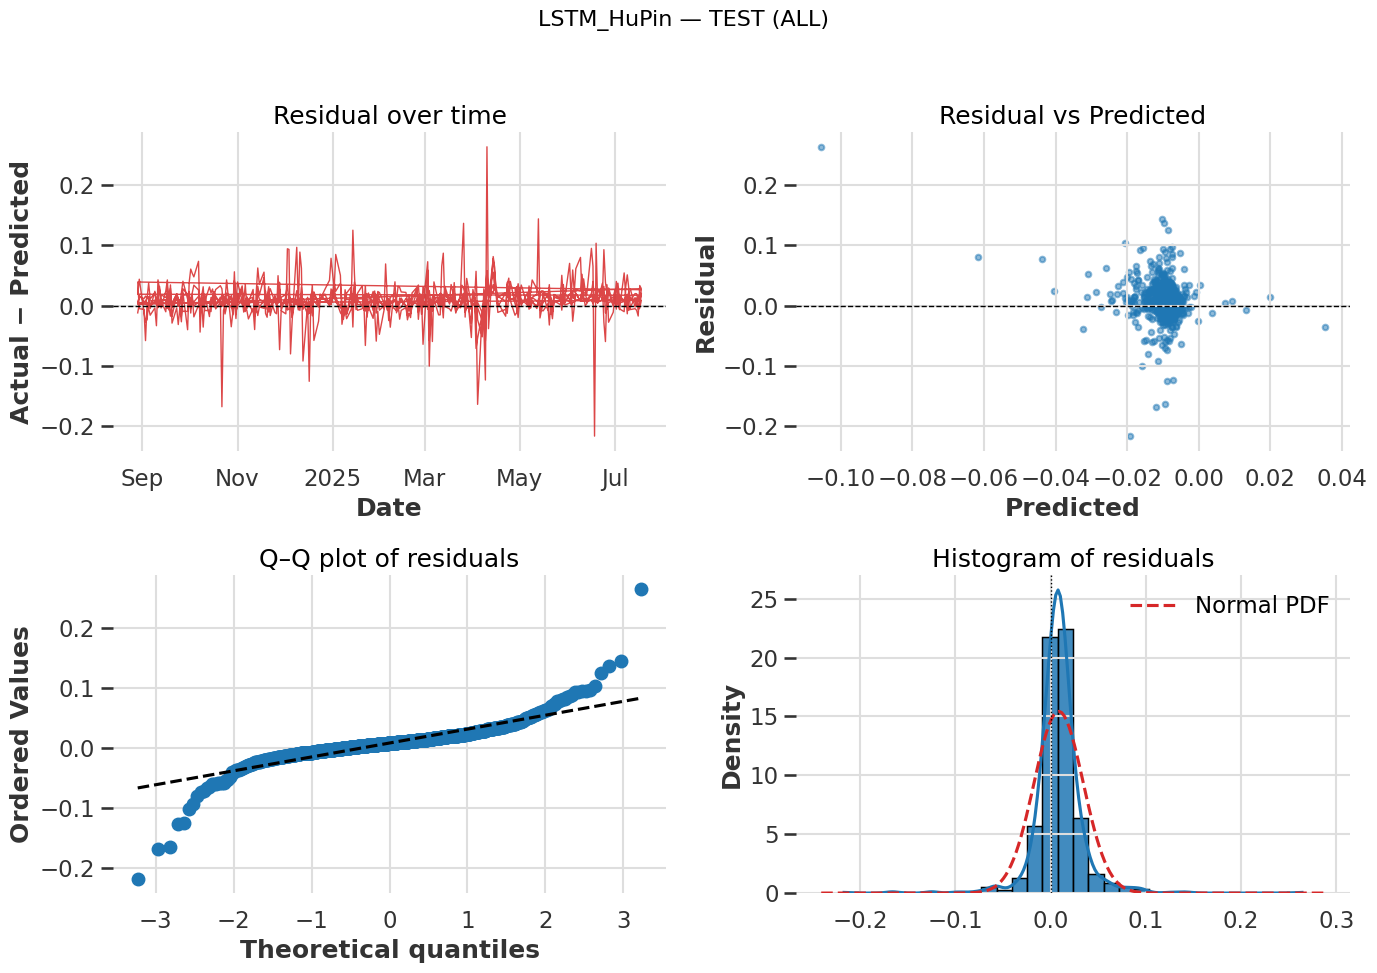

📊 Residual stats — LSTM_HuPin — TEST (ALL): Mean 0.008383 | Std 0.025854 | Skew -0.094 | Kurt(excess) 20.363


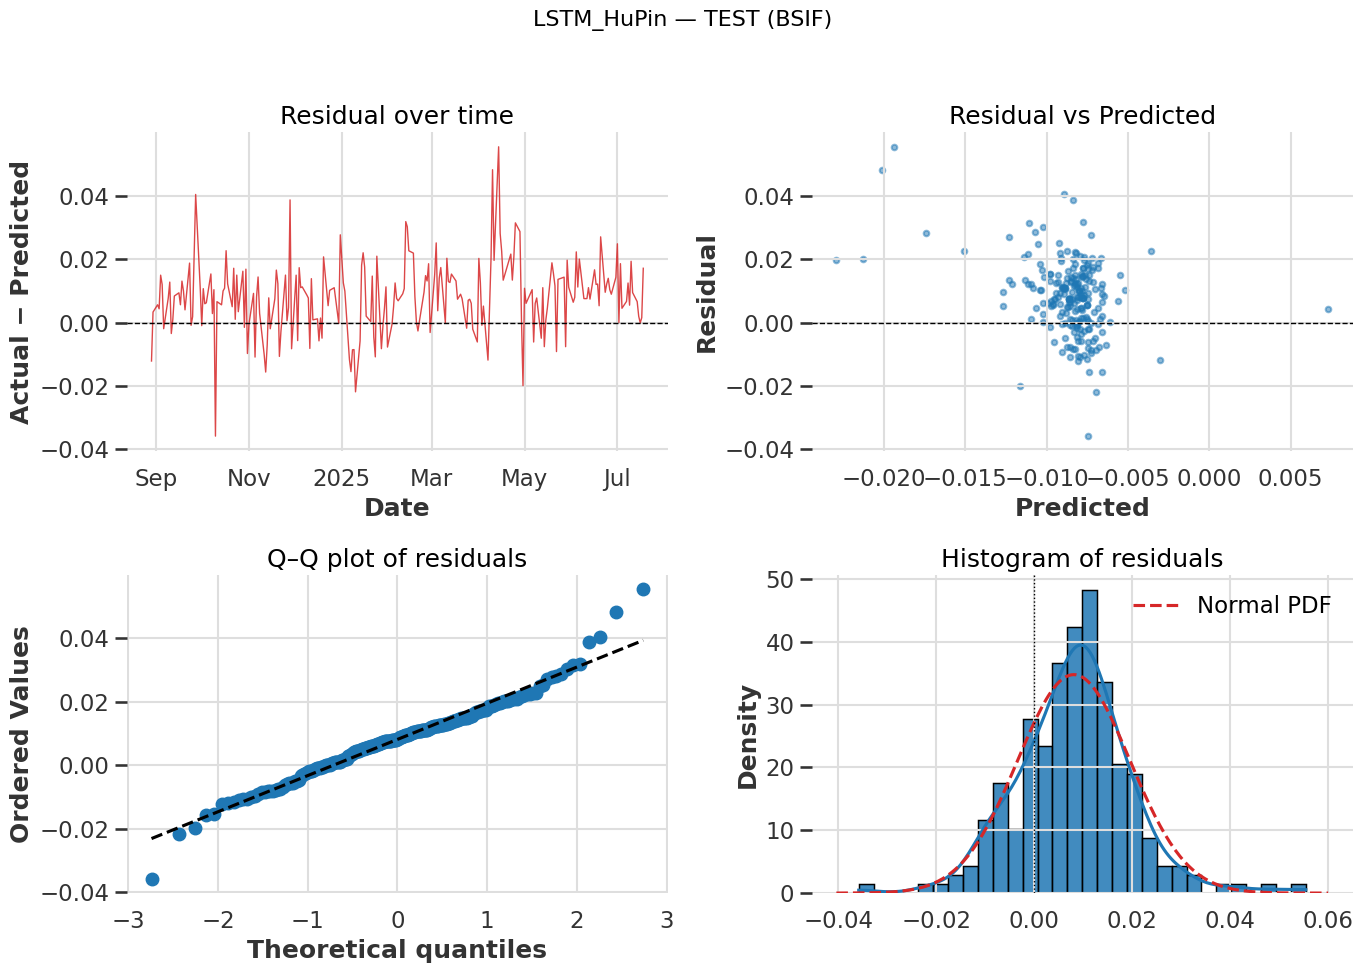

📊 Residual stats — LSTM_HuPin — TEST (BSIF): Mean 0.008078 | Std 0.011471 | Skew 0.201 | Kurt(excess) 2.093


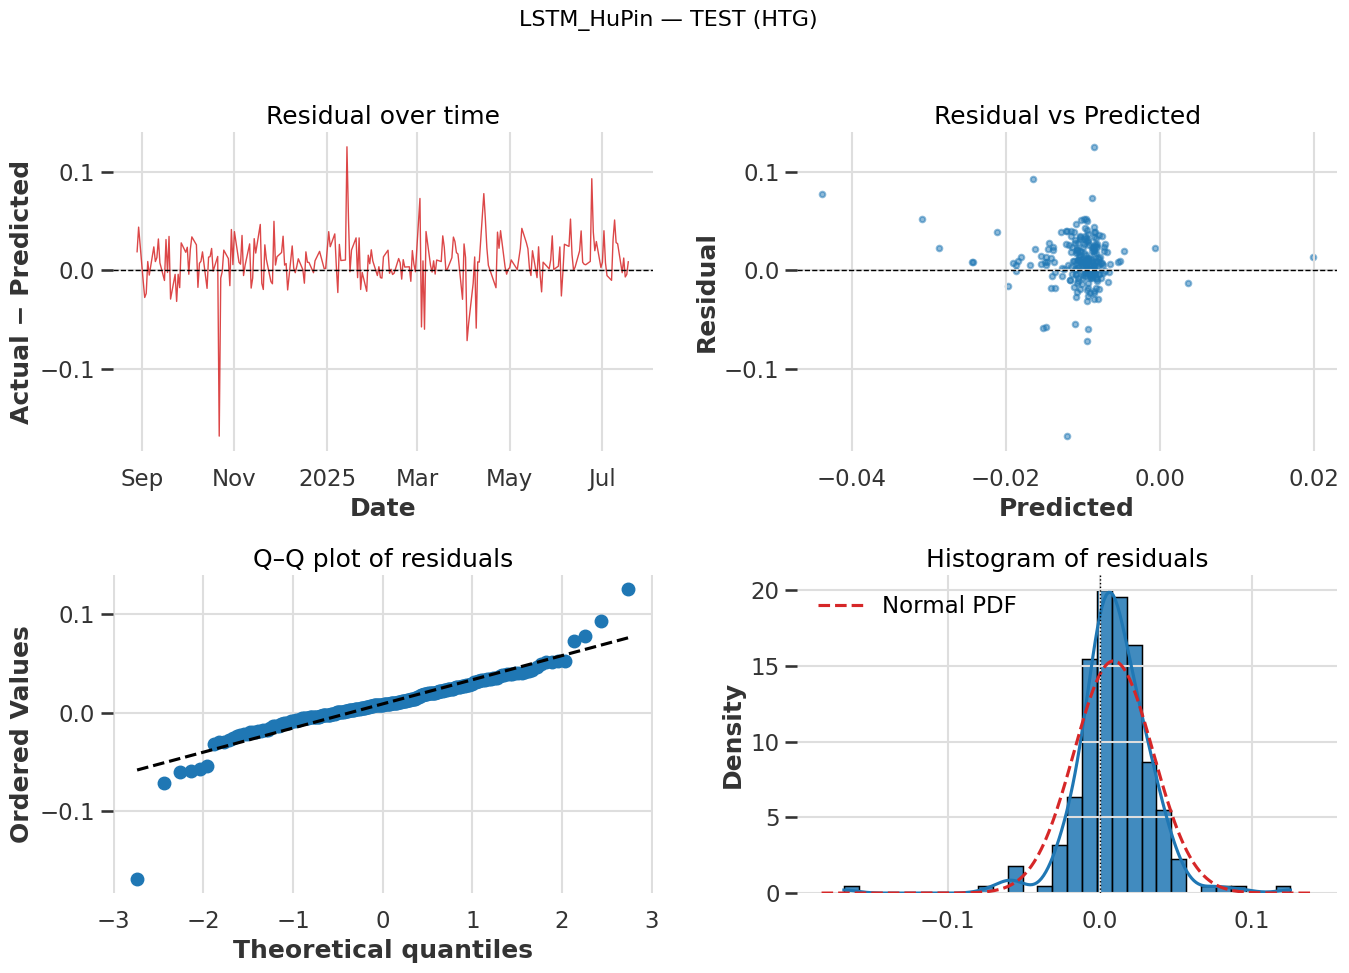

📊 Residual stats — LSTM_HuPin — TEST (HTG): Mean 0.009057 | Std 0.026047 | Skew -1.047 | Kurt(excess) 10.862


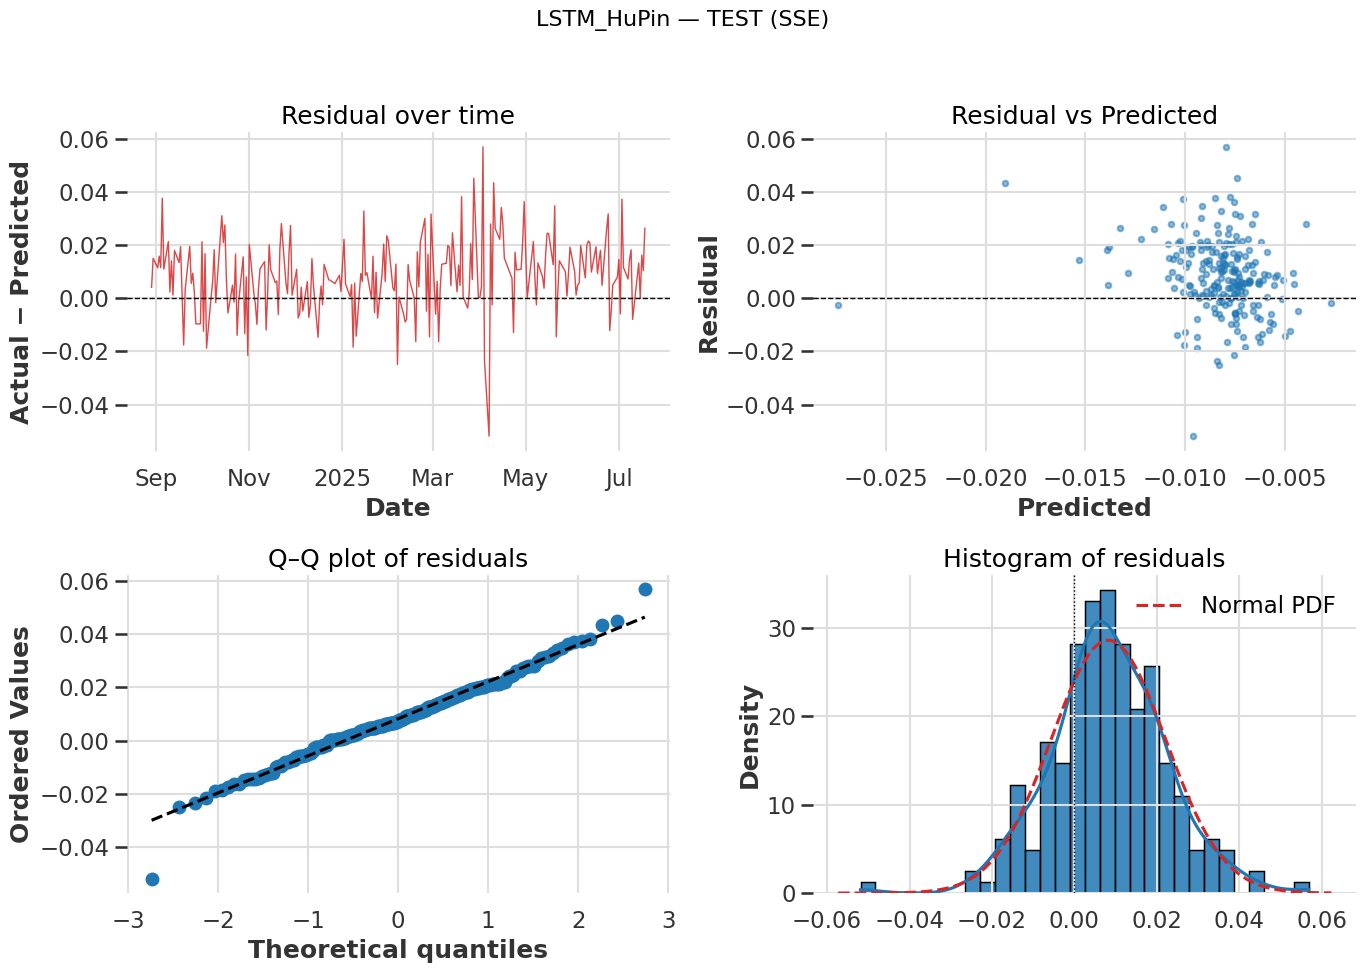

📊 Residual stats — LSTM_HuPin — TEST (SSE): Mean 0.008256 | Std 0.013941 | Skew -0.098 | Kurt(excess) 1.485


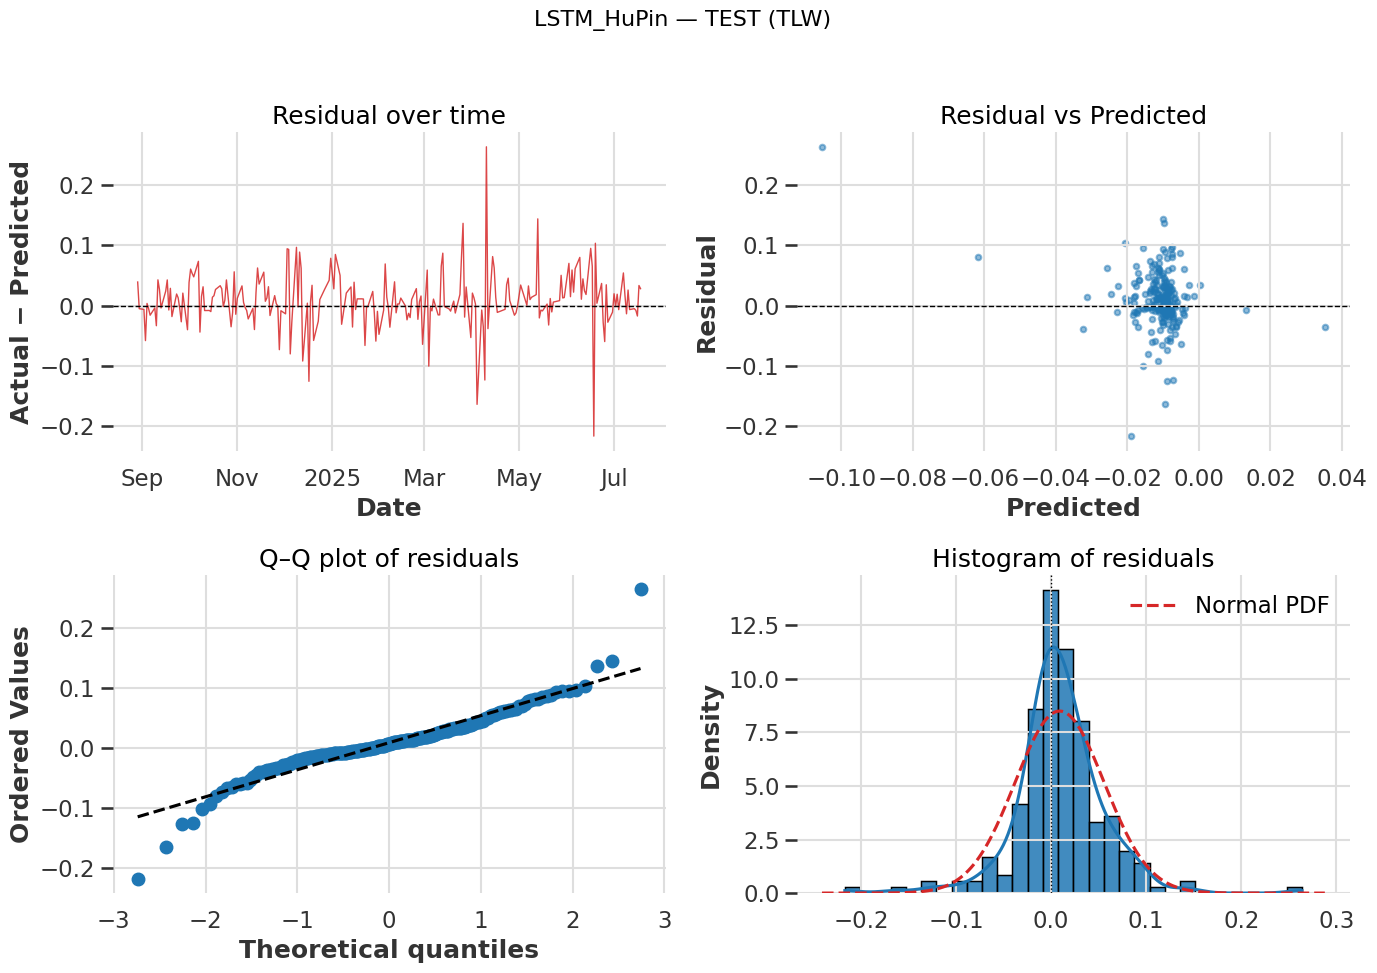

📊 Residual stats — LSTM_HuPin — TEST (TLW): Mean 0.008948 | Std 0.046964 | Skew 0.053 | Kurt(excess) 6.355


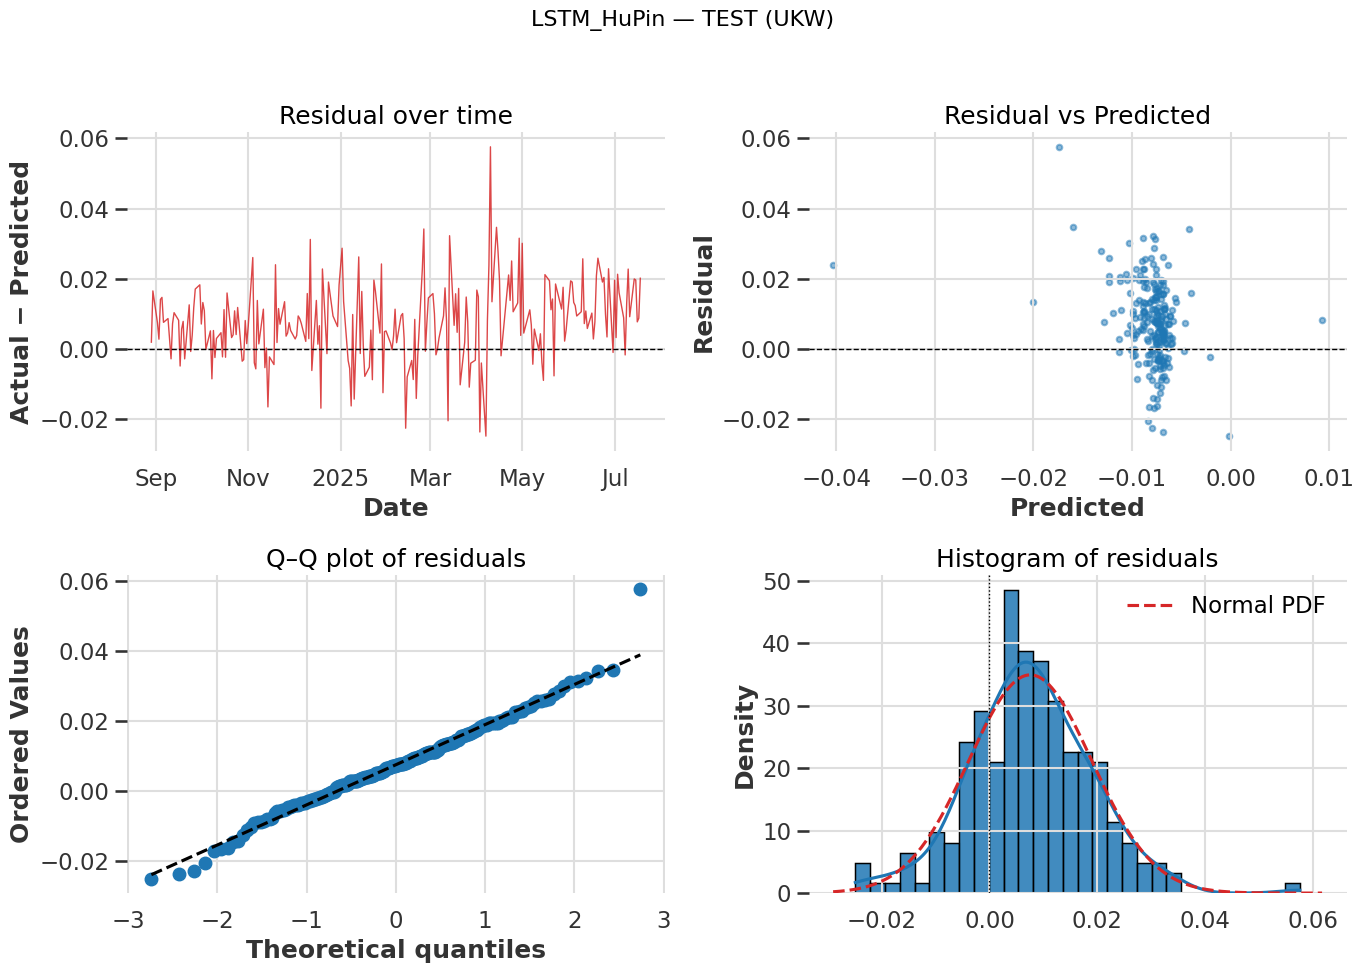

📊 Residual stats — LSTM_HuPin — TEST (UKW): Mean 0.007574 | Std 0.011425 | Skew 0.196 | Kurt(excess) 1.381


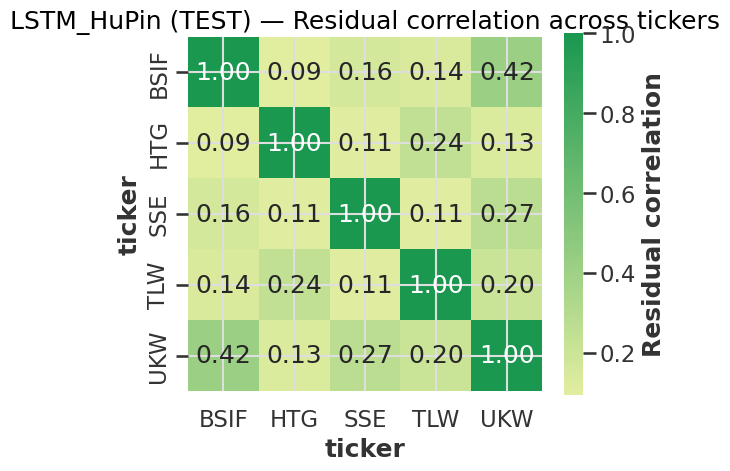

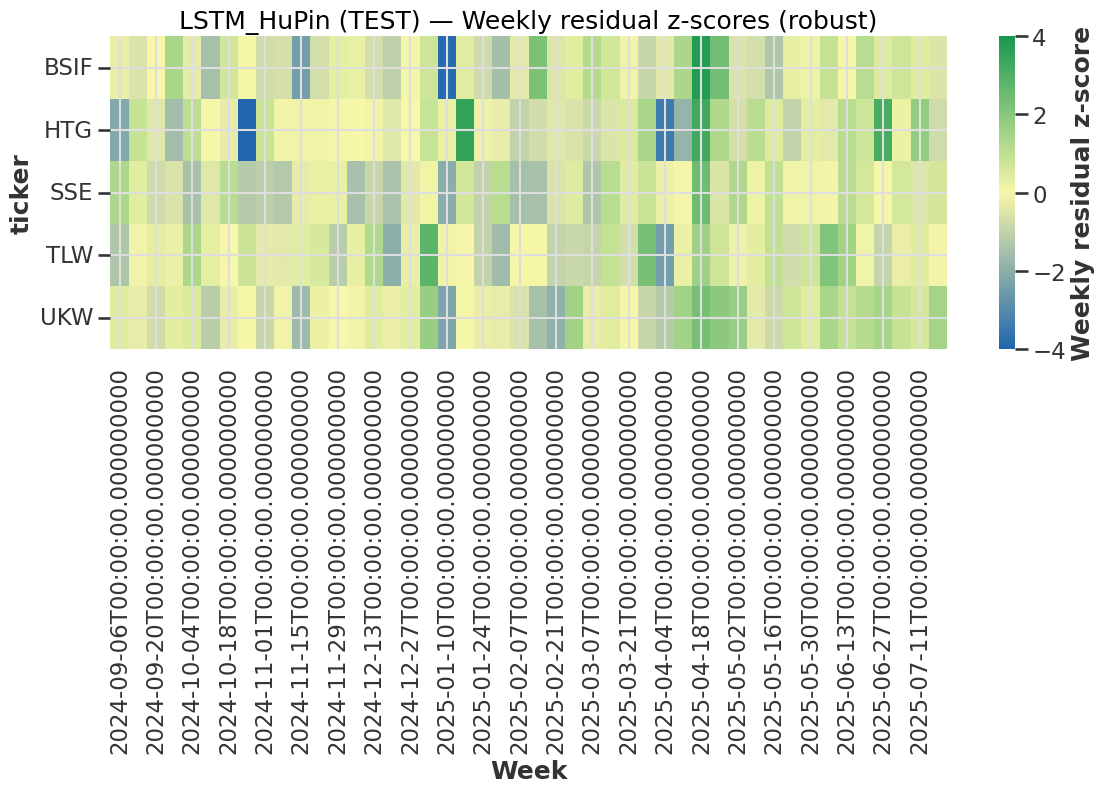

In [12]:
# =========================
# Residual diagnostics — LSTM_HuPin (BlockRNN + past_covariates)
# Fixes: readable date axis + robust weekly heatmap (no “all zeros” look)
# =========================

import matplotlib.dates as mdates
from scipy import stats

sns.set_context("talk")

# ---------------- User knobs ----------------
SET = "test"   # "test" or "val"
BASE_DIR = os.path.join("outputs", "hupin")
PTH = f"{BASE_DIR}/final_{SET}_predictions.parquet"
FIG_DIR = f"{BASE_DIR}/diagnostics_{SET}"
os.makedirs(FIG_DIR, exist_ok=True)

# Heatmap controls
RESAMPLE_RULE   = "W-FRI"   # robust weekly anchor
MIN_PER_WEEK    = 3         # require >=3 obs in the week; else NaN
ZSCORE_ROBUST   = True      # median/MAD robust z-score
CLIP_Z          = 4.0       # clip z-scores to [-4,4] for color stability

TICKER_MAP = {0: "BSIF", 1: "HTG", 2: "SSE", 3: "TLW", 4: "UKW"}
BYG = sns.blend_palette(["#2166ac", "#f7f7a9", "#1a9850"], as_cmap=True)

# ---------- Load ----------
df = pd.read_parquet(PTH).copy()
df["Date"] = pd.to_datetime(df["Date"])
df["ticker"] = df["ticker_id"].map(TICKER_MAP).astype("category")
df.sort_values(["ticker_id","Date"], inplace=True)

# sanity: ensure needed cols exist
for col in ["y_true","y_pred","resid"]:
    if col not in df.columns:
        if col == "resid":
            df["resid"] = df["y_true"] - df["y_pred"]
        else:
            raise ValueError(f"Column '{col}' missing in {PTH}")

# ---------- Helpers ----------
def set_nice_date_axis(ax):
    loc = mdates.AutoDateLocator(minticks=5, maxticks=8)
    fmt = mdates.ConciseDateFormatter(loc)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(fmt)

def robust_zscore_col(s: pd.Series, clip=CLIP_Z):
    med = s.median(skipna=True)
    mad = (s - med).abs().median(skipna=True)
    if not np.isfinite(mad) or mad == 0:
        z = s - med  # fallback: center only
    else:
        z = (s - med) / (1.4826 * mad)
    return z.clip(-clip, clip)

def plot_diagnostics_with_stats(actual, predicted, dates=None, title=""):
    errors = np.asarray(actual) - np.asarray(predicted)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=16)

    # 1) Residual over time
    if dates is not None:
        axes[0, 0].plot(pd.to_datetime(dates), errors, color="#d62728", linewidth=1.0, alpha=0.85)
        axes[0, 0].set_xlabel("Date"); set_nice_date_axis(axes[0, 0])
    else:
        axes[0, 0].plot(errors, color="#d62728", linewidth=1.0, alpha=0.85)
        axes[0, 0].set_xlabel("Index")
    axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0, 0].set_title("Residual over time")
    axes[0, 0].set_ylabel("Actual − Predicted")

    # 2) Residual vs Predicted
    axes[0, 1].scatter(predicted, errors, alpha=0.5, s=16, color="#1f77b4")
    axes[0, 1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0, 1].set_title("Residual vs Predicted")
    axes[0, 1].set_xlabel("Predicted")
    axes[0, 1].set_ylabel("Residual")

    # 3) Q–Q
    stats.probplot(errors, dist="norm", plot=axes[1, 0])
    for ln in axes[1, 0].get_lines()[:-1]:
        ln.set_color("#1f77b4")
    axes[1, 0].get_lines()[-1].set_color("black")
    axes[1, 0].get_lines()[-1].set_linestyle("--")
    axes[1, 0].set_title("Q–Q plot of residuals")

    # 4) Histogram + Normal PDF
    sns.histplot(errors, kde=True, stat="density", bins=30, ax=axes[1, 1], color="#1f77b4", alpha=0.85)
    xmin, xmax = axes[1, 1].get_xlim()
    x = np.linspace(xmin, xmax, 200)
    pdf = stats.norm.pdf(x, np.nanmean(errors), np.nanstd(errors))
    axes[1, 1].plot(x, pdf, color="#d62728", linestyle="--", label="Normal PDF")
    axes[1, 1].axvline(0, color="black", linestyle=":", linewidth=1)
    axes[1, 1].set_title("Histogram of residuals")
    axes[1, 1].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig, errors

# ---------- 0) Overall ----------
title = f"LSTM_HuPin — {SET.upper()} (ALL)"
fig, errs = plot_diagnostics_with_stats(df["y_true"].values, df["y_pred"].values, df["Date"].values, title)
fig.savefig(os.path.join(FIG_DIR, f"hupin_{SET}_overall.png"), dpi=160)
plt.show()
print(f"📊 Residual stats — {title}: "
      f"Mean {np.nanmean(errs):.6f} | Std {np.nanstd(errs):.6f} | "
      f"Skew {stats.skew(errs, nan_policy='omit'):.3f} | "
      f"Kurt(excess) {stats.kurtosis(errs, fisher=True, nan_policy='omit'):.3f}")

# ---------- 1) Per-ticker ----------
for tic, g in df.groupby("ticker", sort=False):
    title = f"LSTM_HuPin — {SET.upper()} ({tic})"
    fig, e = plot_diagnostics_with_stats(g["y_true"].values, g["y_pred"].values, g["Date"].values, title)
    fig.savefig(os.path.join(FIG_DIR, f"hupin_{SET}_{tic}.png"), dpi=160)
    plt.show()
    print(f"📊 Residual stats — {title}: "
          f"Mean {np.nanmean(e):.6f} | Std {np.nanstd(e):.6f} | "
          f"Skew {stats.skew(e, nan_policy='omit'):.3f} | "
          f"Kurt(excess) {stats.kurtosis(e, fisher=True, nan_policy='omit'):.3f}")

# ---------- 2) Residual correlation heatmap (BYG) ----------
pivot = df.pivot_table(index="Date", columns="ticker", values="resid").sort_index()
corr = pivot.corr(min_periods=10)
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=BYG, center=0, square=True,
            cbar_kws={"label": "Residual correlation"})
plt.title(f"LSTM_HuPin ({SET.upper()}) — Residual correlation across tickers")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"hupin_{SET}_resid_corr.png"), dpi=160)
plt.show()

# ---------- 3) Robust weekly heatmap of residual z-scores ----------
# Aggregate weekly per ticker with a minimum count filter
g = (df.set_index("Date")
       .groupby("ticker")["resid"]
       .resample(RESAMPLE_RULE)
       .agg(lambda s: np.nan if len(s) < MIN_PER_WEEK else float(np.nanmean(s)))
       .reset_index())

# Pivot to weeks x tickers
week_pivot = g.pivot_table(index="Date", columns="ticker", values="resid").sort_index()

# Robust z-score per ticker (columnwise)
if ZSCORE_ROBUST:
    week_z = week_pivot.apply(robust_zscore_col, axis=0)
else:
    week_z = (week_pivot - week_pivot.mean()) / week_pivot.std(ddof=0)

plt.figure(figsize=(12, max(4, 0.18 * len(week_z))))
sns.heatmap(week_z.T, cmap=BYG, center=0, vmin=-CLIP_Z, vmax=CLIP_Z,
            cbar_kws={"label": "Weekly residual z-score"})
plt.yticks(rotation=0)
plt.xlabel("Week")
plt.title(f"LSTM_HuPin ({SET.upper()}) — Weekly residual z-scores (robust)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"hupin_{SET}_weekly_resid_heatmap.png"), dpi=160)
plt.show()


## 5. Joint Quantile Regression


In [13]:
# =========================================
# LINEAR BASELINE (JOINT/GLOBAL): Quantile Regression across all tickers
# - Inputs: outputs/data/df_LSTM_train.csv, outputs/data/df_LSTM_test.csv
# - Outputs under outputs/quantile_joint/:
#     * final_val_predictions.parquet / final_test_predictions.parquet
#     * final_val_metrics_bmr_compare.csv / final_test_metrics_bmr_compare.csv
#     * models/quantile_joint.darts
#     * best_cfg_joint.json
# - Leak-free StandardScaler fit on TRAIN windows only (pre-embargo), applied to numeric covariates
# - Target lags = {1..L}; past-covariates lag = {0} (Darts: lags_past_covariates=[-1])
# - Selection on VAL:
#     * Quantile joint: maximize MICRO-F2 on z-tail (per-ticker τ_z from TRAIN; MAD fallback to Q(0.0228));
#       tie-break by pooled VAL RMSE
# - Metrics include: RMSE, R², BearMissRate (directional), BearMissRate_tol (directional), BearMissRate_z
#   (+ z-miss, z-bears, z-threshold, N)
# =========================================

import os, json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Tuple, List

from darts import TimeSeries
from src.models import build_submitted_quantile_regression

# -------- paths --------
SRC_DIR = os.path.join("outputs", "data")
TRAIN_CSV = os.path.join(SRC_DIR, "df_LSTM_train.csv")
TEST_CSV  = os.path.join(SRC_DIR, "df_LSTM_test.csv")

JOINT_DIR = os.path.join("outputs", "quantile_joint")
os.makedirs(JOINT_DIR, exist_ok=True)
os.makedirs(os.path.join(JOINT_DIR, "models"), exist_ok=True)

ROOT_METRICS_LOG = Path("outputs") / "model_metrics.csv"

# -------- config --------
TICKER_MAP = {0:"BSIF", 1:"HTG", 2:"SSE", 3:"TLW", 4:"UKW"}
TICKERS = [0,1,2,3,4]
ID_COL, TARGET_COL = "ticker_id", "log_return"
FLAGS  = ["brexit_transition","covid_awareness","post_pandemic","war_ukraine","renewables"]
NUMERIC = [
    "EMA_30","RSI","MACD","YZ_vol","BrGBP_logchg",
    "MarketCap_GBP","OVX","GUK10Y","FTSE_lr"
]

VAL_FRACTION = 0.10
SEED = 42

# Grid for joint quantile model
GRID_QUANT_JOINT = {
    "L":        [60, 90],
    "alpha":    [1e-4, 1e-3],
    "tau":      [0.25, 0.5],   # as requested
}

# Tail metric knobs
K_ERR = 1.0     # tolerance factor × per-ticker VAL RMSE (for BMR_tol)

# z-BMR robust cutoff controls
MAD_MULTIPLIER = 2.0
Z_PSTAR = 0.0228            # ≈ Phi(-2)
MIN_TRAIN_TAIL_EVENTS = 5   # fallback to quantile if train tail too sparse

# -------- canonical helpers --------
# These aliases preserve the numerical definitions in src/ while keeping the
# model-specific joint aggregation and F2 selection visible below.
rmse = submitted_rmse
bmr_standard_directional = submitted_bmr
bmr_tolerant_directional = submitted_bmr_tolerant
z_bear_miss_rate = submitted_bmr_z
train_tail_threshold = submitted_robust_bmr_z_threshold
add_ticker_ohe = build_ohe


def summarize_with_tails(df_preds: pd.DataFrame, label: str, out_csv: str,
                         ref_val_df: pd.DataFrame, z_thresh_map: dict):
    rows = []
    miss_total, bear_total = 0, 0

    # Overall validation RMSE supplies the ALL-row BMR tolerance.
    rmse_val_all = rmse(ref_val_df["y_true"].to_numpy(), ref_val_df["y_pred"].to_numpy())
    e_err_all = K_ERR * rmse_val_all

    for tid, g in df_preds.groupby("ticker_id"):
        a = g.y_true.values
        p = g.y_pred.values

        # Per-ticker validation RMSE supplies each ticker's BMR tolerance.
        gv = ref_val_df[ref_val_df["ticker_id"] == tid]
        rmsev = rmse(gv.y_true.values, gv.y_pred.values) if len(gv) else rmse(a, p)
        eps_err = K_ERR * rmsev

        row = {
            "ticker_id": int(tid),
            "RMSE": rmse(a, p),
            "R²": submitted_r_squared(a, p),
            "BearMissRate": bmr_standard_directional(a, p),
            "BearMissRate_tol": bmr_tolerant_directional(a, p, eps_err),
            "N": len(g),
        }

        if tid in z_thresh_map:
            tthr = float(z_thresh_map[tid])
            z_frac, z_miss, z_bears = z_bear_miss_rate(a, p, tthr)
            row["BearMissRate_z"] = z_frac
            row["z-miss"] = int(z_miss)
            row["z-bears"] = int(z_bears)
            row["z-threshold"] = tthr
            if z_bears > 0:
                miss_total += z_miss
                bear_total += z_bears

        rows.append(row)

    a_all = df_preds.y_true.values
    p_all = df_preds.y_pred.values
    z_all, z_miss_all, z_bears_all = submitted_pooled_bmr_z(
        [(miss_total, bear_total)]
    )
    overall = {
        "ticker_id": "ALL",
        "RMSE": rmse(a_all, p_all),
        "R²": submitted_r_squared(a_all, p_all),
        "BearMissRate": bmr_standard_directional(a_all, p_all),
        "BearMissRate_tol": bmr_tolerant_directional(a_all, p_all, e_err_all),
        "N": len(df_preds),
        "BearMissRate_z": z_all,
        "z-miss": z_miss_all,
        "z-bears": z_bears_all,
        "z-threshold": float("nan"),
    }

    metrics = pd.DataFrame(rows + [overall])
    metrics.to_csv(out_csv, index=False)
    print(f"{label} -> {out_csv}")
    return metrics


def micro_f2_z(val_df: pd.DataFrame, z_thresh_map: Dict[int, float], beta: float = 2.0) -> float:
    """Micro-averaged F-beta on the per-ticker training-defined z-tail."""
    tp = 0.0
    fp = 0.0
    fn = 0.0
    for tid, g in val_df.groupby("ticker_id"):
        if tid not in z_thresh_map or not np.isfinite(z_thresh_map[tid]):
            continue
        threshold = z_thresh_map[tid]
        actual = g["y_true"].to_numpy()
        prediction = g["y_pred"].to_numpy()
        actual_tail = actual <= threshold
        predicted_tail = prediction <= threshold
        tp += float(np.sum(actual_tail & predicted_tail))
        fp += float(np.sum(~actual_tail & predicted_tail))
        fn += float(np.sum(actual_tail & ~predicted_tail))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    if precision == 0.0 and recall == 0.0:
        return 0.0
    beta_squared = beta * beta
    return ((1.0 + beta_squared) * precision * recall /
            (beta_squared * precision + recall))

# -------- load panels & add ticker OHE --------
tr = pd.read_csv(TRAIN_CSV, parse_dates=["Date"]).set_index("Date").sort_index()
te = pd.read_csv(TEST_CSV,  parse_dates=["Date"]).set_index("Date").sort_index()

tr, ohe_cols_tr = add_ticker_ohe(tr, n_tickers=len(TICKERS))
te, ohe_cols_te = add_ticker_ohe(te, n_tickers=len(TICKERS))

NUMERIC_TR = [c for c in NUMERIC if c in tr.columns]
NUMERIC_TE = [c for c in NUMERIC if c in te.columns]

COV_COLS_TR = NUMERIC_TR + [c for c in FLAGS if c in tr.columns] + ohe_cols_tr
COV_COLS_TE = NUMERIC_TE + [c for c in FLAGS if c in te.columns] + ohe_cols_te

assert tr[[TARGET_COL] + COV_COLS_TR + [ID_COL]].isna().sum().sum() == 0, "NaNs in TRAIN."
assert te[[TARGET_COL] + COV_COLS_TE + [ID_COL]].isna().sum().sum() == 0, "NaNs in TEST."

# -------- Prepare raw arrays per ticker --------
Raw: Dict[int, Tuple[np.ndarray, np.ndarray, np.ndarray]] = {}  # tid -> (y_all, X_all, dates)
for tid, df_t in tr.groupby(ID_COL):
    df_t = df_t.sort_index()
    y = df_t[TARGET_COL].to_numpy(np.float32)
    X = df_t[COV_COLS_TR].to_numpy(np.float32)
    d = df_t.index.to_numpy()
    Raw[int(tid)] = (y, X, d)

# -------- Grid search for joint model --------
best = {
    "f2": -np.inf,
    "rmse": np.inf,
    "cfg": None,
    "model": None,
    "L": None,
    "z_thresh_map": None,
    "scaler": None,
    "dates_by_tid": None,
    "y_ts_list": None,
    "X_ts_list": None,
    "split_idx": None,
}

for L in GRID_QUANT_JOINT["L"]:
    # split index per ticker
    split_idx: Dict[int, int] = {}
    for tid in TICKERS:
        y_all, _, _ = Raw[tid]
        n = len(y_all)
        split_idx[tid] = embargo_split_idx(n, L, VAL_FRACTION)

    # z-threshold per ticker from TRAIN-only window for this L
    z_thresh_map: Dict[int, float] = {}
    for tid in TICKERS:
        y_all, _, _ = Raw[tid]
        s = split_idx[tid]
        y_tr_only = y_all[:s]
        if len(y_tr_only) > 0:
            z_thresh_map[tid] = train_tail_threshold(y_tr_only)
        else:
            z_thresh_map[tid] = np.nan

    # Fit scaler on TRAIN windows only, pooled across tickers.
    num_idx_tr = [COV_COLS_TR.index(c) for c in NUMERIC_TR]
    scaler = fit_pooled_prefix_standard_scaler(
        Raw,
        split_idx,
        num_idx_tr,
        empty_message="No training blocks to fit the scaler.",
    )

    # Transform FULL series (train+val) and build TimeSeries lists
    y_ts_list: List[TimeSeries] = []
    X_ts_list: List[TimeSeries] = []
    dates_by_tid: Dict[int, np.ndarray] = {}
    for tid in TICKERS:
        y_all, X_all, dts = Raw[tid]
        Xs = X_all.copy()
        if len(num_idx_tr) > 0:
            Xs[:, num_idx_tr] = scaler.transform(Xs[:, num_idx_tr])
        y_ts_list.append(TimeSeries.from_values(y_all))
        X_ts_list.append(TimeSeries.from_values(Xs))
        dates_by_tid[tid] = dts

    for alpha in GRID_QUANT_JOINT["alpha"]:
        for tau in GRID_QUANT_JOINT["tau"]:
            # Build one global QuantileRegressor and fit it on all ticker series.
            model = build_submitted_quantile_regression(
                lookback=L,
                alpha=float(alpha),
                tau=float(tau),
            )

            # Fit on TRAIN windows (lists)
            S_TR = []
            C_TR = []
            for i, tid in enumerate(TICKERS):
                s = split_idx[tid]
                y_tr, _ = y_ts_list[i].split_before(s)
                X_tr, _ = X_ts_list[i].split_before(s)
                S_TR.append(y_tr); C_TR.append(X_tr)
            model.fit(series=S_TR, past_covariates=C_TR)

            # Build VAL predictions pooled across tickers
            val_rows = []
            for i, tid in enumerate(TICKERS):
                s = split_idx[tid]
                y_ts = y_ts_list[i]; X_ts = X_ts_list[i]
                fc = model.historical_forecasts(
                    series=y_ts, past_covariates=X_ts,
                    start=y_ts.time_index[s], forecast_horizon=1, stride=1,
                    retrain=False, last_points_only=True, verbose=False
                )
                fc = fc.slice_intersect(y_ts)
                pred = fc.values().squeeze()
                true = y_ts.slice_intersect(fc).values().squeeze()
                idxs = fc.time_index.values
                dts  = dates_by_tid[tid][idxs]
                for d, p, t in zip(dts, pred, true):
                    val_rows.append({"ticker_id": int(tid), "Date": pd.Timestamp(d),
                                     "y_true": float(t), "y_pred": float(p)})

            val_df = pd.DataFrame(val_rows).sort_values(["ticker_id","Date"])
            if val_df.empty:
                continue

            # Selection: MICRO-F2 on z-tail; tie-break by pooled VAL RMSE
            f2 = micro_f2_z(val_df, z_thresh_map, beta=2.0)
            rm = rmse(val_df["y_true"].to_numpy(), val_df["y_pred"].to_numpy())

            is_better = (f2 > best["f2"]) or ((f2 == best["f2"]) and (rm < best["rmse"]))
            if is_better:
                best.update(
                    f2=f2, rmse=rm,
                    cfg={"L": L, "alpha": float(alpha), "tau": float(tau)},
                    model=model, L=L,
                    z_thresh_map=z_thresh_map,
                    scaler=scaler,
                    dates_by_tid=dates_by_tid,
                    y_ts_list=y_ts_list, X_ts_list=X_ts_list,
                    split_idx=split_idx
                )

if best["model"] is None:
    raise RuntimeError("Joint Quantile model: no valid configuration found.")

# -------- Save best model + config --------
best_model = best["model"]
best_cfg = best["cfg"]
with open(os.path.join(JOINT_DIR, "best_cfg_joint.json"), "w") as fp:
    json.dump({"best_config": best_cfg, "best_val_RMSE": best["rmse"], "best_val_F2z": best["f2"]}, fp, indent=2)

best_model_path = os.path.join(JOINT_DIR, "models", "quantile_joint.darts")
best_model.save(best_model_path)

print("Best JOINT Quantile config:", best_cfg)

# -------- VAL predictions (persist) --------
val_rows = []
for i, tid in enumerate(TICKERS):
    s = best["split_idx"][tid]
    y_ts = best["y_ts_list"][i]; X_ts = best["X_ts_list"][i]
    fc = best_model.historical_forecasts(
        series=y_ts, past_covariates=X_ts,
        start=y_ts.time_index[s], forecast_horizon=1, stride=1,
        retrain=False, last_points_only=True, verbose=False
    )
    fc = fc.slice_intersect(y_ts)
    pred = fc.values().squeeze()
    true = y_ts.slice_intersect(fc).values().squeeze()
    idxs = fc.time_index.values
    dts  = best["dates_by_tid"][tid][idxs]
    for d, p, t in zip(dts, pred, true):
        val_rows.append({"ticker_id": int(tid), "Date": pd.Timestamp(d),
                         "y_true": float(t), "y_pred": float(p)})

val_df = pd.DataFrame(val_rows).sort_values(["ticker_id","Date"])
val_parq = os.path.join(JOINT_DIR, "final_val_predictions.parquet")
val_df.to_parquet(val_parq, index=False)

# Per-ticker VAL RMSE for BMR_tol thresholds
rmse_val_by_tid = val_df.groupby("ticker_id").apply(lambda g: rmse(g["y_true"].to_numpy(), g["y_pred"].to_numpy())).to_dict()

# -------- TEST predictions (apply same scaler; no refit) --------
test_rows = []
for tid, dte in te.groupby(ID_COL):
    tid = int(tid)
    dte = dte.sort_index()
    dates = dte.index.to_numpy()
    y_vals = dte[TARGET_COL].to_numpy(np.float32)
    X_vals = dte[COV_COLS_TE].to_numpy(np.float32)

    # scale numeric cols with the TRAIN scaler
    num_idx_te = [COV_COLS_TE.index(c) for c in NUMERIC_TE]
    if len(num_idx_te) > 0:
        X_scaled = X_vals.copy()
        X_scaled[:, num_idx_te] = best["scaler"].transform(X_scaled[:, num_idx_te])
    else:
        X_scaled = X_vals

    y_ts = TimeSeries.from_values(y_vals)
    X_ts = TimeSeries.from_values(X_scaled)

    L = best["L"]
    if len(y_ts) <= L:
        continue

    fc = best_model.historical_forecasts(
        series=y_ts, past_covariates=X_ts,
        start=y_ts.time_index[L], forecast_horizon=1, stride=1,
        retrain=False, last_points_only=True, verbose=False
    )
    fc = fc.slice_intersect(y_ts)
    pred = fc.values().squeeze()
    true = y_ts.slice_intersect(fc).values().squeeze()
    idxs = fc.time_index.values
    dts  = dates[idxs]
    for d, p, t in zip(dts, pred, true):
        test_rows.append({"ticker_id": tid, "Date": pd.Timestamp(d),
                          "y_true": float(t), "y_pred": float(p)})

test_df = pd.DataFrame(test_rows).sort_values(["ticker_id","Date"])
test_parq = os.path.join(JOINT_DIR, "final_test_predictions.parquet")
test_df.to_parquet(test_parq, index=False)

# -------- Metrics with BMRs + z-BMR (using TRAIN-only thresholds of best L) --------
# Build eps_err_map from VAL RMSE per ticker (for BMR_tol); overall computed inside summarize
def _summarize(df_preds: pd.DataFrame, label: str, out_csv: str):
    return summarize_with_tails(
        df_preds=df_preds,
        label=label,
        out_csv=out_csv,
        ref_val_df=val_df,                 # to derive per-ticker RMSE thresholds
        z_thresh_map=best["z_thresh_map"]  # fixed from TRAIN windows (best L)
    )

val_csv  = os.path.join(JOINT_DIR, "final_val_metrics_bmr_compare.csv")
test_csv = os.path.join(JOINT_DIR, "final_test_metrics_bmr_compare.csv")
val_metrics  = _summarize(val_df,  "JOINT Quantile Validation", val_csv)
test_metrics = _summarize(test_df, "JOINT Quantile Test",       test_csv)

# -------- Append compact TEST rows to root model_metrics.csv --------
rows_log = []
for _, r in test_metrics.iterrows():
    rows_log.append({
        "Model": "LIN_QuantileJoint",
        "Ticker": r["ticker_id"],
        "RMSE": round(float(r["RMSE"]), 8),
        "R²": round(float(r["R²"]), 5) if pd.notna(r["R²"]) else np.nan,
        "BearMissRate": round(float(r["BearMissRate"]), 5),
        "BearMissRate_tol": round(float(r["BearMissRate_tol"]), 5),
        "BearMissRate_z": round(float(r.get("BearMissRate_z", np.nan)), 5) if pd.notna(r.get("BearMissRate_z", np.nan)) else np.nan,
    })
rows_log = pd.DataFrame(rows_log)
if ROOT_METRICS_LOG.exists():
    rows_log.to_csv(ROOT_METRICS_LOG, mode="a", header=False, index=False)
else:
    rows_log.to_csv(ROOT_METRICS_LOG, index=False)

print("\nSaved JOINT Quantile baseline:")
print(f"- Best config: {best_cfg}")
print(f"- VAL preds:  {val_parq}")
print(f"- TEST preds: {test_parq}")
print(f"- VAL metrics:  {val_csv}")
print(f"- TEST metrics: {test_csv}")
print(f"- Model saved:  {best_model_path}")
print(f"- Appended compact TEST rows -> {ROOT_METRICS_LOG.resolve()}")


Best JOINT Quantile config: {'L': 60, 'alpha': 0.0001, 'tau': 0.5}
JOINT Quantile Validation -> outputs\quantile_joint\final_val_metrics_bmr_compare.csv
JOINT Quantile Test -> outputs\quantile_joint\final_test_metrics_bmr_compare.csv

Saved JOINT Quantile baseline:
- Best config: {'L': 60, 'alpha': 0.0001, 'tau': 0.5}
- VAL preds:  outputs\quantile_joint\final_val_predictions.parquet
- TEST preds: outputs\quantile_joint\final_test_predictions.parquet
- VAL metrics:  outputs\quantile_joint\final_val_metrics_bmr_compare.csv
- TEST metrics: outputs\quantile_joint\final_test_metrics_bmr_compare.csv
- Model saved:  outputs\quantile_joint\models\quantile_joint.darts
- Appended compact TEST rows -> <PROJECT_ROOT>\outputs\model_metrics.csv


### 5.1 Residual diagnostics


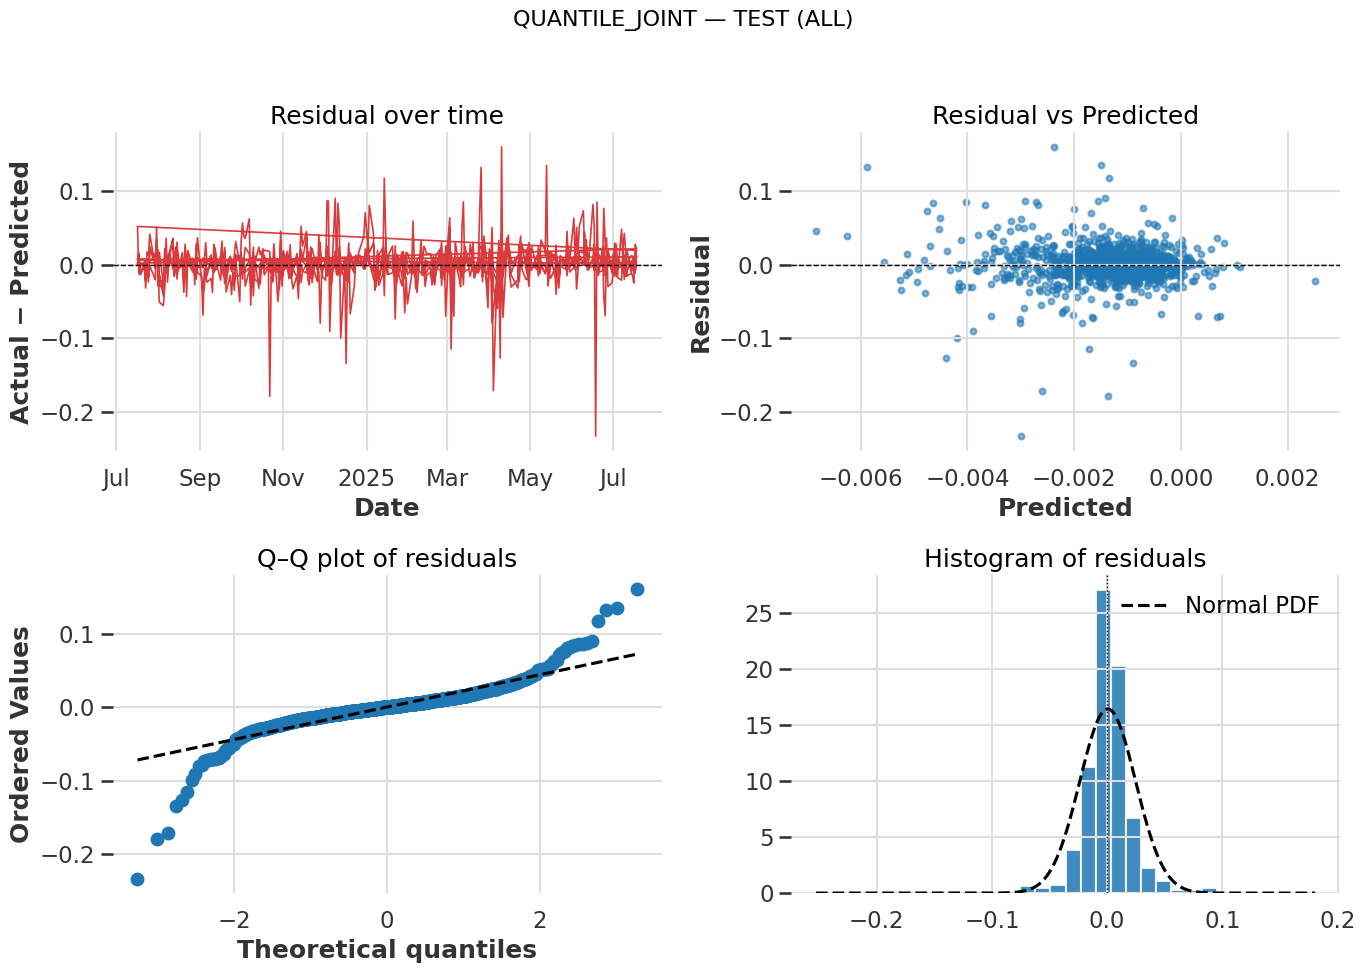

📊 Residual stats for QUANTILE_JOINT — TEST (ALL):
  Mean       : 0.000454
  Std dev    : 0.024254
  Skewness   : -0.948
  Kurtosis   : 16.512


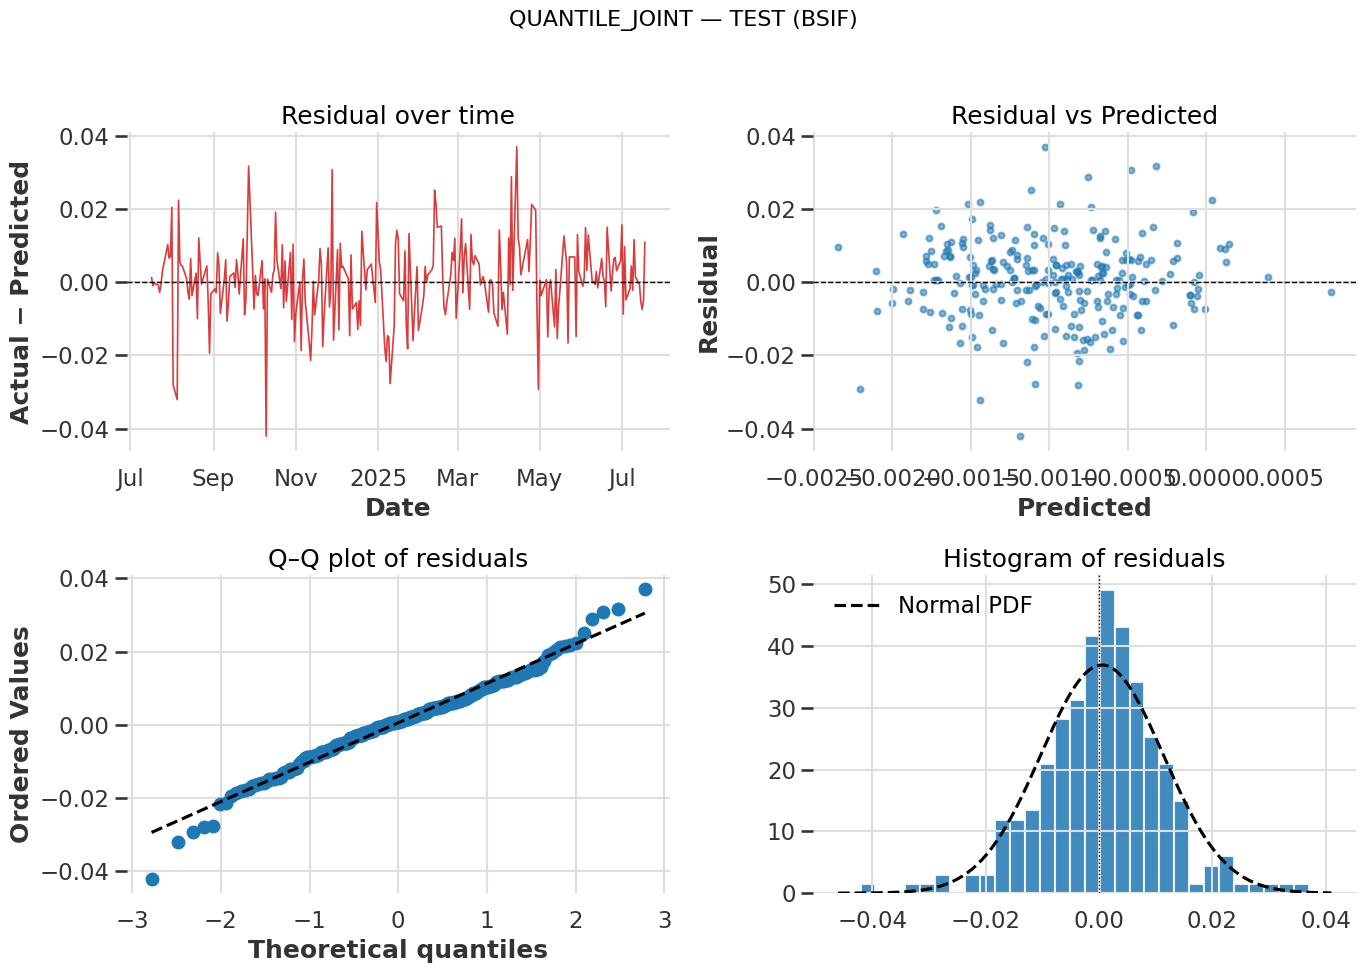

📊 Residual stats for QUANTILE_JOINT — TEST (BSIF):
  Mean       : 0.000548
  Std dev    : 0.010802
  Skewness   : -0.168
  Kurtosis   : 1.475


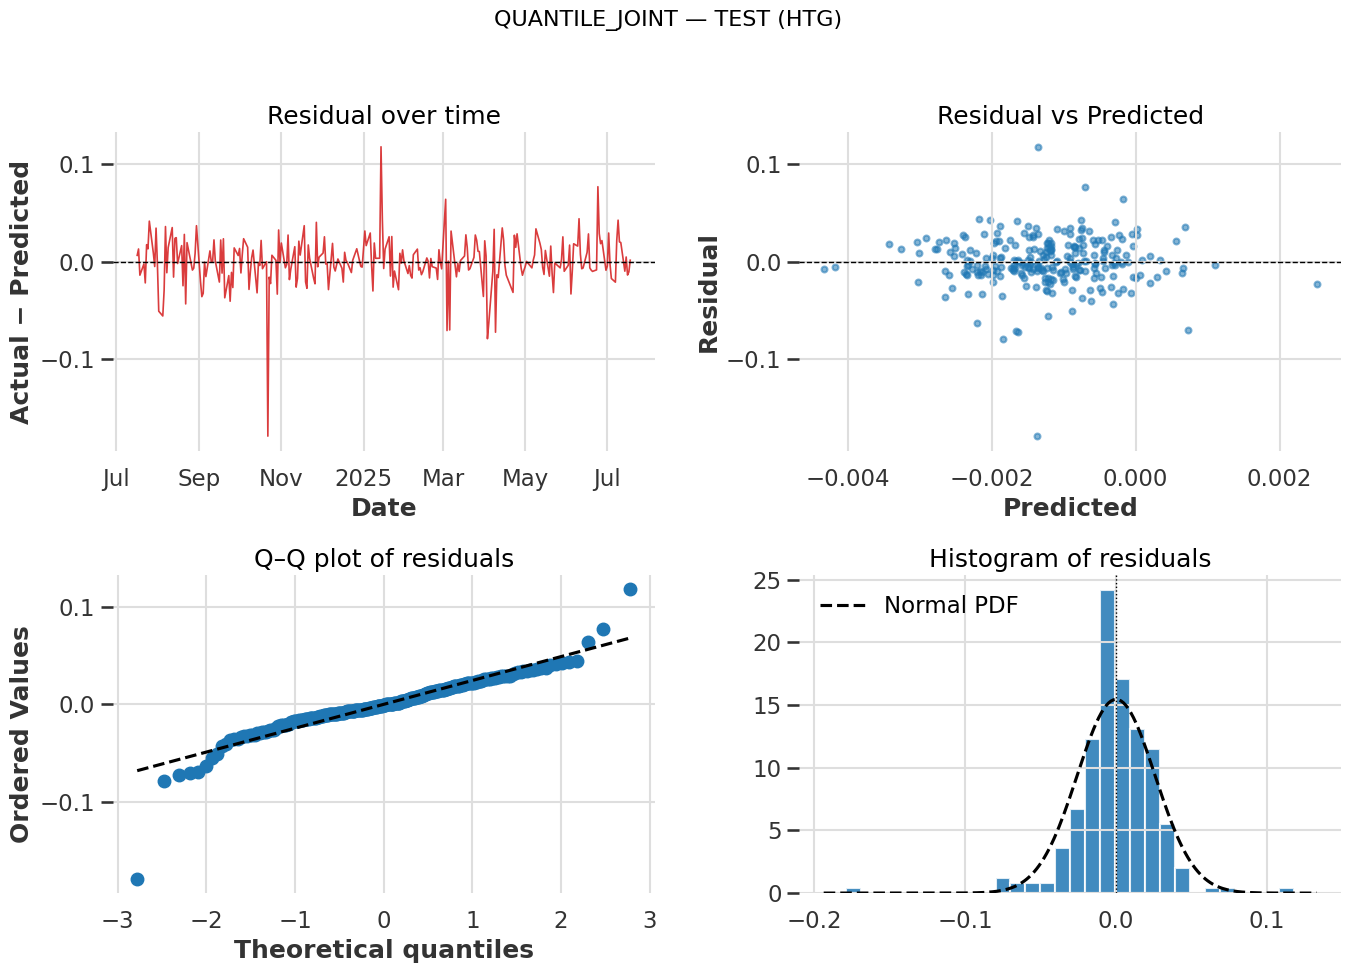

📊 Residual stats for QUANTILE_JOINT — TEST (HTG):
  Mean       : 0.000025
  Std dev    : 0.025821
  Skewness   : -1.119
  Kurtosis   : 10.129


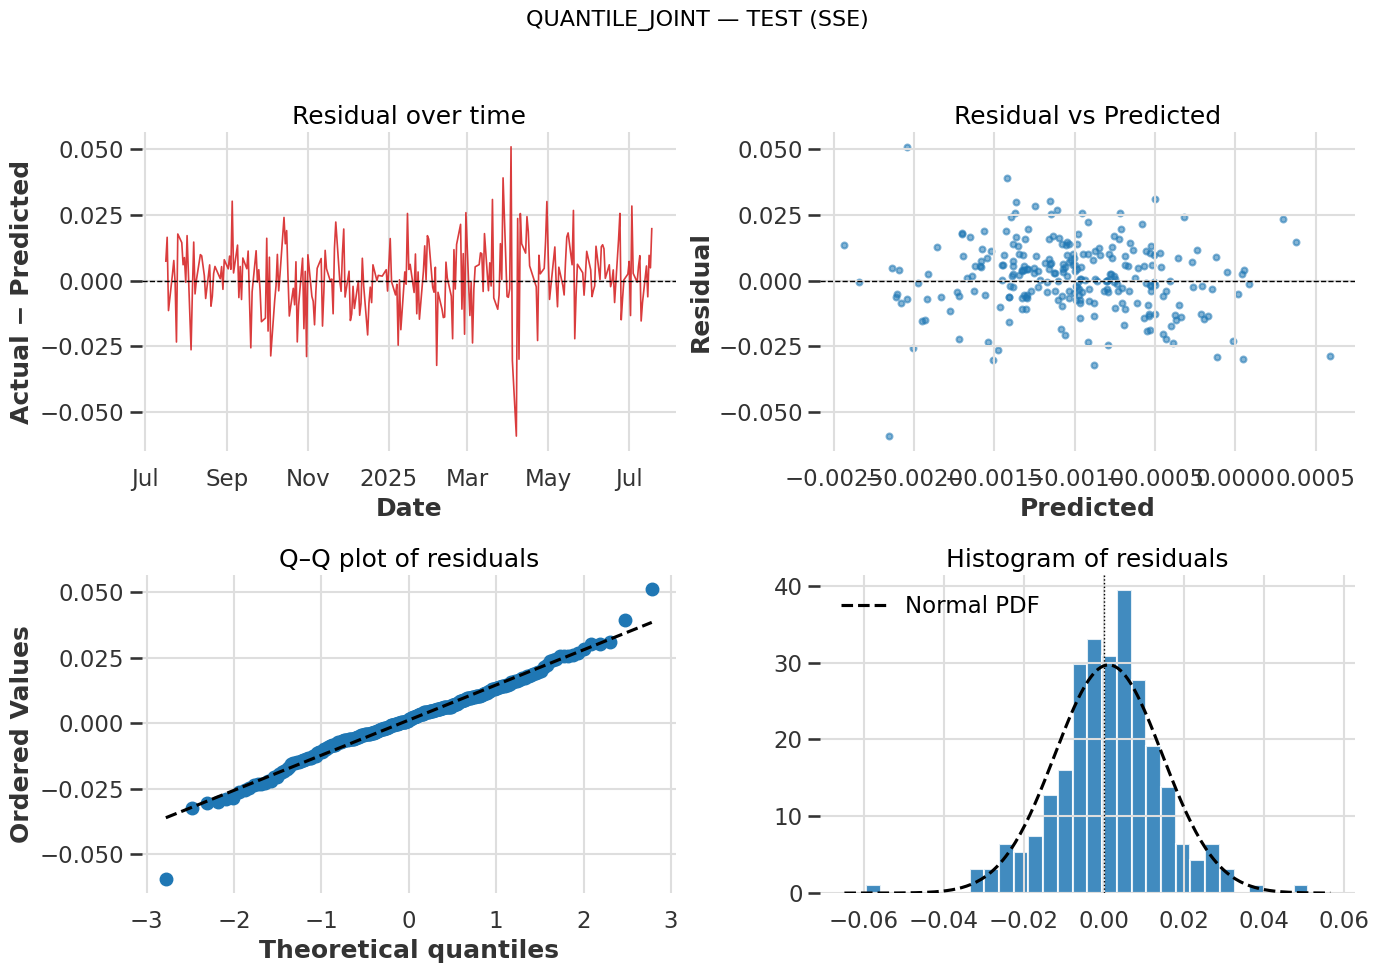

📊 Residual stats for QUANTILE_JOINT — TEST (SSE):
  Mean       : 0.001138
  Std dev    : 0.013436
  Skewness   : -0.217
  Kurtosis   : 1.791


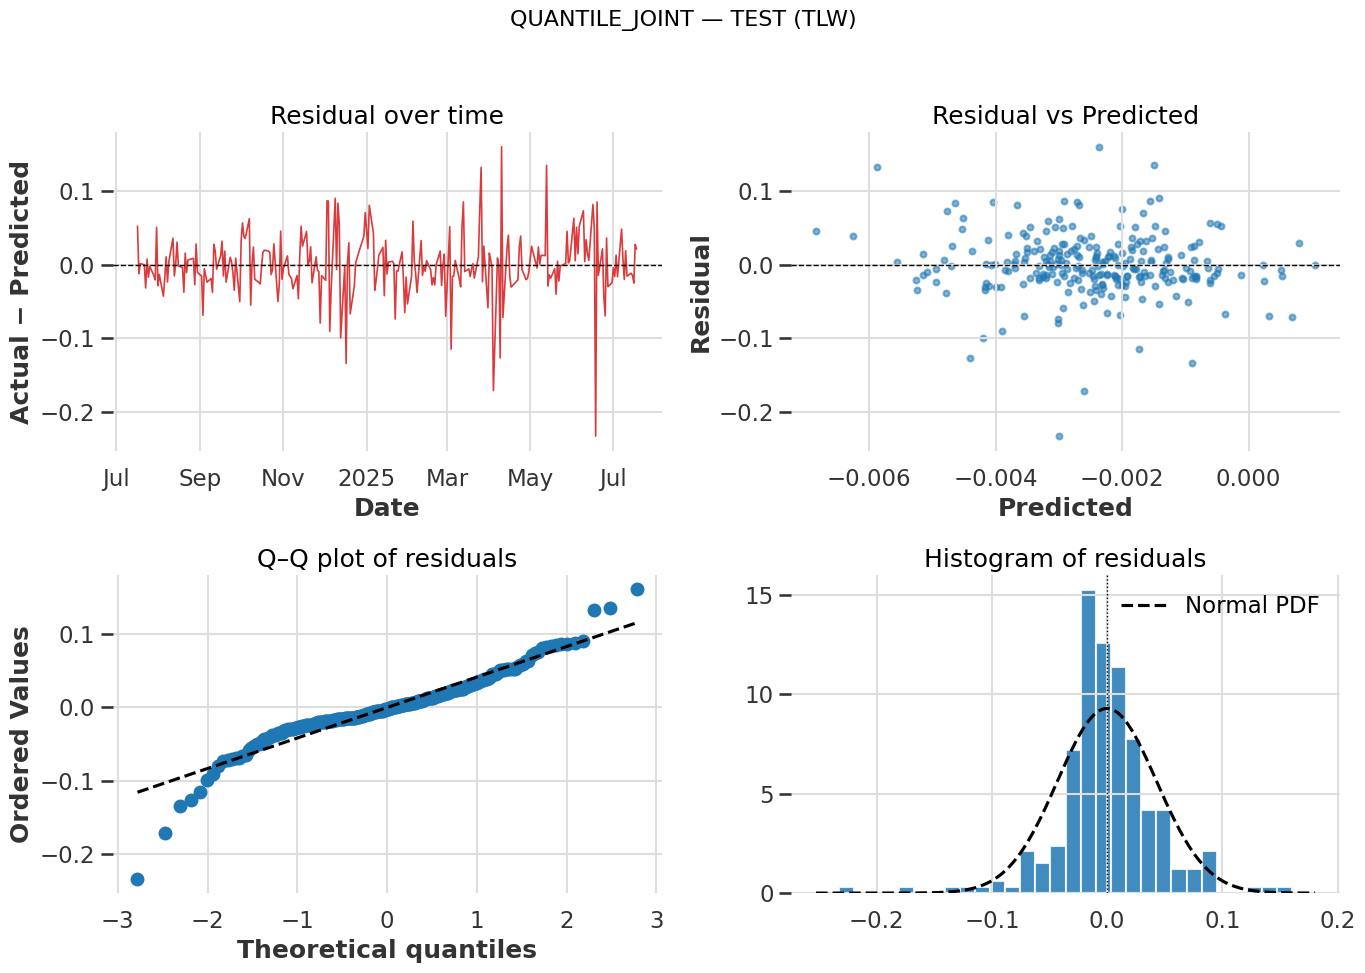

📊 Residual stats for QUANTILE_JOINT — TEST (TLW):
  Mean       : -0.000172
  Std dev    : 0.043003
  Skewness   : -0.551
  Kurtosis   : 5.043


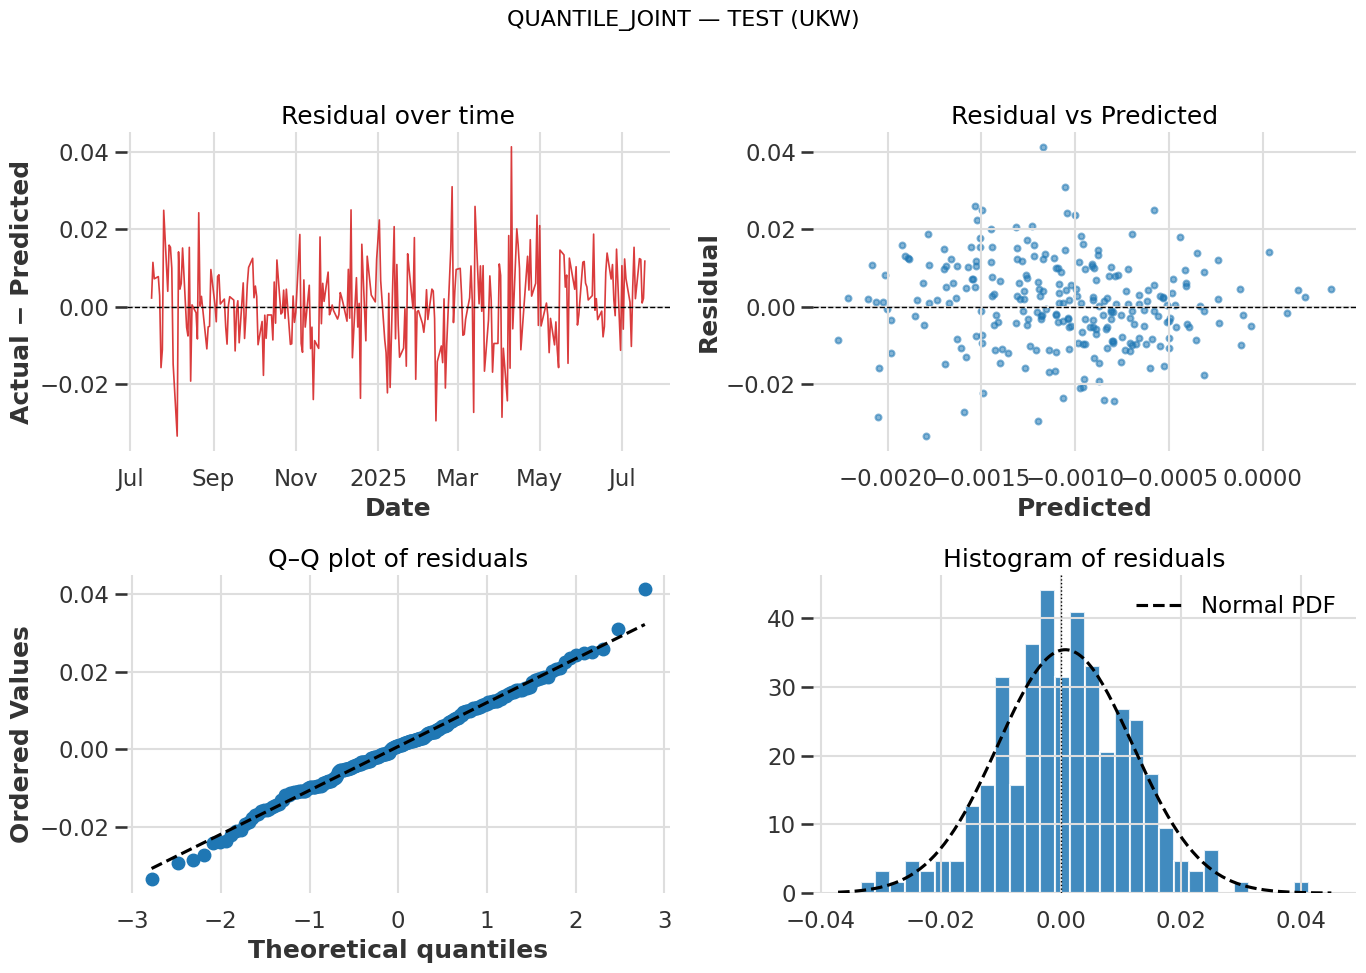

📊 Residual stats for QUANTILE_JOINT — TEST (UKW):
  Mean       : 0.000732
  Std dev    : 0.011270
  Skewness   : 0.005
  Kurtosis   : 0.531


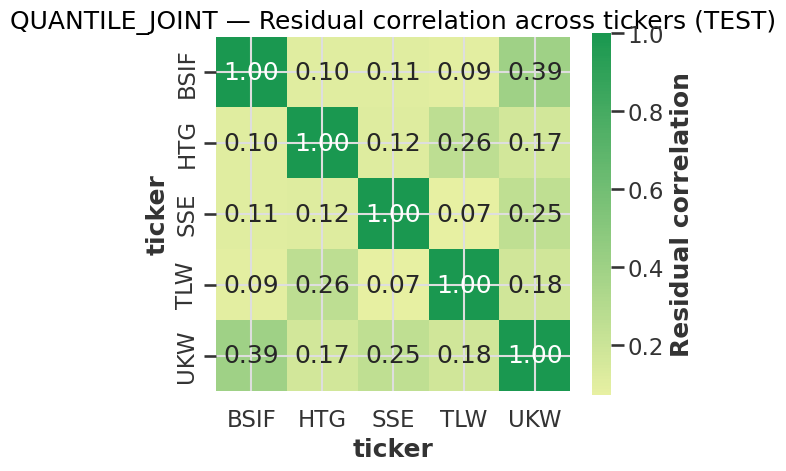

In [14]:
# =========================================
# DIAGNOSTICS for the joint Quantile Regression
# - Set SET in {"val", "test"}; BASELINE remains quantile_joint
# - Reads: outputs/quantile_joint/final_<SET>_predictions.parquet
# - Saves PNGs under outputs/quantile_joint/diagnostics_<SET>/
# - Styling: residual over time (RED), scatter BLUE, Q–Q + hist; BYG heatmaps
# =========================================


sns.set_context("talk")
BYG = sns.blend_palette(["#2166ac", "#f7f7a9", "#1a9850"], as_cmap=True)

BASELINE = "quantile_joint"
SET      = "test"    # "val" or "test"

BASE_DIR = os.path.join("outputs", BASELINE)
PRED_PARQ = os.path.join(BASE_DIR, f"final_{SET}_predictions.parquet")
FIG_DIR   = os.path.join(BASE_DIR, f"diagnostics_{SET}")
os.makedirs(FIG_DIR, exist_ok=True)

TICKER_MAP = {0:"BSIF", 1:"HTG", 2:"SSE", 3:"TLW", 4:"UKW"}

# Heatmap options
RESAMPLE = None          # None / "W" / "M"
ZSCORE_FOR_HEATMAP = True

# ---------- load preds ----------
df = pd.read_parquet(PRED_PARQ).copy()
df["Date"] = pd.to_datetime(df["Date"])
df["ticker"] = df["ticker_id"].map(TICKER_MAP).astype("category")
df = df.sort_values(["ticker_id","Date"])

def plot_diagnostics_with_stats(actual, predicted, dates, title, save_path):
    errors = np.asarray(actual) - np.asarray(predicted)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=16)

    # 1) Residual over time (RED) with concise date ticks
    ax = axes[0,0]
    ax.plot(pd.to_datetime(dates), errors, color="#d62728", alpha=0.9, linewidth=1.2)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title("Residual over time"); ax.set_ylabel("Actual − Predicted"); ax.set_xlabel("Date")
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=10))
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    for tick in ax.get_xticklabels(): tick.set_rotation(0)

    # 2) Residual vs Predicted (BLUE)
    axes[0,1].scatter(predicted, errors, alpha=0.55, s=18, color="#1f77b4")
    axes[0,1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0,1].set_title("Residual vs Predicted"); axes[0,1].set_xlabel("Predicted"); axes[0,1].set_ylabel("Residual")

    # 3) Q–Q plot (BLUE points, black ref)
    stats.probplot(errors, dist="norm", plot=axes[1,0])
    for ln in axes[1,0].get_lines()[:-1]: ln.set_color("#1f77b4")
    axes[1,0].get_lines()[-1].set_color("black"); axes[1,0].get_lines()[-1].set_linestyle("--")
    axes[1,0].set_title("Q–Q plot of residuals")

    # 4) Histogram + normal PDF overlay
    axes[1,1].hist(errors, bins=30, density=True, alpha=0.85, color="#1f77b4", edgecolor="white")
    xmin, xmax = axes[1,1].get_xlim()
    xs = np.linspace(xmin, xmax, 200)
    pdf = stats.norm.pdf(xs, np.nanmean(errors), np.nanstd(errors))
    axes[1,1].plot(xs, pdf, color="black", linestyle="--", label="Normal PDF")
    axes[1,1].axvline(0, color="black", linestyle=":", linewidth=1)
    axes[1,1].set_title("Histogram of residuals"); axes[1,1].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(save_path, dpi=160)
    plt.show()

    # Inline residual stats
    print(f"📊 Residual stats for {title}:")
    print(f"  Mean       : {np.nanmean(errors):.6f}")
    print(f"  Std dev    : {np.nanstd(errors):.6f}")
    print(f"  Skewness   : {stats.skew(errors, nan_policy='omit'):.3f}")
    print(f"  Kurtosis   : {stats.kurtosis(errors, fisher=True, nan_policy='omit'):.3f}")

# ---------- overall ----------
plot_diagnostics_with_stats(
    df["y_true"].values, df["y_pred"].values, df["Date"].values,
    title=f"{BASELINE.upper()} — {SET.upper()} (ALL)",
    save_path=os.path.join(FIG_DIR, f"{BASELINE}_{SET}_overall.png")
)

# ---------- per-ticker ----------
for tid, g in df.groupby("ticker_id", sort=False):
    tic = TICKER_MAP.get(tid, str(tid))
    plot_diagnostics_with_stats(
        g["y_true"].values, g["y_pred"].values, g["Date"].values,
        title=f"{BASELINE.upper()} — {SET.upper()} ({tic})",
        save_path=os.path.join(FIG_DIR, f"{BASELINE}_{SET}_{tic}.png")
    )

# ---------- residual correlation heatmap (BYG) ----------
# Make sure df has the columns we need and compute residuals robustly
df_hm = df.copy()

# Normalise date
df_hm["Date"] = pd.to_datetime(df_hm["Date"], errors="coerce")
df_hm = df_hm.dropna(subset=["Date"])

# Ensure we have a 'ticker' string column
if "ticker" not in df_hm.columns:
    if "Ticker" in df_hm.columns:
        df_hm["ticker"] = df_hm["Ticker"].astype(str)
    elif "ticker_id" in df_hm.columns:
        # Map integer ids to names if available; otherwise keep the id as string
        try:
            df_hm["ticker"] = df_hm["ticker_id"].map(TICKER_MAP).astype(str)
        except Exception:
            df_hm["ticker"] = df_hm["ticker_id"].astype(str)
    else:
        raise KeyError("Could not find a ticker column ('ticker', 'Ticker', or 'ticker_id').")

# Ensure we have residuals: y_true - y_pred (or Actual - Predicted)
if "resid" not in df_hm.columns:
    if {"y_true", "y_pred"}.issubset(df_hm.columns):
        df_hm["resid"] = df_hm["y_true"].astype(float) - df_hm["y_pred"].astype(float)
    elif {"Actual", "Predicted"}.issubset(df_hm.columns):
        df_hm["resid"] = df_hm["Actual"].astype(float) - df_hm["Predicted"].astype(float)
    else:
        raise KeyError(
            "Could not compute residuals: need either ('y_true','y_pred') or ('Actual','Predicted') in the DataFrame."
        )

# Build the (Date × ticker) residual matrix
pivot = (
    df_hm.pivot_table(index="Date", columns="ticker", values="resid", aggfunc="mean")
        .sort_index()
)

# If there’s fewer than 2 tickers, skip the heatmap gracefully
if pivot.shape[1] < 2:
    print("Not enough tickers for a correlation heatmap (need at least 2). Skipping.")
else:
    corr = pivot.corr(min_periods=10)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        corr, annot=True, fmt=".2f", cmap=BYG, center=0, square=True,
        cbar_kws={"label": "Residual correlation"}
    )
    plt.title(f"{BASELINE.upper()} — Residual correlation across tickers ({SET.upper()})")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{BASELINE}_{SET}_resid_corr.png"), dpi=160)
    plt.show()




## 6. Central accuracy and tail-recognition comparison

RMSE and R² describe central forecast accuracy. BMR, BMR_tol and BMR_Z provide the retained descriptive comparison of downside and extreme-tail recognition.


In [15]:
# =========================
# Comparative table for the five retained model paths
# =========================


def _pick_first(cols, candidates):
    """
    Return the first candidate that exists in `cols` (a collection of column names).
    If none exist, return None.
    """
    for c in candidates:
        if c in cols:
            return c
    return None

def _load_all_row(path, model_label):
    """
    Load the 'All/ALL' row; if absent, macro-average across tickers.
    Returns dict with RMSE, R², BMR, BMR_tol, BMR_z, N_rows_used.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(path)

    df = pd.read_csv(path)

    # Try to locate the ALL row under either 'ticker_id' or 'Ticker'
    all_row = pd.DataFrame()
    if 'ticker_id' in df.columns:
        all_row = df[df['ticker_id'].astype(str).str.upper() == 'ALL']
    if all_row.empty and 'Ticker' in df.columns:
        all_row = df[df['Ticker'].astype(str).str.upper() == 'ALL']

    # Column names (some files may not have z-BMR)
    col_rmse = 'RMSE'
    col_r2   = 'R²'
    col_bmr  = 'BearMissRate'
    col_bmrt = 'BearMissRate_tol'
    col_bmrz = _pick_first(df.columns, ['BearMissRate_z', 'z-bmr'])

    if not all_row.empty:
        r = all_row.iloc[0]
        out = {
            "Model": model_label,
            "RMSE": float(r[col_rmse]) if col_rmse in r else np.nan,
            "R²": float(r[col_r2]) if col_r2 in r else np.nan,
            "BearMissRate": float(r[col_bmr]) if col_bmr in r else np.nan,
            "BearMissRate_tol": float(r[col_bmrt]) if col_bmrt in r else np.nan,
            "BearMissRate_z": float(r[col_bmrz]) if (col_bmrz is not None and col_bmrz in r and pd.notna(r[col_bmrz])) else np.nan,
            "N_rows_used": int(r['N']) if 'N' in r and pd.notna(r['N']) else np.nan,
        }
        return out

    # ----- No ALL row: macro-average across tickers (equal N per ticker) -----
    g = df.copy()
    # Drop any ALL rows if they exist oddly
    if 'ticker_id' in g.columns:
        g = g[g['ticker_id'].astype(str).str.upper() != 'ALL']
    if 'Ticker' in g.columns:
        g = g[g['Ticker'].astype(str).str.upper() != 'ALL']

    out = {
        "Model": model_label,
        "RMSE": float(g[col_rmse].mean()) if col_rmse in g.columns else np.nan,
        "R²": float(g[col_r2].mean()) if col_r2 in g.columns else np.nan,
        "BearMissRate": float(g[col_bmr].mean()) if col_bmr in g.columns else np.nan,
        "BearMissRate_tol": float(g[col_bmrt].mean()) if col_bmrt in g.columns else np.nan,
        "BearMissRate_z": float(g[col_bmrz].mean()) if (col_bmrz is not None and col_bmrz in g.columns) else np.nan,
        "N_rows_used": int(g['N'].sum()) if 'N' in g.columns else np.nan,
    }
    return out

# ---- Retained model paths ----
paths = [
    ("LSTM",                "outputs/lstm/final_test_metrics.csv"),
    ("LSTM_HuPin",          "outputs/hupin/final_test_metrics.csv"),
    ("PU_LSTM",             "outputs/pu_lstm/final_test_metrics_bmr_compare.csv"),
    ("Quantile (Joint)",    "outputs/quantile_joint/final_test_metrics_bmr_compare.csv"),
    ("Martingale",          "outputs/martingale/martingale_metrics.csv"),
]

rows = []
missing = []
for label, path in paths:
    try:
        rows.append(_load_all_row(path, label))
    except Exception as e:
        missing.append((label, str(e)))

comp = pd.DataFrame(rows)

if comp.empty:
    print("⚠️ Could not build comparison table — no rows loaded.")
    if missing:
        print("Missing/failed files:")
        for lab, err in missing:
            print(f"  - {lab}: {err}")
else:
    # Sort by RMSE (ascending); if some rows have NaN RMSE they'll sink to the bottom
    comp = comp.sort_values(by=["RMSE"], ascending=True, na_position="last").reset_index(drop=True)
    comp.insert(0, "Rank", np.arange(1, len(comp) + 1))

    # Friendly notes column
    notes = []
    for i, r in comp.iterrows():
        if i == 0:
            notes.append(f"{int(r['Rank'])}. {r['Model']} — best RMSE")
        else:
            notes.append(f"{int(r['Rank'])}. {r['Model']}")
    comp["Notes"] = notes

    comparison_dir = os.path.join("outputs", "comparisons")
    os.makedirs(comparison_dir, exist_ok=True)
    comp_out = os.path.join(comparison_dir, "five_model_comparison.csv")
    comp.to_csv(comp_out, index=False)
    print(f"✅ Wrote comparison table -> {comp_out}")

    if missing:
        print("⚠️ Missing metrics files:", missing)

    print(comp.to_string(index=False))


✅ Wrote comparison table -> outputs\comparisons\five_model_comparison.csv
 Rank            Model     RMSE        R²  BearMissRate  BearMissRate_tol  BearMissRate_z  N_rows_used                           Notes
    1 Quantile (Joint) 0.024259 -0.002448      0.950311          0.195652        1.000000       1275.0 1. Quantile (Joint) — best RMSE
    2             LSTM 0.024880  0.005723      0.823427          0.162587        1.000000       1125.0                         2. LSTM
    3          PU_LSTM 0.024919 -0.019980      0.977383          0.261712        1.000000       1215.0                      3. PU_LSTM
    4       Martingale 0.025559 -0.000030      1.000000          0.190480        1.000000          NaN                   4. Martingale
    5       LSTM_HuPin 0.027179 -0.186505      0.554196          0.092657        0.966667       1125.0                   5. LSTM_HuPin


## 7. Pairwise Diebold-Mariano comparison

The retained implementation below tests squared-error loss differentials and is therefore the formal comparison of central forecast accuracy. A formal tail-loss comparison should remain a distinct extension; the BMR-family columns above are not silently substituted into the RMSE-based test.


In [16]:
# ============================================
# Pairwise Diebold–Mariano tests (RMSE-based)
# - Loads predictions from the five retained model paths
# - Computes DM tests for unique pairs (no permutations)
# - Saves:
#     * DM_RMSE_scores.csv  (pairwise appendix table)
#     * DM_RMSE_range.csv   (leaderboard by DM wins)
# ============================================


from itertools import combinations

# --- Import DM test from installed library, wrap to handle API variants ---
try:
    from dieboldmariano import dm_test
except Exception as e:
    raise ImportError(
        "Could not import `dm_test` from the installed DM library. "
        "Ensure `pip install dieboldmariano` succeeded."
    ) from e

def dm_wrapper(y_true: np.ndarray, yhat1: np.ndarray, yhat2: np.ndarray, h: int = 1):
    """
    Call the installed DM test function while handling common API variants:
      1) dm_test(y_true, yhat1, yhat2, h=..., crit='MSE' or power=2, alternative=...)
      2) dm_test(errors1, errors2, h=..., alternative=...)
      3) dm_test(errors1, errors2, h=...)
    Returns: (statistic, p_value)
    """
    y_true = np.asarray(y_true, float)
    yhat1  = np.asarray(yhat1,  float)
    yhat2  = np.asarray(yhat2,  float)
    e1 = yhat1 - y_true
    e2 = yhat2 - y_true

    # Try a sequence of known calling conventions
    attempts = [
        # Forecast-level APIs
        lambda: dm_test(y_true, yhat1, yhat2, h=h, crit="MSE", alternative="two_sided"),
        lambda: dm_test(y_true, yhat1, yhat2, h=h, alternative="two_sided"),
        lambda: dm_test(y_true, yhat1, yhat2, h=h),
        # Some libraries use hyphen in alternative
        lambda: dm_test(y_true, yhat1, yhat2, h=h, crit="MSE", alternative="two-sided"),
        lambda: dm_test(y_true, yhat1, yhat2, h=h, alternative="two-sided"),
        # Error-level APIs
        lambda: dm_test(e1, e2, h=h, alternative="two_sided"),
        lambda: dm_test(e1, e2, h=h, alternative="two-sided"),
        lambda: dm_test(e1, e2, h=h),
    ]
    for call in attempts:
        try:
            stat, p = call()
            return float(stat), float(p)
        except TypeError:
            continue
        except Exception:
            continue
    raise RuntimeError(
        "dm_test: none of the supported calling conventions worked. "
        "Please check the installed package API."
    )

# ----------------------------
# Config & helper utilities
# ----------------------------
ALPHA = 0.05  # significance for awarding wins
COMPARISON_DIR = os.path.join("outputs", "comparisons")
os.makedirs(COMPARISON_DIR, exist_ok=True)
PAIRWISE_OUT = os.path.join(COMPARISON_DIR, "DM_RMSE_scores_five_models.csv")
RANK_OUT     = os.path.join(COMPARISON_DIR, "DM_RMSE_range_five_models.csv")

# Mapping for integer ticker ids (Darts outputs) -> string tickers
TICKER_MAP = {0: "BSIF", 1: "HTG", 2: "SSE", 3: "TLW", 4: "UKW"}

# Source files per model
MODEL_PATHS = {
    "LSTM":           "outputs/lstm/final_test_predictions.parquet",
    "PU_LSTM":        "outputs/pu_lstm/final_test_predictions.parquet",
    "LSTM_HuPin":     "outputs/hupin/final_test_predictions.parquet",
    "Quantile":       "outputs/quantile_joint/final_test_predictions.parquet",
    "Martingale":     "outputs/martingale/Martingale_predictions.parquet",
}

def _standardize_preds(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """
    Convert various output schemas to a standard one:
    Columns: Ticker (str), Date (datetime64[ns]), y_true (float), y_pred (float)
    """
    # Darts-style: ['ticker_id','Date','y_true','y_pred', ...]
    if {"ticker_id","Date","y_true","y_pred"}.issubset(df.columns):
        std = df.copy()
        std["Ticker"] = std["ticker_id"].map(TICKER_MAP).astype(str)
        std = std[["Ticker","Date","y_true","y_pred"]]

    # Already standardized: ['Ticker','Date','y_true','y_pred']
    elif {"Ticker","Date","y_true","y_pred"}.issubset(df.columns):
        std = df[["Ticker","Date","y_true","y_pred"]].copy()

    # Martingale-like: ['Date','Ticker','Actual','Predicted', ...]
    elif {"Date","Ticker","Actual","Predicted"}.issubset(df.columns):
        std = df.rename(columns={"Actual":"y_true","Predicted":"y_pred"})[
            ["Ticker","Date","y_true","y_pred"]
        ]

    else:
        # Last-resort lower-case mapping
        cols = {c.lower(): c for c in df.columns}
        needed = {"date","ticker","y_true","y_pred"}
        if needed.issubset(cols):
            std = df.rename(columns={
                cols["ticker"]:"Ticker", cols["date"]:"Date",
                cols["y_true"]:"y_true", cols["y_pred"]:"y_pred"
            })[["Ticker","Date","y_true","y_pred"]]
        else:
            raise ValueError(
                f"[{name}] Unrecognized columns. Expect one of:\n"
                " - Darts-style: ('ticker_id','Date','y_true','y_pred')\n"
                " - Martingale-style: ('Ticker','Date','Actual','Predicted')\n"
                " - Already-standardized: ('Ticker','Date','y_true','y_pred')"
            )

    # Coerce types & deduplicate
    std = std.dropna(subset=["Ticker","Date","y_true","y_pred"]).copy()
    std["Ticker"] = std["Ticker"].astype(str)
    std["Date"]   = pd.to_datetime(std["Date"], errors="coerce")
    std = std.dropna(subset=["Date"]).drop_duplicates(subset=["Ticker","Date"], keep="last")

    # Ensure numeric
    std["y_true"] = pd.to_numeric(std["y_true"], errors="coerce")
    std["y_pred"] = pd.to_numeric(std["y_pred"], errors="coerce")
    std = std.dropna(subset=["y_true","y_pred"])
    return std

def load_model_preds(name: str, path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"[{name}] Missing predictions file at: {path}")
    df = pd.read_parquet(path)


    return _standardize_preds(df, name)

def newey_west_var(d: np.ndarray, lag: int = 1) -> float:
    """
    HAC variance estimate (Newey–West) for the mean of d.
    Returns variance of the sample mean.
    """
    d = np.asarray(d, dtype=float)
    n = int(len(d))
    if n < 2:
        return np.nan
    d = d - np.nanmean(d)
    gamma0 = np.nanmean(d * d)
    var = gamma0
    for k in range(1, min(lag, n-1) + 1):
        w = 1.0 - k / (lag + 1.0)
        cov = np.nanmean(d[k:] * d[:-k])
        var += 2 * w * cov
    return var / n

# ----------------------------
# Load all model predictions
# ----------------------------
preds = {}
for name, path in MODEL_PATHS.items():
    preds[name] = load_model_preds(name, path)

# ----------------------------
# Pairwise DM across unique pairs
# ----------------------------
rows = []
model_names = list(preds.keys())
for A, B in combinations(model_names, 2):
    dfA = preds[A]
    dfB = preds[B]

    # align on intersection of (Ticker, Date)
    j = pd.merge(dfA, dfB, on=["Ticker","Date"], suffixes=("_A","_B"), how="inner")
    # drop any remaining NaNs
    j = j.dropna(subset=["y_true_A","y_pred_A","y_true_B","y_pred_B"])
    N = len(j)
    if N == 0:
        rows.append({
            "ModelA": A, "ModelB": B, "N_overlap": 0,
            "mean_loss_diff": np.nan, "DM_stat": np.nan, "p_value": np.nan,
            "CI_lower": np.nan, "CI_upper": np.nan, "winner": "No overlap",
            "win_A": 0, "win_B": 0
        })
        continue

    # Use y_true from A (should equal B after inner join). Safety check optional.
    y  = j["y_true_A"].to_numpy()
    yhatA = j["y_pred_A"].to_numpy()
    yhatB = j["y_pred_B"].to_numpy()

    # Squared-error losses for reporting the sign of mean difference
    eA = yhatA - y
    eB = yhatB - y
    lA = eA**2
    lB = eB**2

    # DM test via wrapper
    try:
        dm_stat, p_val = dm_wrapper(y, yhatA, yhatB, h=1)
    except Exception as e:
        raise RuntimeError(f"DM test failed for pair ({A} vs {B}): {e}")

    # Mean loss diff and a simple HAC 95% CI
    d = lA - lB
    mean_d = float(np.nanmean(d))
    var_mean = newey_west_var(d, lag=1)
    if np.isfinite(var_mean):
        se = float(np.sqrt(var_mean))
        ci_lo = mean_d - 1.96 * se
        ci_hi = mean_d + 1.96 * se
    else:
        ci_lo = np.nan
        ci_hi = np.nan

    # Winner rule: significant & lower mean loss wins
    if np.isfinite(p_val) and (p_val < ALPHA):
        if mean_d < 0:   # A has lower MSE
            winner, win_A, win_B = A, 1, 0
        elif mean_d > 0:
            winner, win_A, win_B = B, 0, 1
        else:
            winner, win_A, win_B = "Tie", 0, 0
    else:
        winner, win_A, win_B = "Tie", 0, 0

    rows.append({
        "ModelA": A, "ModelB": B, "N_overlap": int(N),
        "mean_loss_diff": mean_d,       # <0 => A better (lower MSE); >0 => B better
        "DM_stat": float(dm_stat),
        "p_value": float(p_val),
        "CI_lower": ci_lo,
        "CI_upper": ci_hi,
        "winner": winner,
        "win_A": win_A, "win_B": win_B
    })

pairwise_df = pd.DataFrame(rows)
pairwise_df.to_csv(PAIRWISE_OUT, index=False)
print(f"Saved pairwise DM results -> {PAIRWISE_OUT}")

# ----------------------------
# Leaderboard by DM wins
# ----------------------------
points = pd.DataFrame({"Model": model_names, "DM_points": 0, "wins": 0, "losses": 0, "ties": 0})
points = points.set_index("Model")

for _, r in pairwise_df.iterrows():
    A, B = r["ModelA"], r["ModelB"]
    if r["winner"] == A:
        points.at[A, "DM_points"] += 1
        points.at[A, "wins"] += 1
        points.at[B, "losses"] += 1
    elif r["winner"] == B:
        points.at[B, "DM_points"] += 1
        points.at[B, "wins"] += 1
        points.at[A, "losses"] += 1
    else:
        # tie or no overlap
        points.at[A, "ties"] += 1
        points.at[B, "ties"] += 1

leaderboard = points.reset_index().sort_values(["DM_points","wins"], ascending=[False, False])
leaderboard["rank"] = np.arange(1, len(leaderboard) + 1)
leaderboard = leaderboard[["rank","Model","DM_points","wins","losses","ties"]]

leaderboard.to_csv(RANK_OUT, index=False)
print(f"Saved leaderboard -> {RANK_OUT}")

# Optional: quick print
print("\nDM ranking (higher is better):")
print(leaderboard.to_string(index=False))


Saved pairwise DM results -> outputs\comparisons\DM_RMSE_scores_five_models.csv
Saved leaderboard -> outputs\comparisons\DM_RMSE_range_five_models.csv

DM ranking (higher is better):
 rank      Model  DM_points  wins  losses  ties
    1 Martingale          2     2       0     2
    2       LSTM          1     1       0     3
    3    PU_LSTM          1     1       1     2
    4   Quantile          1     1       0     3
    5 LSTM_HuPin          0     0       4     0
